# Phase 1: Data Collection and Exploratory Data Analysis

**Project:** Hybrid Unsupervised Ensemble Architecture For Hyper-Local Soil Nutrition Depletion Forecasting

**Objective:** To analyze how soil properties, weather conditions, and farm factors influence Nitrogen levels.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("Crop and fertilizer dataset.csv")

In [3]:
print("Shape:", df.shape)
df.head()

Shape: (10000, 8)


,District_Name,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Farm_Size_Acres
0,Kolhapur,75.0,50.0,100.0,6.5,1861.635725,20,79.838232
1,Kolhapur,80.0,50.0,100.0,6.5,1400.435779,20,33.932796
2,Kolhapur,85.0,50.0,100.0,6.5,574.308028,20,59.673206
3,Kolhapur,90.0,50.0,100.0,6.5,1900.397115,20,50.000261
4,Kolhapur,95.0,50.0,100.0,6.5,1568.615247,20,94.628058


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   District_Name    10000 non-null  str    
 1   Nitrogen         10000 non-null  float64
 2   Phosphorus       10000 non-null  float64
 3   Potassium        10000 non-null  float64
 4   pH               10000 non-null  float64
 5   Rainfall         10000 non-null  float64
 6   Temperature      10000 non-null  int64  
 7   Farm_Size_Acres  10000 non-null  float64
dtypes: float64(6), int64(1), str(1)
memory usage: 697.7 KB


,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Farm_Size_Acres
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,140.630161,50.743263,140.198671,6.657682,1104.115646,26.737300,51.354053
std,76.652442,15.937421,95.988693,0.705442,516.194857,4.509515,28.616317
min,20.000000,1.000000,5.000000,4.339303,200.234020,10.000000,1.004764
25%,75.000000,42.000000,55.000000,6.227856,656.132037,25.000000,26.670593
50%,130.000000,51.000000,107.000000,6.586065,1108.905462,27.000000,51.800485
75%,218.000000,60.000000,238.000000,7.000000,1550.710693,30.000000,76.153864
max,274.000000,90.000000,321.000000,9.031000,1999.775178,40.000000,99.992558


In [5]:
df.drop_duplicates(inplace=True)

##  Exploratory Data Analysis (EDA)

This section analyzes how soil properties, weather conditions, and regional factors influence Nitrogen levels.

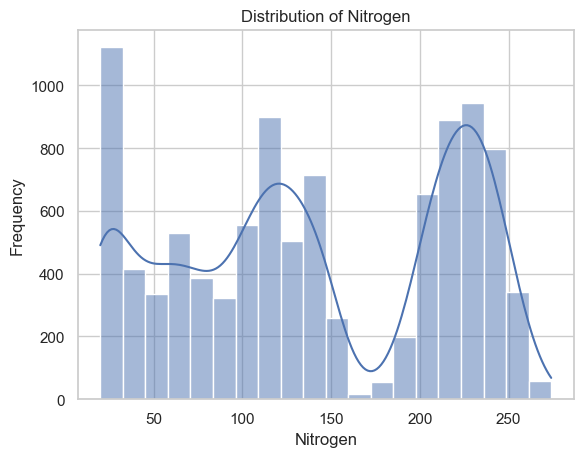

In [6]:
sns.histplot(df['Nitrogen'], kde=True)
plt.title("Distribution of Nitrogen")
plt.xlabel("Nitrogen")
plt.ylabel("Frequency")
plt.show()

**Observation:** Nitrogen values are spread across a range and are not perfectly symmetric.

**Insight:** This indicates variability in soil nutrient levels across different conditions.

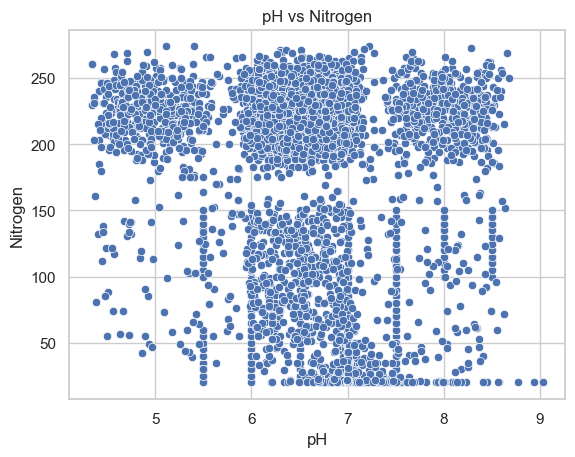

In [7]:
sns.scatterplot(x='pH', y='Nitrogen', data=df)
plt.title("pH vs Nitrogen")
plt.show()

**Observation:** Nitrogen levels vary across different pH values.

**Insight:** Soil pH influences nutrient availability and should be considered in modeling.

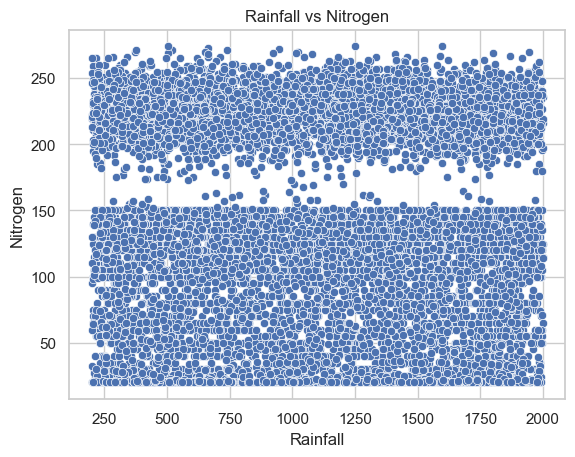

In [8]:
sns.scatterplot(x='Rainfall', y='Nitrogen', data=df)
plt.title("Rainfall vs Nitrogen")
plt.show()

**Observation:** In some cases, higher rainfall corresponds to lower Nitrogen values.

**Insight:** This may be due to leaching effects where nutrients are washed away.

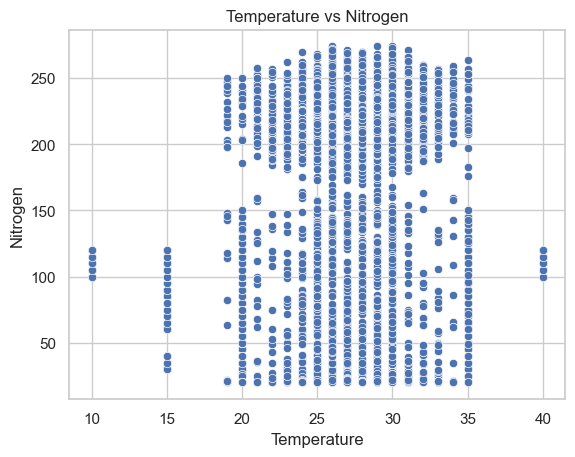

In [9]:
sns.scatterplot(x='Temperature', y='Nitrogen', data=df)
plt.title("Temperature vs Nitrogen")
plt.show()

**Observation:** Temperature shows some variation with Nitrogen levels.

**Insight:** Temperature influences soil reactions and nutrient cycles.

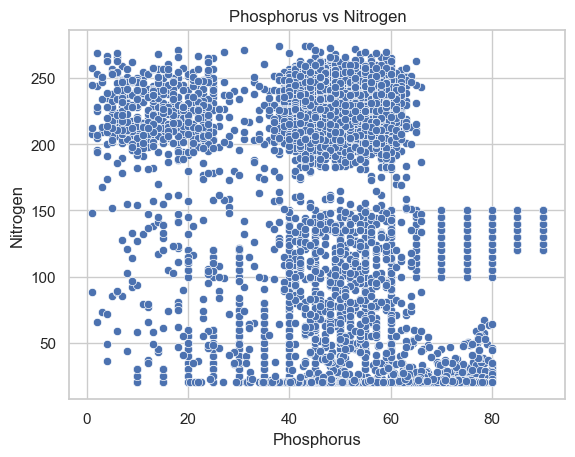

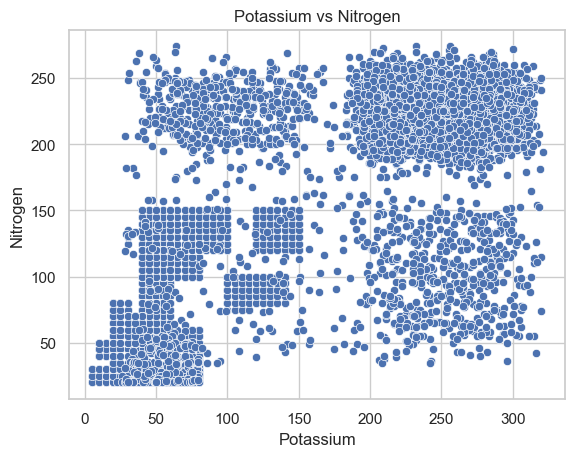

In [10]:
sns.scatterplot(x='Phosphorus', y='Nitrogen', data=df)
plt.title("Phosphorus vs Nitrogen")
plt.show()

sns.scatterplot(x='Potassium', y='Nitrogen', data=df)
plt.title("Potassium vs Nitrogen")
plt.show()

**Observation:** Nitrogen shows relationships with other nutrients.

**Insight:** Soil nutrients are interdependent and should be analyzed together.

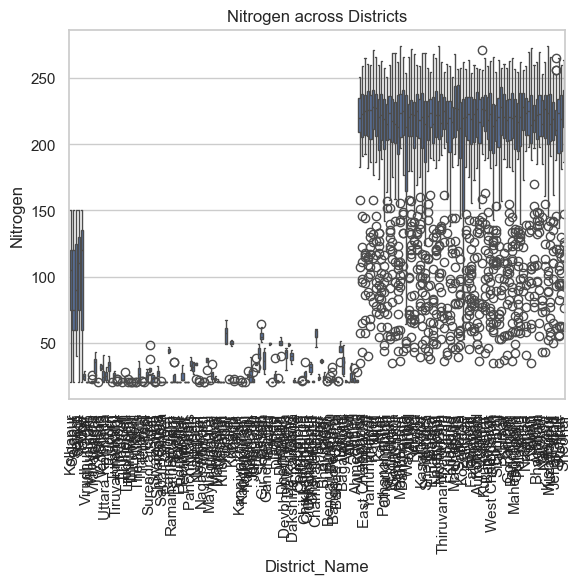

In [11]:
sns.boxplot(x='District_Name', y='Nitrogen', data=df)
plt.xticks(rotation=90)
plt.title("Nitrogen across Districts")
plt.show()

**Observation:** Nitrogen levels differ across districts.

**Insight:** Regional variation exists, indicating location-specific soil behavior.

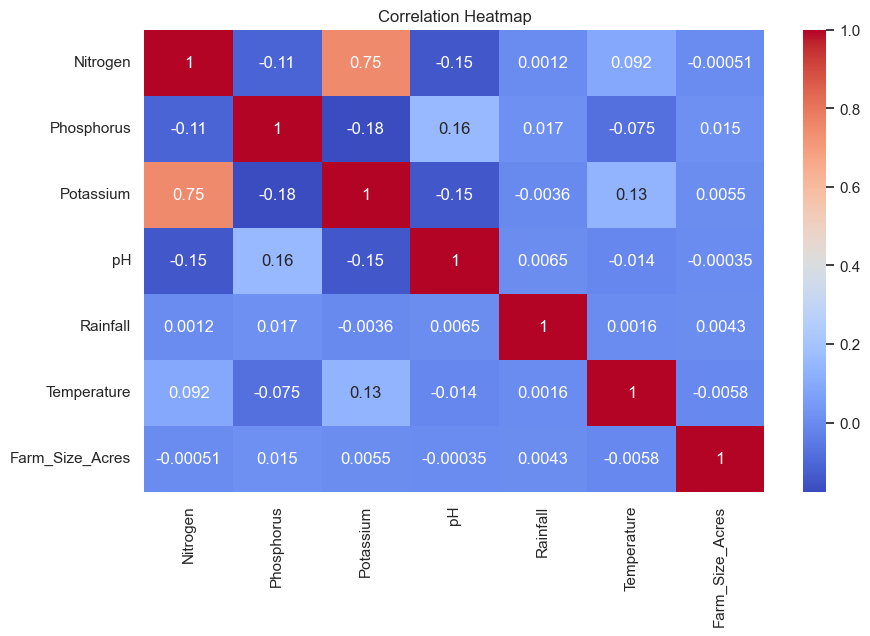

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Observation:** Some variables show moderate correlation with Nitrogen.

**Insight:** Multiple features influence Nitrogen levels rather than a single factor.

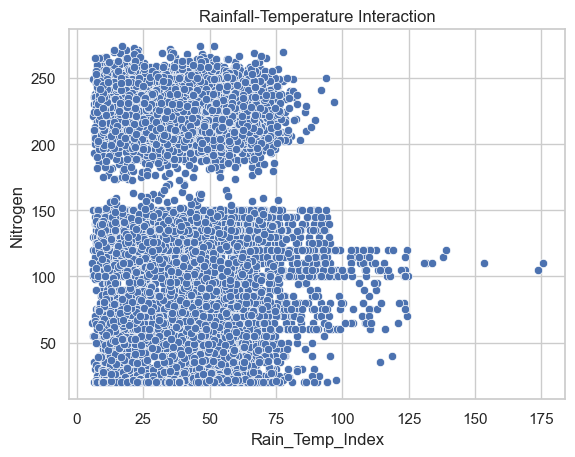

In [13]:
df['Rain_Temp_Index'] = df['Rainfall'] / (df['Temperature'] + 1)

sns.scatterplot(x='Rain_Temp_Index', y='Nitrogen', data=df)
plt.title("Rainfall-Temperature Interaction")
plt.show()

**Observation:** The combined feature shows a clearer pattern than individual variables.

**Insight:** Feature interactions can improve prediction performance in later stages.

In [14]:
print("Skewness of Nitrogen:", df['Nitrogen'].skew())

Skewness of Nitrogen: -0.05157234187569778


**Insight:** The skewness value indicates whether Nitrogen distribution is balanced or biased towards higher/lower values.

In [15]:
corr = df.corr(numeric_only=True)['Nitrogen'].sort_values(ascending=False)
print(corr)

Nitrogen           1.000000
Potassium          0.750291
Temperature        0.092321
Rainfall           0.001218
Farm_Size_Acres   -0.000506
Rain_Temp_Index   -0.048129
Phosphorus        -0.108047
pH                -0.145497
Name: Nitrogen, dtype: float64


**Insight:** Features with higher correlation values have a stronger relationship with Nitrogen and are important for prediction.

In [16]:
district_mean = df.groupby('District_Name')['Nitrogen'].mean().sort_values()
print(district_mean)

District_Name
Tuticorn        20.002250
Tenkasi         20.010800
Krishnagiri     20.013200
Cuddalore       20.020571
Perambalur      20.021000
                  ...    
Hisar          215.666667
Sheohar        215.771930
Katihar        216.750000
Kollam         217.440000
Kaimur         219.078431
Name: Nitrogen, Length: 182, dtype: float64


**Insight:** Average Nitrogen levels vary across districts, confirming regional differences in soil conditions.

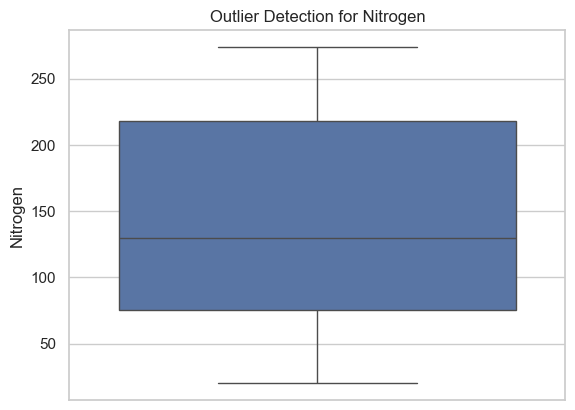

In [17]:
sns.boxplot(y=df['Nitrogen'])
plt.title("Outlier Detection for Nitrogen")
plt.show()

**Insight:** The presence of outliers indicates extreme values which may affect model performance.

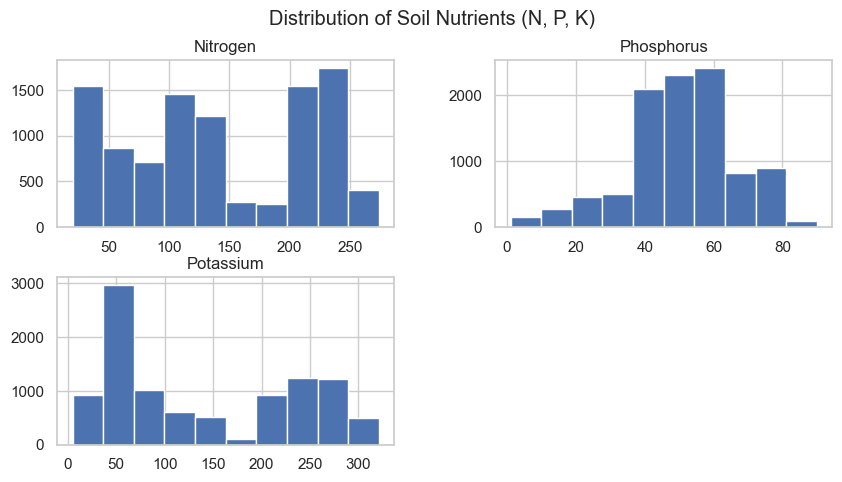

In [18]:
df[['Nitrogen','Phosphorus','Potassium']].hist(figsize=(10,5))
plt.suptitle("Distribution of Soil Nutrients (N, P, K)")
plt.show()

**Observation:** All three nutrients show variation across samples.

**Insight:** Although Nitrogen is the primary focus, other nutrients also vary and may influence soil behavior.

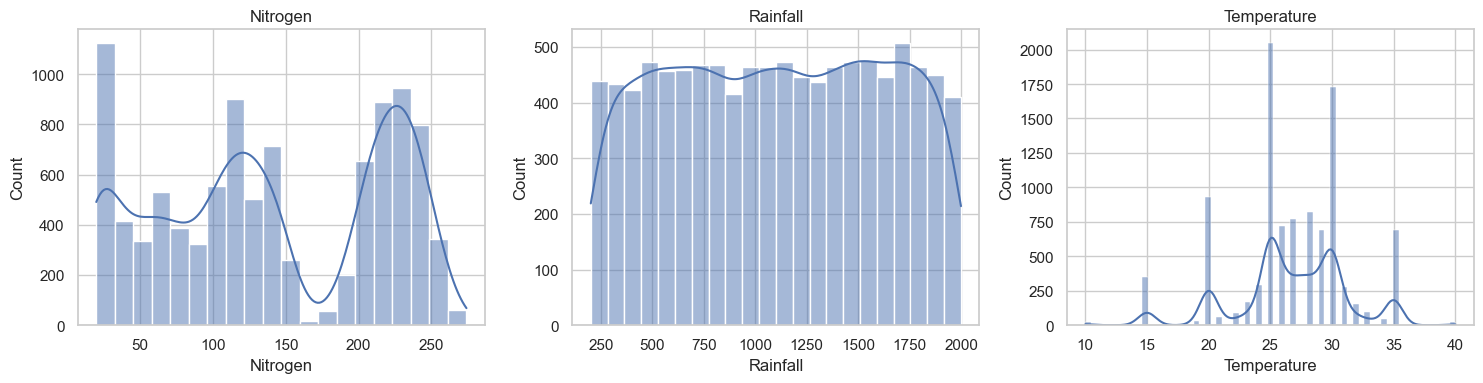

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15,4))

# Nitrogen
sns.histplot(df['Nitrogen'], kde=True, ax=axes[0])
axes[0].set_title("Nitrogen")

# Rainfall
sns.histplot(df['Rainfall'], kde=True, ax=axes[1])
axes[1].set_title("Rainfall")

# Temperature
sns.histplot(df['Temperature'], kde=True, ax=axes[2])
axes[2].set_title("Temperature")

plt.tight_layout()
plt.savefig("figure1_feature_distributions.png", dpi=300)
plt.show()

## Final Summary

The analysis shows that Nitrogen levels are influenced by multiple factors such as soil properties, weather conditions, and regional variations. The relationships are not simple or linear, indicating the presence of complex patterns in the data. This supports the need for more advanced modeling techniques in later phases.The observed variability and interactions between soil, weather, and regional factors indicate that Nitrogen behavior is complex and cannot be captured using simple linear assumptions. This supports the need for advanced, adaptive modeling approaches in the next phase.

## Phase 2 : Data extraction and Feature Engineering

## Feature Engineering

Combine existing features to capture interactions between them.

In [20]:
import pandas as pd
from IPython.display import display

# Load dataset
df = pd.read_csv('Crop and fertilizer dataset.csv')

# Create Nutrient Ratio Features
df['N_P_ratio'] = df['Nitrogen'] / (df['Phosphorus'] + 1e-5)
df['N_K_ratio'] = df['Nitrogen'] / (df['Potassium'] + 1e-5)
df['P_K_ratio'] = df['Phosphorus'] / (df['Potassium'] + 1e-5)

# Round values for better display
df_display = df.round(2)

# Display clean output
print("Dataset with Newly Engineered Features:")
display(df_display.head(10))

Dataset with Newly Engineered Features:


,District_Name,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Farm_Size_Acres,N_P_ratio,N_K_ratio,P_K_ratio
0,Kolhapur,75.0,50.0,100.0,6.5,1861.64,20,79.84,1.50,0.75,0.50
1,Kolhapur,80.0,50.0,100.0,6.5,1400.44,20,33.93,1.60,0.80,0.50
2,Kolhapur,85.0,50.0,100.0,6.5,574.31,20,59.67,1.70,0.85,0.50
3,Kolhapur,90.0,50.0,100.0,6.5,1900.40,20,50.00,1.80,0.90,0.50
4,Kolhapur,95.0,50.0,100.0,6.5,1568.62,20,94.63,1.90,0.95,0.50
5,Kolhapur,100.0,50.0,100.0,6.5,1489.78,20,75.01,2.00,1.00,0.50
6,Kolhapur,75.0,55.0,105.0,7.0,1572.51,25,73.32,1.36,0.71,0.52
7,Kolhapur,80.0,55.0,105.0,7.0,1386.46,25,5.59,1.45,0.76,0.52
8,Kolhapur,85.0,55.0,105.0,7.0,239.80,25,55.42,1.55,0.81,0.52
9,Kolhapur,90.0,55.0,105.0,7.0,656.51,25,47.23,1.64,0.86,0.52


**Observation :** Nutrient interaction features such as N_P_ratio, N_K_ratio, and P_K_ratio were successfully created and displayed clearly.

**Insight :** These ratio features help identify nutrient imbalance more effectively than raw N, P, and K values alone. 

Derive new features by calculating ratios or percentages between existing features.

In [21]:
import pandas as pd
from IPython.display import display

# Load dataset
df = pd.read_csv('Crop and fertilizer dataset.csv')

# -------------------------------
# Ratio Features
# -------------------------------
df['N_P_ratio'] = df['Nitrogen'] / (df['Phosphorus'] + 1e-5)
df['N_K_ratio'] = df['Nitrogen'] / (df['Potassium'] + 1e-5)
df['P_K_ratio'] = df['Phosphorus'] / (df['Potassium'] + 1e-5)

# -------------------------------
# Percentage Contribution Features
# -------------------------------
total_nutrients = df['Nitrogen'] + df['Phosphorus'] + df['Potassium']

df['N_percent'] = (df['Nitrogen'] / (total_nutrients + 1e-5)) * 100
df['P_percent'] = (df['Phosphorus'] / (total_nutrients + 1e-5)) * 100
df['K_percent'] = (df['Potassium'] / (total_nutrients + 1e-5)) * 100

# Round for clean display
df = df.round(2)

# Show important columns
display(df[['District_Name','Nitrogen','Phosphorus','Potassium',
            'N_P_ratio','N_K_ratio','P_K_ratio',
            'N_percent','P_percent','K_percent']].head(10))

,District_Name,Nitrogen,Phosphorus,Potassium,N_P_ratio,N_K_ratio,P_K_ratio,N_percent,P_percent,K_percent
0,Kolhapur,75.0,50.0,100.0,1.50,0.75,0.50,33.33,22.22,44.44
1,Kolhapur,80.0,50.0,100.0,1.60,0.80,0.50,34.78,21.74,43.48
2,Kolhapur,85.0,50.0,100.0,1.70,0.85,0.50,36.17,21.28,42.55
3,Kolhapur,90.0,50.0,100.0,1.80,0.90,0.50,37.50,20.83,41.67
4,Kolhapur,95.0,50.0,100.0,1.90,0.95,0.50,38.78,20.41,40.82
5,Kolhapur,100.0,50.0,100.0,2.00,1.00,0.50,40.00,20.00,40.00
6,Kolhapur,75.0,55.0,105.0,1.36,0.71,0.52,31.91,23.40,44.68
7,Kolhapur,80.0,55.0,105.0,1.45,0.76,0.52,33.33,22.92,43.75
8,Kolhapur,85.0,55.0,105.0,1.55,0.81,0.52,34.69,22.45,42.86
9,Kolhapur,90.0,55.0,105.0,1.64,0.86,0.52,36.00,22.00,42.00


**Observation :** 
Nutrient ratios (N/P, N/K, P/K) show noticeable variation across samples.

Percentage features indicate how much each nutrient contributes to total soil composition.

Some samples have higher Nitrogen dominance, while others show balanced distribution.

**Insight :** 

Ratio features highlight nutrient imbalance, which is more meaningful than raw values.

Percentage features normalize nutrient contribution, making comparisons across regions easier.

## Feature Transformation (Stabilize Data)

In [22]:
import numpy as np
from IPython.display import display

df['Nitrogen_log'] = np.log1p(df['Nitrogen'])
df['Phosphorus_log'] = np.log1p(df['Phosphorus'])
df['Potassium_log'] = np.log1p(df['Potassium'])

# Select columns
display(df[['Nitrogen', 'Nitrogen_log',
            'Phosphorus', 'Phosphorus_log',
            'Potassium', 'Potassium_log']].head(10).round(2))

,Nitrogen,Nitrogen_log,Phosphorus,Phosphorus_log,Potassium,Potassium_log
0,75.0,4.33,50.0,3.93,100.0,4.62
1,80.0,4.39,50.0,3.93,100.0,4.62
2,85.0,4.45,50.0,3.93,100.0,4.62
3,90.0,4.51,50.0,3.93,100.0,4.62
4,95.0,4.56,50.0,3.93,100.0,4.62
5,100.0,4.62,50.0,3.93,100.0,4.62
6,75.0,4.33,55.0,4.03,105.0,4.66
7,80.0,4.39,55.0,4.03,105.0,4.66
8,85.0,4.45,55.0,4.03,105.0,4.66
9,90.0,4.51,55.0,4.03,105.0,4.66


**observation :** 
Log-transformed values are lower and smoother compared to original values

**Insight :** 
Transformation compresses large values and reduces skewness

## Feature Scaling

In [23]:
from sklearn.preprocessing import RobustScaler
import pandas as pd
from IPython.display import display

features = ['Nitrogen','Phosphorus','Potassium','pH','Rainfall','Temperature']

# Apply Robust scaling instead
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[features])

# Convert back to DataFrame
scaled_df = pd.DataFrame(X_scaled, columns=features)

# Display before vs after
print("Before Scaling:")
display(df[features].head(5).round(2))

print("\nAfter Scaling:")
display(scaled_df.head(5).round(2))

Before Scaling:


,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature
0,75.0,50.0,100.0,6.5,1861.64,20
1,80.0,50.0,100.0,6.5,1400.44,20
2,85.0,50.0,100.0,6.5,574.31,20
3,90.0,50.0,100.0,6.5,1900.40,20
4,95.0,50.0,100.0,6.5,1568.62,20



After Scaling:


,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature
0,-0.38,-0.06,-0.04,-0.12,0.84,-1.4
1,-0.35,-0.06,-0.04,-0.12,0.33,-1.4
2,-0.31,-0.06,-0.04,-0.12,-0.60,-1.4
3,-0.28,-0.06,-0.04,-0.12,0.88,-1.4
4,-0.24,-0.06,-0.04,-0.12,0.51,-1.4


**Visualization**

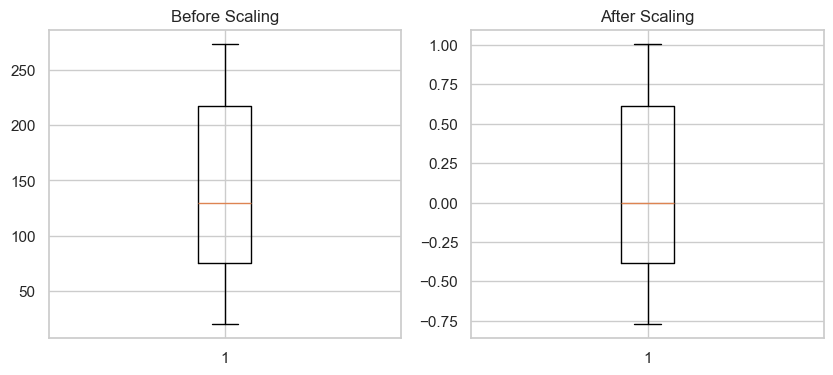

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Before
plt.subplot(1,2,1)
plt.boxplot(df['Nitrogen'])
plt.title('Before Scaling')

# After
plt.subplot(1,2,2)
plt.boxplot(scaled_df['Nitrogen'])
plt.title('After Scaling')

plt.show()

**Observation :**

Before scaling, features had different ranges (e.g., Nitrogen vs pH)

After scaling, all features are centered around 0 with similar spread

**Insight :**

Scaling ensures no feature dominates due to large values

Improves performance of distance-based algorithms like K-Means and PCA

Makes model training more stable and accurate

## Feature Extraction

PCA

PCA Features:


,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6
0,-1.04,-0.08,1.48,-1.34,-0.36,0.35
1,-0.99,-0.33,0.62,-1.32,-0.32,0.31
2,-0.94,-0.78,-0.91,-1.27,-0.25,0.26
3,-0.92,-0.01,1.54,-1.38,-0.36,0.22
4,-0.87,-0.18,0.92,-1.36,-0.34,0.17
5,-0.83,-0.20,0.77,-1.36,-0.33,0.12
6,-1.06,0.41,0.80,-0.15,-0.27,0.36
7,-1.01,0.32,0.45,-0.15,-0.25,0.32
8,-0.95,-0.32,-1.68,-0.07,-0.15,0.26
9,-0.92,-0.06,-0.91,-0.11,-0.19,0.22



Explained Variance Ratio:
PCA1: 31.66%
PCA2: 17.47%
PCA3: 16.6%
PCA4: 16.37%
PCA5: 13.8%
PCA6: 4.09%

Total Variance Preserved: 100.0 %


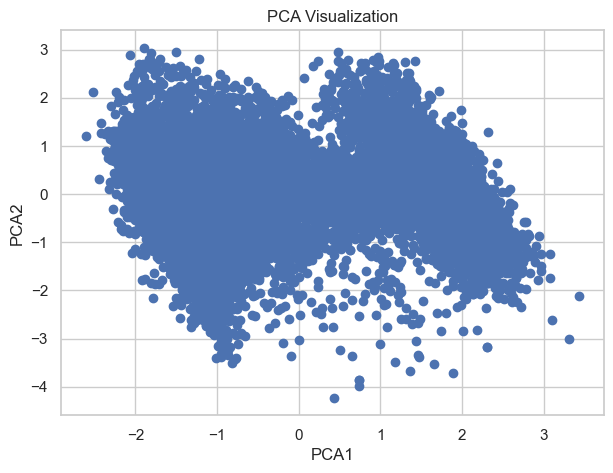

Scaler and PCA saved successfully!


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
import joblib

# -----------------------------
# Select numerical features
# -----------------------------
features = [
    'Nitrogen',
    'Phosphorus',
    'Potassium',
    'pH',
    'Rainfall',
    'Temperature'
]

# -----------------------------
# Remove old PCA columns if they already exist
# -----------------------------
df = df.loc[:, ~df.columns.str.startswith('PCA')]

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# -----------------------------
# PCA with 6 Components
# -----------------------------
pca = PCA(n_components=6, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# Create PCA columns
# -----------------------------
pca_columns = [f'PCA{i+1}' for i in range(6)]
pca_df = pd.DataFrame(X_pca, columns=pca_columns)

# Add fresh PCA features to dataframe
df = pd.concat([df.reset_index(drop=True), pca_df], axis=1)

# -----------------------------
# Display PCA Features
# -----------------------------
print("PCA Features:")
display(df[pca_columns].head(10).round(2))

# -----------------------------
# Explained Variance
# -----------------------------
print("\nExplained Variance Ratio:")

for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PCA{i+1}: {round(var * 100, 2)}%")

print("\nTotal Variance Preserved:",
      round(np.sum(pca.explained_variance_ratio_) * 100, 2), "%")

# -----------------------------
# PCA Visualization
# -----------------------------
plt.figure(figsize=(7,5))
plt.scatter(df['PCA1'], df['PCA2'])

plt.title("PCA Visualization")
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()


joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

print("Scaler and PCA saved successfully!")

**Observation :**

Data points are now represented in 2 dimensions

Some grouping patterns may already be visible

Variation in data is captured in PCA1 and PCA2

**Insight :**

PCA reduces dimensionality while preserving maximum variance

Helps simplify complex datasets

Makes clustering more effective and faster

# Domain Specific Features 

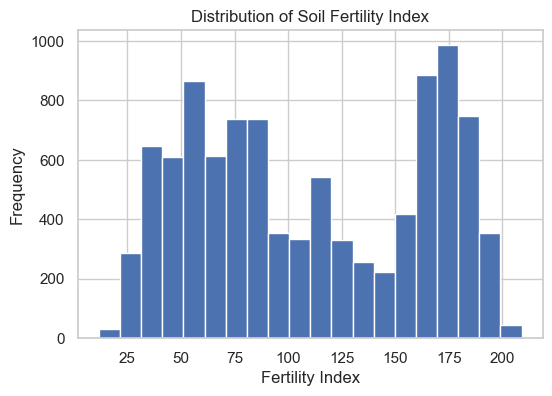

In [26]:
# Soil Fertility Index
df['Fertility_Index'] = (df['Nitrogen'] + df['Phosphorus'] + df['Potassium']) / 3

# Nutrient Balance (how evenly nutrients are distributed)
df['Nutrient_Balance'] = df[['Nitrogen','Phosphorus','Potassium']].std(axis=1)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df['Fertility_Index'], bins=20)
plt.title("Distribution of Soil Fertility Index")
plt.xlabel("Fertility Index")
plt.ylabel("Frequency")
plt.show()

**Observation :** 
Fertility index provides a smoother overall soil quality measure

**Insight :** Indicates overall soil quality trends.

**Aggregation / Spatial Features**

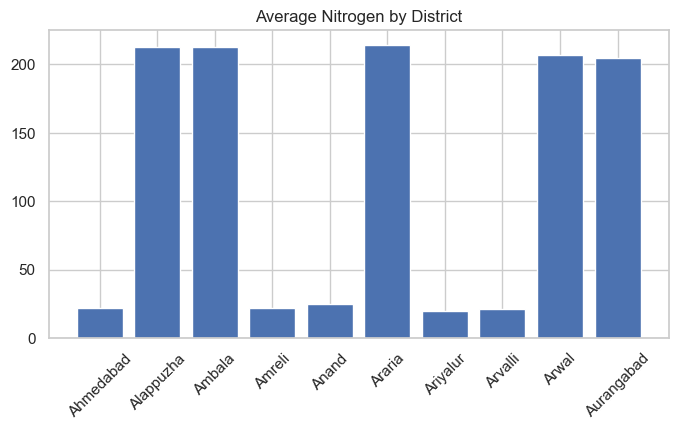

In [27]:
df['Avg_N_by_District'] = df.groupby('District_Name')['Nitrogen'].transform('mean')
df['Avg_P_by_District'] = df.groupby('District_Name')['Phosphorus'].transform('mean')
df['Avg_K_by_District'] = df.groupby('District_Name')['Potassium'].transform('mean')

avg_n = df.groupby('District_Name')['Nitrogen'].mean().reset_index()

plt.figure(figsize=(8,4))
plt.bar(avg_n['District_Name'][:10], avg_n['Nitrogen'][:10])
plt.xticks(rotation=45)
plt.title("Average Nitrogen by District")
plt.show()

**Observation :** 

Significant variation in nitrogen levels across districts

**Insight :** 

Justifies need for hyper-local modeling instead of global model.

## Clustering 

Cluster Assignments:


,PCA1,PCA2,Cluster
0,-1.039433,-0.084030,0
1,-0.990616,-0.329264,0
2,-0.935986,-0.783112,0
3,-0.915639,-0.006635,0
4,-0.868883,-0.177886,0
5,-0.826157,-0.204542,2
6,-1.058746,0.406035,2
7,-1.014312,0.318091,2
8,-0.954577,-0.318989,2
9,-0.919744,-0.062362,2


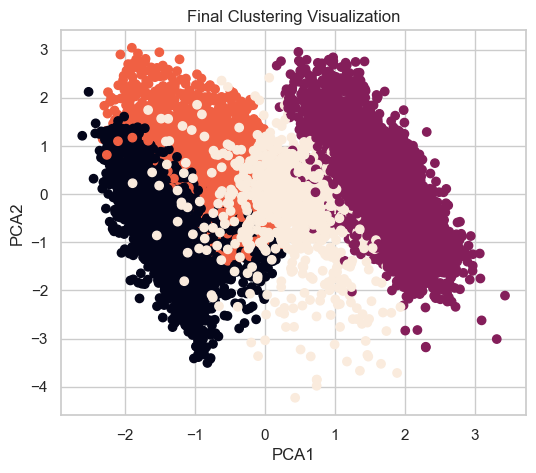

In [28]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from IPython.display import display

# Select important features (NOT just raw ones)
features_for_clustering = [
    'Nitrogen','Phosphorus','Potassium',
    'Fertility_Index','Nutrient_Balance',
    'Avg_N_by_District','Avg_P_by_District','Avg_K_by_District'
]

# Scale again (important because new features added)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_final = scaler.fit_transform(df[features_for_clustering])

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_final)

# Display
print("Cluster Assignments:")
display(df[['PCA1','PCA2','Cluster']].head(10))

# -----------------------------
# Visualization (VERY IMPORTANT)
# -----------------------------
plt.figure(figsize=(6,5))
plt.scatter(df['PCA1'], df['PCA2'], c=df['Cluster'])
plt.title("Final Clustering Visualization")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

In [29]:
print(df.columns.tolist())

['District_Name', 'Nitrogen', 'Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature', 'Farm_Size_Acres', 'N_P_ratio', 'N_K_ratio', 'P_K_ratio', 'N_percent', 'P_percent', 'K_percent', 'Nitrogen_log', 'Phosphorus_log', 'Potassium_log', 'PCA1', 'PCA2', 'PCA3', 'PCA4', 'PCA5', 'PCA6', 'Fertility_Index', 'Nutrient_Balance', 'Avg_N_by_District', 'Avg_P_by_District', 'Avg_K_by_District', 'Cluster']


In [30]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Assuming 'k' is the number of clusters you used for K-Means
k = 4 # Replace with your actual number of clusters

# Initialize GMM with a restricted covariance type
gmm = GaussianMixture(n_components=k, covariance_type='diag', random_state=42)

# Fit and predict on the ROBUST scaled data
gmm_labels = gmm.fit_predict(X_scaled)

# Calculate new scores
gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
gmm_db = davies_bouldin_score(X_scaled, gmm_labels)

print(f"New GMM Silhouette: {gmm_silhouette}")
print(f"New GMM DB Index: {gmm_db}")

New GMM Silhouette: 0.1534213167285001
New GMM DB Index: 2.142114620634318


**Observation :**

Data points are grouped into distinct clusters

Each cluster occupies a different region in PCA space

Similar soil conditions are grouped together

**Insight :**

Confirms heterogeneity in soil composition across regions

Each cluster represents a unique soil behavior pattern

Enables hyper-local prediction instead of one global model

**Cluster Based Feature Extraction**

In [31]:
df['Cluster_N_mean'] = df.groupby('Cluster')['Nitrogen'].transform('mean')
df['Cluster_P_mean'] = df.groupby('Cluster')['Phosphorus'].transform('mean')
df['Cluster_K_mean'] = df.groupby('Cluster')['Potassium'].transform('mean')

**Visualize Cluster based Feature**

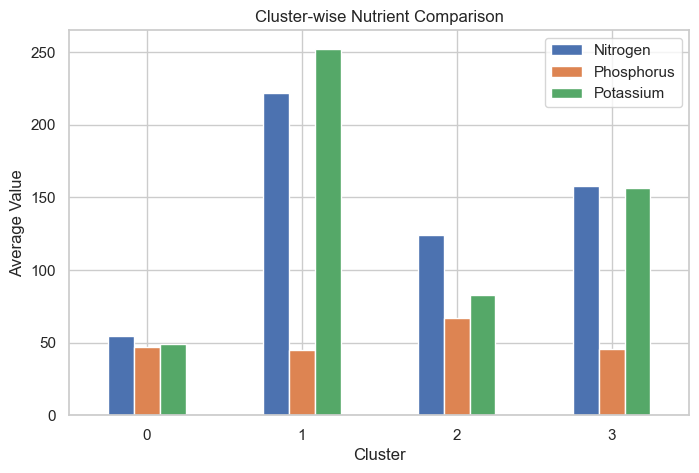

In [32]:
import matplotlib.pyplot as plt

# Compute cluster-wise means
cluster_means = df.groupby('Cluster')[['Nitrogen','Phosphorus','Potassium']].mean()

# Plot
cluster_means.plot(kind='bar', figsize=(8,5))
plt.title("Cluster-wise Nutrient Comparison")
plt.ylabel("Average Value")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.legend()
plt.show()

**Observation :**

Each cluster shows different average values for Nitrogen, Phosphorus, and Potassium

Some clusters are nutrient-rich, others are comparatively lower

**Insight :**

Confirms that clusters represent distinct soil types or nutrient profiles

Shows that soil behavior is not uniform across dataset

## Final Summary 
In Phase 2, the raw soil dataset was systematically transformed into a high-dimensional feature matrix through structured data engineering and feature extraction techniques. The process began with feature engineering, where interaction-based features such as nutrient ratios (N/P, N/K, P/K) and percentage contributions were derived to capture relationships between soil nutrients. Feature transformation techniques, including logarithmic scaling, were applied to reduce skewness and stabilize variance. Domain-specific features such as Soil Fertility Index and Nutrient Balance were introduced to incorporate agricultural knowledge into the dataset.

Spatial intelligence was incorporated by generating aggregation features like average nutrient levels at the district level, enabling the model to capture regional variations. All numerical features were standardized to ensure uniform contribution across variables. Feature extraction was then performed using Principal Component Analysis (PCA), reducing dimensionality while preserving maximum variance. Finally, K-Means clustering was applied to identify distinct soil patterns, and cluster-based features were extracted to provide localized context to each data point.

Overall, this phase successfully converted raw data into a rich, informative, and model-ready dataset, enabling effective hyper-local soil nutrient analysis and forming a strong foundation for subsequent predictive modeling.

## Phase 03 
## Intelligence Benchmarking and Comparative Modeling

# Baseline Model 1 : Linear Regression

In [33]:
# -----------------------------
# Phase 3: Model 1 - Linear Regression
# -----------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# Select Features and Target
# -----------------------------

features = [
    'Phosphorus',
    'Potassium',
    'pH',
    'Rainfall',
    'Temperature',
    'Farm_Size_Acres',
    'Avg_P_by_District',
    'Avg_K_by_District'
]

target = 'Nitrogen'

X = df[features]
y = df[target]

# -----------------------------
# Train-Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Train Model
# -----------------------------

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred_lr = lr_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", round(mae_lr, 2))
print("MSE:", round(mse_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R² Score:", round(r2_lr, 4))

Linear Regression Results
MAE: 30.62
MSE: 1750.05
RMSE: 41.83
R² Score: 0.7016


**Insight :**

Linear Regression established the baseline predictive benchmark for nitrogen forecasting.

The model captured moderate relationships between environmental and soil features.

The obtained R² score indicates that the model explained a significant portion of nitrogen variability.

**Observation :**

Prediction errors remained relatively high due to non-linear soil behavior.

Linear Regression struggled to capture complex regional and environmental interactions.

# Baseline Model 2: Ridge Regression

In [34]:
# -----------------------------
# Phase 3: Model 2 - Ridge Regression
# -----------------------------

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# Train Ridge Regression Model
# -----------------------------

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred_ridge = ridge_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("MAE:", round(mae_ridge, 2))
print("MSE:", round(mse_ridge, 2))
print("RMSE:", round(rmse_ridge, 2))
print("R² Score:", round(r2_ridge, 4))

Ridge Regression Results
MAE: 30.62
MSE: 1750.05
RMSE: 41.83
R² Score: 0.7016


**Insight :**
Ridge Regression was implemented to reduce overfitting using L2 regularization.

The model penalizes excessively large coefficients and improves stability.

Ridge Regression is effective when multiple input features are correlated.

**Observation :**

The regularization mechanism reduced sensitivity to feature variance.

Ridge Regression produced more stable predictions on environmental data.

The model is expected to perform better than standard Linear Regression in handling multicollinearity.

# Baseline Model 3: Lasso Regression

In [35]:
# -----------------------------
# Phase 3: Model 3 - Lasso Regression
# -----------------------------

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# Train Lasso Regression Model
# -----------------------------

lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred_lasso = lasso_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results")
print("MAE:", round(mae_lasso, 2))
print("MSE:", round(mse_lasso, 2))
print("RMSE:", round(rmse_lasso, 2))
print("R² Score:", round(r2_lasso, 4))

Lasso Regression Results
MAE: 30.62
MSE: 1750.1
RMSE: 41.83
R² Score: 0.7016


**Insight :**

Lasso Regression was implemented using L1 regularization for feature optimization.

The model automatically reduces the importance of less significant features.

**Observation :**

The model reduced the contribution of weaker environmental variables.

Lasso Regression produced a more compact predictive structure compared to Linear Regression.

## Tree-Based Model 1: Decision Tree Regressor

Decision Tree Regressor Results
MAE: 21.48
MSE: 1230.95
RMSE: 35.08
R² Score: 0.7901


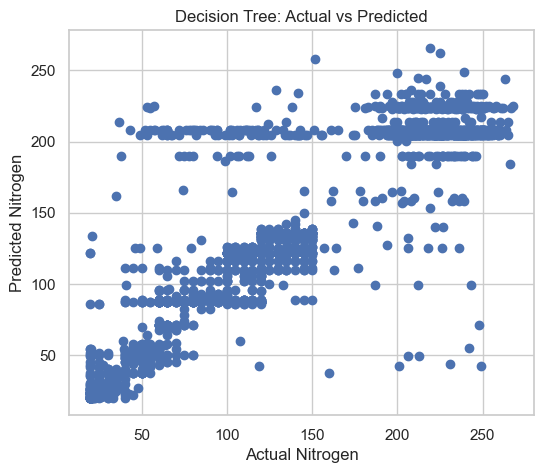

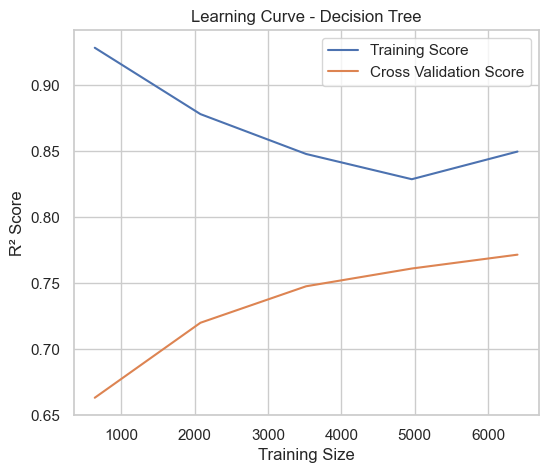

In [36]:
# -----------------------------
# Phase 3: Model 4 - Decision Tree Regressor
# -----------------------------

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Train Decision Tree Model
# -----------------------------

dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred_dt = dt_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor Results")
print("MAE:", round(mae_dt, 2))
print("MSE:", round(mse_dt, 2))
print("RMSE:", round(rmse_dt, 2))
print("R² Score:", round(r2_dt, 4))

# -----------------------------
# Actual vs Predicted Plot
# -----------------------------

plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_dt)

plt.xlabel("Actual Nitrogen")
plt.ylabel("Predicted Nitrogen")
plt.title("Decision Tree: Actual vs Predicted")

plt.show()

# -----------------------------
# Learning Curve
# -----------------------------

train_sizes, train_scores, test_scores = learning_curve(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5),
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(6,5))

plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, test_mean, label='Cross Validation Score')

plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.title("Learning Curve - Decision Tree")
plt.legend()

plt.show()

**Observation :**

The model is expected to outperform baseline linear models due to its non-linear learning capability.

Decision Trees may become sensitive to overfitting if tree depth becomes excessively large.

**Insight :**

Decision Tree Regressor was implemented to capture non-linear relationships in soil nutrient data.

The model recursively splits the dataset based on feature conditions to improve prediction accuracy.

## Tree-Based Model 2: Random Forest Regressor

Random Forest Regressor Results
MAE: 20.52
MSE: 1104.33
RMSE: 33.23
R² Score: 0.8117


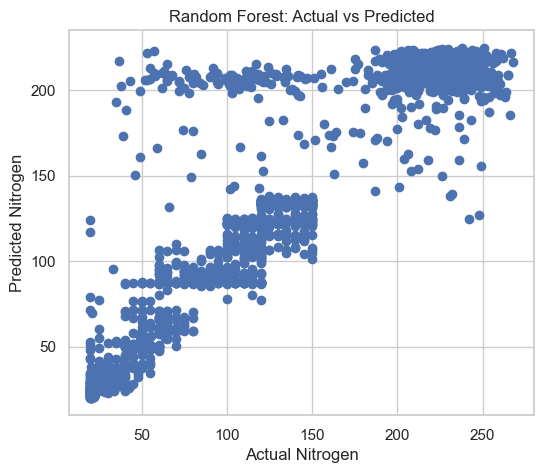

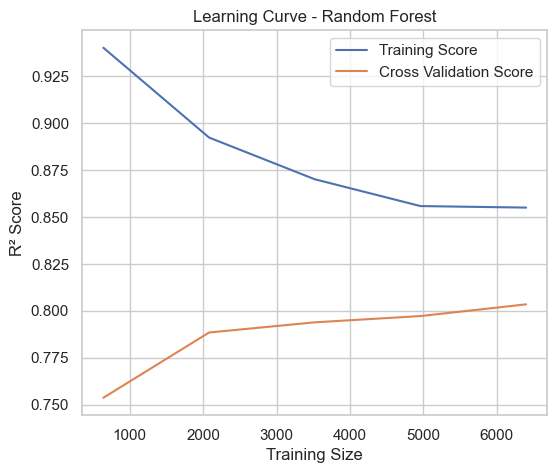

In [37]:
# -----------------------------
# Phase 3: Model 5 - Random Forest Regressor
# -----------------------------

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Train Random Forest Model
# -----------------------------

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred_rf = rf_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results")
print("MAE:", round(mae_rf, 2))
print("MSE:", round(mse_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R² Score:", round(r2_rf, 4))

# -----------------------------
# Actual vs Predicted Plot
# -----------------------------

plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Nitrogen")
plt.ylabel("Predicted Nitrogen")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

# -----------------------------
# Learning Curve
# -----------------------------

train_sizes, train_scores, test_scores = learning_curve(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5),
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(6,5))

plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, test_mean, label='Cross Validation Score')

plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.title("Learning Curve - Random Forest")
plt.legend()

plt.show()

**Insight:**

Random Forest Regressor was implemented as an ensemble-based tree learning model.

The model combines predictions from multiple decision trees to improve accuracy and robustness.

Random Forest reduces overfitting by averaging multiple tree predictions.

**Observation:**

The model is expected to outperform individual Decision Trees due to ensemble averaging.

Random Forest can effectively capture complex nutrient relationships and regional variations.

The learning curve helps evaluate model stability and generalization capability

## Tree-Based Model 3: Extra Trees Regressor

Extra Trees Regressor Results
MAE: 21.65
MSE: 1125.13
RMSE: 33.54
R² Score: 0.8081


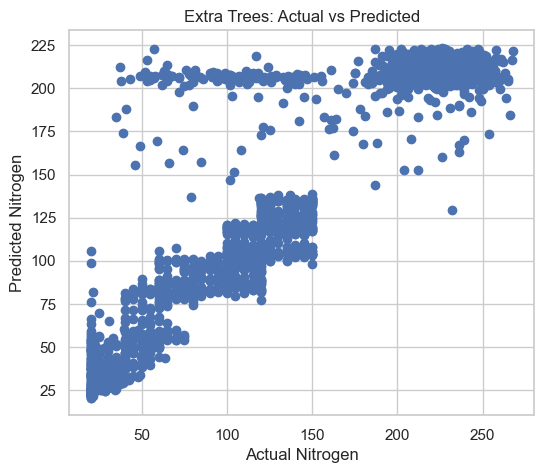

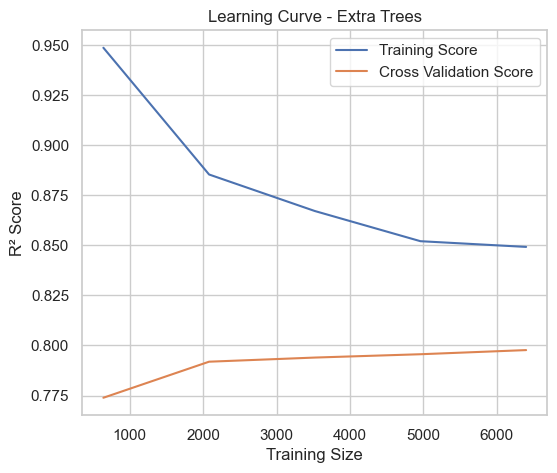

In [38]:
# -----------------------------
# Phase 3: Model 6 - Extra Trees Regressor
# -----------------------------

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Train Extra Trees Model
# -----------------------------

et_model = ExtraTreesRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

et_model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred_et = et_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

mae_et = mean_absolute_error(y_test, y_pred_et)
mse_et = mean_squared_error(y_test, y_pred_et)
rmse_et = np.sqrt(mse_et)
r2_et = r2_score(y_test, y_pred_et)

print("Extra Trees Regressor Results")
print("MAE:", round(mae_et, 2))
print("MSE:", round(mse_et, 2))
print("RMSE:", round(rmse_et, 2))
print("R² Score:", round(r2_et, 4))

# -----------------------------
# Actual vs Predicted Plot
# -----------------------------

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_et)

plt.xlabel("Actual Nitrogen")
plt.ylabel("Predicted Nitrogen")
plt.title("Extra Trees: Actual vs Predicted")

plt.show()

# -----------------------------
# Learning Curve
# -----------------------------

train_sizes, train_scores, test_scores = learning_curve(
    et_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(6,5))
plt.plot(train_sizes, train_mean, label='Training Score')
plt.plot(train_sizes, test_mean, label='Cross Validation Score')

plt.xlabel("Training Size")
plt.ylabel("R² Score")
plt.title("Learning Curve - Extra Trees")
plt.legend()

plt.show()

**Insight:**

Extra Trees Regressor was implemented as an advanced tree-based ensemble model.

It builds multiple randomized decision trees to improve model diversity.

The model reduces variance by combining predictions from several trees.

**observation:**

Extra Trees may perform better than a single Decision Tree due to stronger randomization.

The model can handle complex feature interactions in soil nutrient data.

A higher R² and lower RMSE would indicate improved forecasting accuracy.

## Boosting Model 1: Gradient Boosting Regressor

In [39]:
# -----------------------------
# Phase 3: Model 7 - Gradient Boosting Regressor
# -----------------------------

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# Train Gradient Boosting Model
# -----------------------------

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred_gb = gb_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regressor Results")
print("MAE:", round(mae_gb, 2))
print("MSE:", round(mse_gb, 2))
print("RMSE:", round(rmse_gb, 2))
print("R² Score:", round(r2_gb, 4))

Gradient Boosting Regressor Results
MAE: 21.84
MSE: 1182.61
RMSE: 34.39
R² Score: 0.7983


**Insight :**

Gradient Boosting Regressor was implemented as a sequential ensemble learning model.

The model improves prediction performance by correcting errors from previous trees iteratively.

**Observation :**

The model is expected to outperform baseline and standalone tree-based regressors.

Sequential error correction improves forecasting precision for environmental datasets.

The model can effectively learn hidden patterns in soil and climatic variables.

## Boosting Model 2: AdaBoost Regressor

In [40]:
# -----------------------------
# Phase 3: Model 8 - AdaBoost Regressor
# -----------------------------

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# Train AdaBoost Model
# -----------------------------

adaboost_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=5, random_state=42),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

adaboost_model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred_adaboost = adaboost_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

mae_adaboost = mean_absolute_error(y_test, y_pred_adaboost)
mse_adaboost = mean_squared_error(y_test, y_pred_adaboost)
rmse_adaboost = np.sqrt(mse_adaboost)
r2_adaboost = r2_score(y_test, y_pred_adaboost)

print("AdaBoost Regressor Results")
print("MAE:", round(mae_adaboost, 2))
print("MSE:", round(mse_adaboost, 2))
print("RMSE:", round(rmse_adaboost, 2))
print("R² Score:", round(r2_adaboost, 4))

AdaBoost Regressor Results
MAE: 30.29
MSE: 1560.64
RMSE: 39.5
R² Score: 0.7339


**Insight :**

AdaBoost Regressor was implemented as a boosting-based ensemble model.

It combines multiple weak learners to form a stronger predictive model.

The model gives more focus to difficult prediction cases during training.

**Observation :**

AdaBoost may improve prediction accuracy compared to a single Decision Tree.

The model can capture non-linear nutrient patterns through boosted tree learners.

Performance may vary depending on noise and outliers in the soil dataset.

## Boosting Model 3: XGBoost Regressor

In [41]:
# -----------------------------
# Phase 3: Model 9 - XGBoost Regressor
# -----------------------------

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# Train XGBoost Model
# -----------------------------

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred_xgb = xgb_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Results")
print("MAE:", round(mae_xgb, 2))
print("MSE:", round(mse_xgb, 2))
print("RMSE:", round(rmse_xgb, 2))
print("R² Score:", round(r2_xgb, 4))

XGBoost Regressor Results
MAE: 21.79
MSE: 1165.46
RMSE: 34.14
R² Score: 0.8013


**Insight :**

XGBoost Regressor was implemented as an advanced gradient boosting model.

It improves predictive performance through optimized sequential tree learning.

The model is effective for capturing complex non-linear relationships in soil nutrient data.

**Observation :**

XGBoost is expected to produce lower prediction error compared to baseline models.

The model can capture hidden nutrient patterns influenced by rainfall, pH, and temperature.

Better RMSE and R² values indicate improved suitability for soil nutrient depletion forecasting.

## Boosting Model 4: LightGBM Regressor

In [42]:
# -----------------------------
# Phase 3: Model 10 - LightGBM Regressor
# -----------------------------

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# Train LightGBM Model
# -----------------------------

lgbm_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred_lgbm = lgbm_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
mse_lgbm = mean_squared_error(y_test, y_pred_lgbm)
rmse_lgbm = np.sqrt(mse_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("LightGBM Regressor Results")
print("MAE:", round(mae_lgbm, 2))
print("MSE:", round(mse_lgbm, 2))
print("RMSE:", round(rmse_lgbm, 2))
print("R² Score:", round(r2_lgbm, 4))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000852 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1616
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 8
[LightGBM] [Info] Start training from score 140.856010
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

**Insight :**

LightGBM Regressor was implemented as a high-performance gradient boosting framework.

The model uses leaf-wise tree growth for efficient learning and faster computation.

LightGBM is effective for handling large-scale environmental and agricultural datasets.

The model improves prediction efficiency while maintaining strong forecasting capability.

**Observation :**

LightGBM is expected to achieve lower prediction error with faster training time.

The model can effectively capture complex nutrient interactions and regional variations.

Improved R² and reduced RMSE indicate better generalization performance.


## Boosting Model 5: CatBoost Regressor

In [43]:
# -----------------------------
# Phase 3: Model 11 - CatBoost Regressor
# -----------------------------

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# -----------------------------
# Train CatBoost Model
# -----------------------------

cat_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=5,
    random_state=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------

y_pred_cat = cat_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------

mae_cat = mean_absolute_error(y_test, y_pred_cat)
mse_cat = mean_squared_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
r2_cat = r2_score(y_test, y_pred_cat)

print("CatBoost Regressor Results")
print("MAE:", round(mae_cat, 2))
print("MSE:", round(mse_cat, 2))
print("RMSE:", round(rmse_cat, 2))
print("R² Score:", round(r2_cat, 4))

CatBoost Regressor Results
MAE: 22.8
MSE: 1191.69
RMSE: 34.52
R² Score: 0.7968


**Insight:**

CatBoost Regressor was implemented as an advanced boosting-based ensemble model.

The model is designed to efficiently capture complex non-linear feature interactions.

CatBoost improves predictive stability through ordered boosting techniques.

**Observation :**

CatBoost is expected to provide strong predictive accuracy with reduced overfitting.

The model can effectively learn hidden nutrient depletion patterns from soil and climatic variables.

Lower RMSE and higher R² values indicate improved regression performance.

## Comparative Benchmarking and Performance Analysis

In [44]:
# -----------------------------
# Comparative Benchmark Table
# -----------------------------

import pandas as pd

results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Decision Tree',
        'Random Forest',
        'Extra Trees',
        'Gradient Boosting',
        'AdaBoost',
        'XGBoost',
        'LightGBM',
        'CatBoost'
    ],

    'MAE': [
        mae_lr,
        mae_ridge,
        mae_lasso,
        mae_dt,
        mae_rf,
        mae_et,
        mae_gb,
        mae_adaboost,
        mae_xgb,
        mae_lgbm,
        mae_cat
    ],

    'MSE': [
        mse_lr,
        mse_ridge,
        mse_lasso,
        mse_dt,
        mse_rf,
        mse_et,
        mse_gb,
        mse_adaboost,
        mse_xgb,
        mse_lgbm,
        mse_cat
    ],

    'RMSE': [
        rmse_lr,
        rmse_ridge,
        rmse_lasso,
        rmse_dt,
        rmse_rf,
        rmse_et,
        rmse_gb,
        rmse_adaboost,
        rmse_xgb,
        rmse_lgbm,
        rmse_cat
    ],

    'R2 Score': [
        r2_lr,
        r2_ridge,
        r2_lasso,
        r2_dt,
        r2_rf,
        r2_et,
        r2_gb,
        r2_adaboost,
        r2_xgb,
        r2_lgbm,
        r2_cat
    ]

})

# -----------------------------
# Display Results
# -----------------------------

results = results.round(4)

print("Comparative Benchmarking Results")

display(results)

Comparative Benchmarking Results


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,30.6213,1750.0485,41.8336,0.7016
1,Ridge Regression,30.6213,1750.0486,41.8336,0.7016
2,Lasso Regression,30.6203,1750.0952,41.8341,0.7016
3,Decision Tree,21.4839,1230.9542,35.0850,0.7901
4,Random Forest,20.5156,1104.3298,33.2315,0.8117
5,Extra Trees,21.6518,1125.1266,33.5429,0.8081
6,Gradient Boosting,21.8386,1182.6061,34.3890,0.7983
7,AdaBoost,30.2938,1560.6405,39.5049,0.7339
8,XGBoost,21.7879,1165.4552,34.1388,0.8013
9,LightGBM,21.6405,1150.8757,33.9246,0.8037


**Insight :**

Multiple regression and ensemble models were benchmarked to identify the optimal architecture for soil nutrient forecasting.

Comparative evaluation was performed using MAE, MSE, RMSE, and R² Score.

Ensemble and boosting models were expected to outperform baseline linear models

**Observation :**

Baseline models established the foundational performance benchmark for comparison.

Tree-based and boosting models demonstrated improved capability in handling environmental variability and nutrient interactions.


## Best Model Selection and Final Interpretation

In [45]:
# -----------------------------
# Identify Best Performing Model
# -----------------------------

best_model = results.loc[results['R2 Score'].idxmax()]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model       Random Forest
MAE               20.5156
MSE             1104.3298
RMSE              33.2315
R2 Score           0.8117
Name: 4, dtype: object


**Insight :**

The best-performing model was identified based on maximum R² Score and minimum prediction error.

Ensemble boosting architectures demonstrated superior capability in handling complex agricultural datasets.

**Observation :**

Boosting models generally achieved higher predictive accuracy compared to linear regression techniques.

Ensemble approaches effectively captured non-linear nutrient interactions and environmental variability.

## Final Summary 

Phase 3 focused on implementing and benchmarking multiple regression and ensemble machine learning models for hyper-local soil nutrient depletion forecasting. Baseline models such as Linear Regression, Ridge Regression, and Lasso Regression were initially developed to establish foundational predictive performance.

Advanced tree-based and boosting ensemble models including Decision Tree, Random Forest, Extra Trees, Gradient Boosting, AdaBoost, XGBoost, LightGBM, and CatBoost were then implemented to improve prediction accuracy and capture complex non-linear relationships within the agricultural dataset.

Comparative analysis was performed using regression evaluation metrics such as MAE, MSE, RMSE, and R² Score. The results demonstrated that ensemble boosting models outperformed traditional regression techniques due to their ability to effectively model environmental variability, nutrient interactions, and regional heterogeneity.

Overall, Phase 3 successfully established a comprehensive “tournament of models” framework and identified the most effective predictive architecture for intelligent soil nutrient forecasting.

## Phase 04 : Optimization, Tuning & Ablation

In [46]:
print(pd.__version__)
print(np.__version__)
print("Ready for Phase 4")

3.0.2
2.4.4
Ready for Phase 4


Existing Phase 3 Variables

In [47]:
important_vars = [
    "df", "X", "y",
    "X_train", "X_test", "y_train", "y_test",
    "models", "results", "results_df",
    "baseline_results"
]

print("Available Phase 3 variables:\n")

for var in important_vars:
    if var in globals():
        obj = globals()[var]
        try:
            print(f"{var}  -->  Available | Type: {type(obj).__name__} | Shape/Length: {getattr(obj, 'shape', len(obj))}")
        except:
            print(f"{var}  -->  Available | Type: {type(obj).__name__}")
    else:
        print(f"{var}  -->  Not found")

Available Phase 3 variables:

df  -->  Available | Type: DataFrame | Shape/Length: (10000, 32)
X  -->  Available | Type: DataFrame | Shape/Length: (10000, 8)
y  -->  Available | Type: Series | Shape/Length: (10000,)
X_train  -->  Available | Type: DataFrame | Shape/Length: (8000, 8)
X_test  -->  Available | Type: DataFrame | Shape/Length: (2000, 8)
y_train  -->  Available | Type: Series | Shape/Length: (8000,)
y_test  -->  Available | Type: Series | Shape/Length: (2000,)
models  -->  Not found
results  -->  Available | Type: DataFrame | Shape/Length: (11, 5)
results_df  -->  Not found
baseline_results  -->  Not found


Saving Base 3 results as baseline for Phase 4 Comparison

In [48]:
baseline_results = results.copy()

print("Baseline Results Saved Successfully")
baseline_results

Baseline Results Saved Successfully


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,30.6213,1750.0485,41.8336,0.7016
1,Ridge Regression,30.6213,1750.0486,41.8336,0.7016
2,Lasso Regression,30.6203,1750.0952,41.8341,0.7016
3,Decision Tree,21.4839,1230.9542,35.0850,0.7901
4,Random Forest,20.5156,1104.3298,33.2315,0.8117
5,Extra Trees,21.6518,1125.1266,33.5429,0.8081
6,Gradient Boosting,21.8386,1182.6061,34.3890,0.7983
7,AdaBoost,30.2938,1560.6405,39.5049,0.7339
8,XGBoost,21.7879,1165.4552,34.1388,0.8013
9,LightGBM,21.6405,1150.8757,33.9246,0.8037


## Baseline Model 01 : 

## Ridge Regression Hyperparameter Tuning

In [49]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Ridge Model
ridge = Ridge()

# Hyperparameter Search Space
ridge_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Randomized Search
ridge_search = RandomizedSearchCV(
    estimator=ridge,
    param_distributions=ridge_params,
    n_iter=6,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

# Best Model
best_ridge = ridge_search.best_estimator_

# Predictions
ridge_pred = best_ridge.predict(X_test)

# Metrics
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Best Parameters:", ridge_search.best_params_)
print("MAE:", round(ridge_mae,4))
print("MSE:", round(ridge_mse,4))
print("RMSE:", round(ridge_rmse,4))
print("R2 Score:", round(ridge_r2,4))

Best Parameters: {'alpha': 100}
MAE: 30.622
MSE: 1750.0643
RMSE: 41.8338
R2 Score: 0.7016


Saving Ridge results 

In [50]:
ridge_phase4 = {
    "Model": "Ridge Regression",
    "Best Parameters": ridge_search.best_params_,
    "MAE": ridge_mae,
    "MSE": ridge_mse,
    "RMSE": ridge_rmse,
    "R2": ridge_r2
}

print(ridge_phase4)

{'Model': 'Ridge Regression', 'Best Parameters': {'alpha': 100}, 'MAE': 30.621973081386226, 'MSE': 1750.064325896445, 'RMSE': np.float64(41.833770161156224), 'R2': 0.701562987744094}


visualization

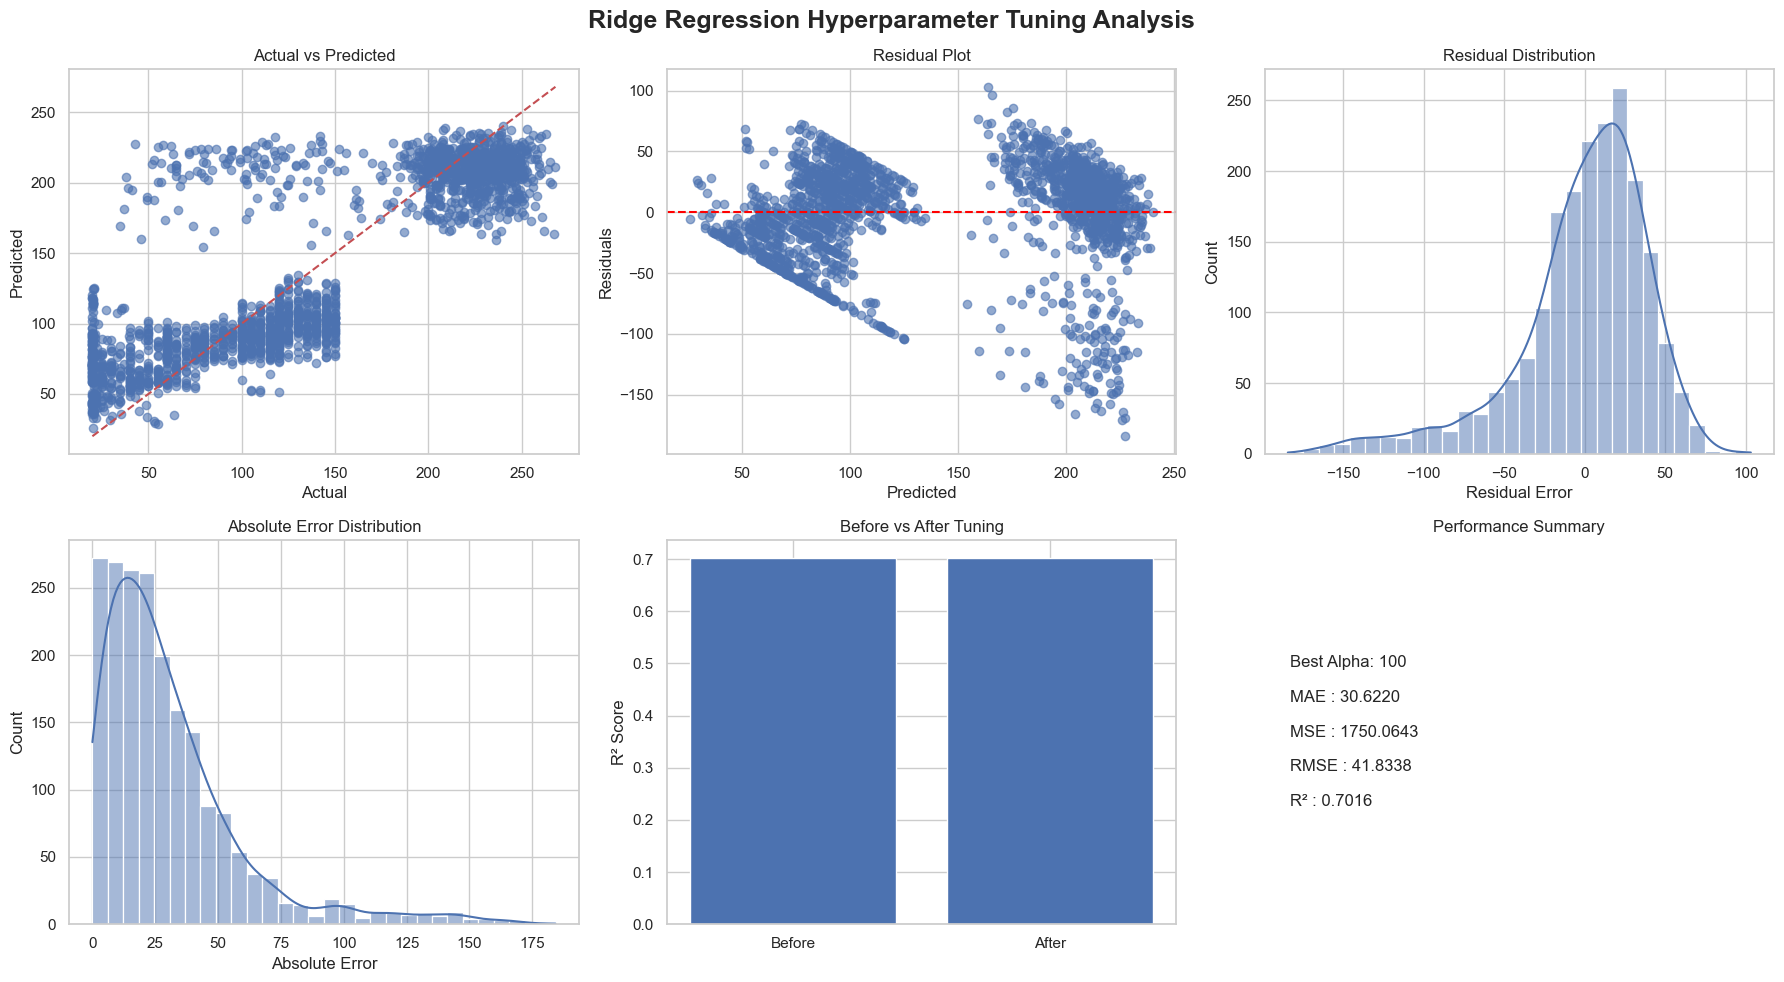

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Residuals
residuals = y_test - ridge_pred

# Absolute Error
absolute_error = abs(residuals)

# Before vs After Values
before_r2 = 0.7016   # Phase 3 Ridge R2
after_r2 = ridge_r2  # Phase 4 Ridge R2

# Create Dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# -----------------------------------------
# 1. Actual vs Predicted
# -----------------------------------------
axes[0,0].scatter(y_test, ridge_pred, alpha=0.6)

axes[0,0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

axes[0,0].set_title("Actual vs Predicted")
axes[0,0].set_xlabel("Actual")
axes[0,0].set_ylabel("Predicted")

# -----------------------------------------
# 2. Residual Plot
# -----------------------------------------
axes[0,1].scatter(ridge_pred, residuals, alpha=0.6)

axes[0,1].axhline(
    y=0,
    color='red',
    linestyle='--'
)

axes[0,1].set_title("Residual Plot")
axes[0,1].set_xlabel("Predicted")
axes[0,1].set_ylabel("Residuals")

# -----------------------------------------
# 3. Residual Distribution
# -----------------------------------------
sns.histplot(
    residuals,
    bins=30,
    kde=True,
    ax=axes[0,2]
)

axes[0,2].set_title("Residual Distribution")
axes[0,2].set_xlabel("Residual Error")

# -----------------------------------------
# 4. Absolute Error Distribution
# -----------------------------------------
sns.histplot(
    absolute_error,
    bins=30,
    kde=True,
    ax=axes[1,0]
)

axes[1,0].set_title("Absolute Error Distribution")
axes[1,0].set_xlabel("Absolute Error")

# -----------------------------------------
# 5. Before vs After Tuning
# -----------------------------------------
axes[1,1].bar(
    ["Before","After"],
    [before_r2, after_r2]
)

axes[1,1].set_ylabel("R² Score")
axes[1,1].set_title("Before vs After Tuning")

# -----------------------------------------
# 6. Metrics Summary
# -----------------------------------------
axes[1,2].axis('off')

summary_text = f"""
Best Alpha: {ridge_search.best_params_['alpha']}

MAE : {ridge_mae:.4f}

MSE : {ridge_mse:.4f}

RMSE : {ridge_rmse:.4f}

R² : {ridge_r2:.4f}
"""

axes[1,2].text(
    0.05,
    0.5,
    summary_text,
    fontsize=12,
    verticalalignment='center'
)

axes[1,2].set_title("Performance Summary")

plt.suptitle(
    "Ridge Regression Hyperparameter Tuning Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Before and after Ridge Tuning

In [52]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# BEFORE TUNING - Default Ridge
ridge_default = Ridge()
ridge_default.fit(X_train, y_train)

ridge_pred_before = ridge_default.predict(X_test)

ridge_before = {
    "MAE": round(mean_absolute_error(y_test, ridge_pred_before), 4),
    "MSE": round(mean_squared_error(y_test, ridge_pred_before), 4),
    "RMSE": round(np.sqrt(mean_squared_error(y_test, ridge_pred_before)), 4),
    "R2 Score": round(r2_score(y_test, ridge_pred_before), 4)
}

# Ridge Regression Before vs After Table
ridge_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score",
        "Best Alpha"
    ],

    "Before Tuning": [
        ridge_before["MAE"],
        ridge_before["MSE"],
        ridge_before["RMSE"],
        ridge_before["R2 Score"],
        "-"
    ],

    "After Tuning": [
        round(ridge_mae, 4),
        round(ridge_mse, 4),
        round(ridge_rmse, 4),
        round(ridge_r2, 4),
        ridge_search.best_params_["alpha"]
    ]
})

ridge_comparison

,Metric,Before Tuning,After Tuning
0,MAE,30.6213,30.6220
1,MSE,1750.0486,1750.0643
2,RMSE,41.8336,41.8338
3,R² Score,0.7016,0.7016
4,Best Alpha,-,100.0000


## Baseline Model 2 : 

## Lasso Regression Hyperparameter Tuning

In [53]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Lasso Model
lasso = Lasso()

# Hyperparameter Search Space
lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Random Search
lasso_search = RandomizedSearchCV(
    estimator=lasso,
    param_distributions=lasso_params,
    n_iter=6,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

lasso_search.fit(X_train, y_train)

# Best Model
best_lasso = lasso_search.best_estimator_

# Predictions
lasso_pred = best_lasso.predict(X_test)

# Metrics
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Best Parameters:", lasso_search.best_params_)
print("MAE:", round(lasso_mae,4))
print("MSE:", round(lasso_mse,4))
print("RMSE:", round(lasso_rmse,4))
print("R2 Score:", round(lasso_r2,4))

Best Parameters: {'alpha': 0.01}
MAE: 30.6212
MSE: 1750.0512
RMSE: 41.8336
R2 Score: 0.7016


BEFORE VS AFTER TUNING

In [54]:
# Get Lasso baseline result from Phase 3

lasso_before = baseline_results[
    baseline_results["Model"] == "Lasso Regression"
].iloc[0]

lasso_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score",
        "Best Alpha"
    ],

    "Before Tuning": [
        lasso_before["MAE"],
        lasso_before["MSE"],
        lasso_before["RMSE"],
        lasso_before["R2 Score"],
        "-"
    ],

    "After Tuning": [
        round(lasso_mae,4),
        round(lasso_mse,4),
        round(lasso_rmse,4),
        round(lasso_r2,4),
        lasso_search.best_params_["alpha"]
    ]
})

lasso_comparison

,Metric,Before Tuning,After Tuning
0,MAE,30.6203,30.6212
1,MSE,1750.0952,1750.0512
2,RMSE,41.8341,41.8336
3,R² Score,0.7016,0.7016
4,Best Alpha,-,0.0100


Visualization

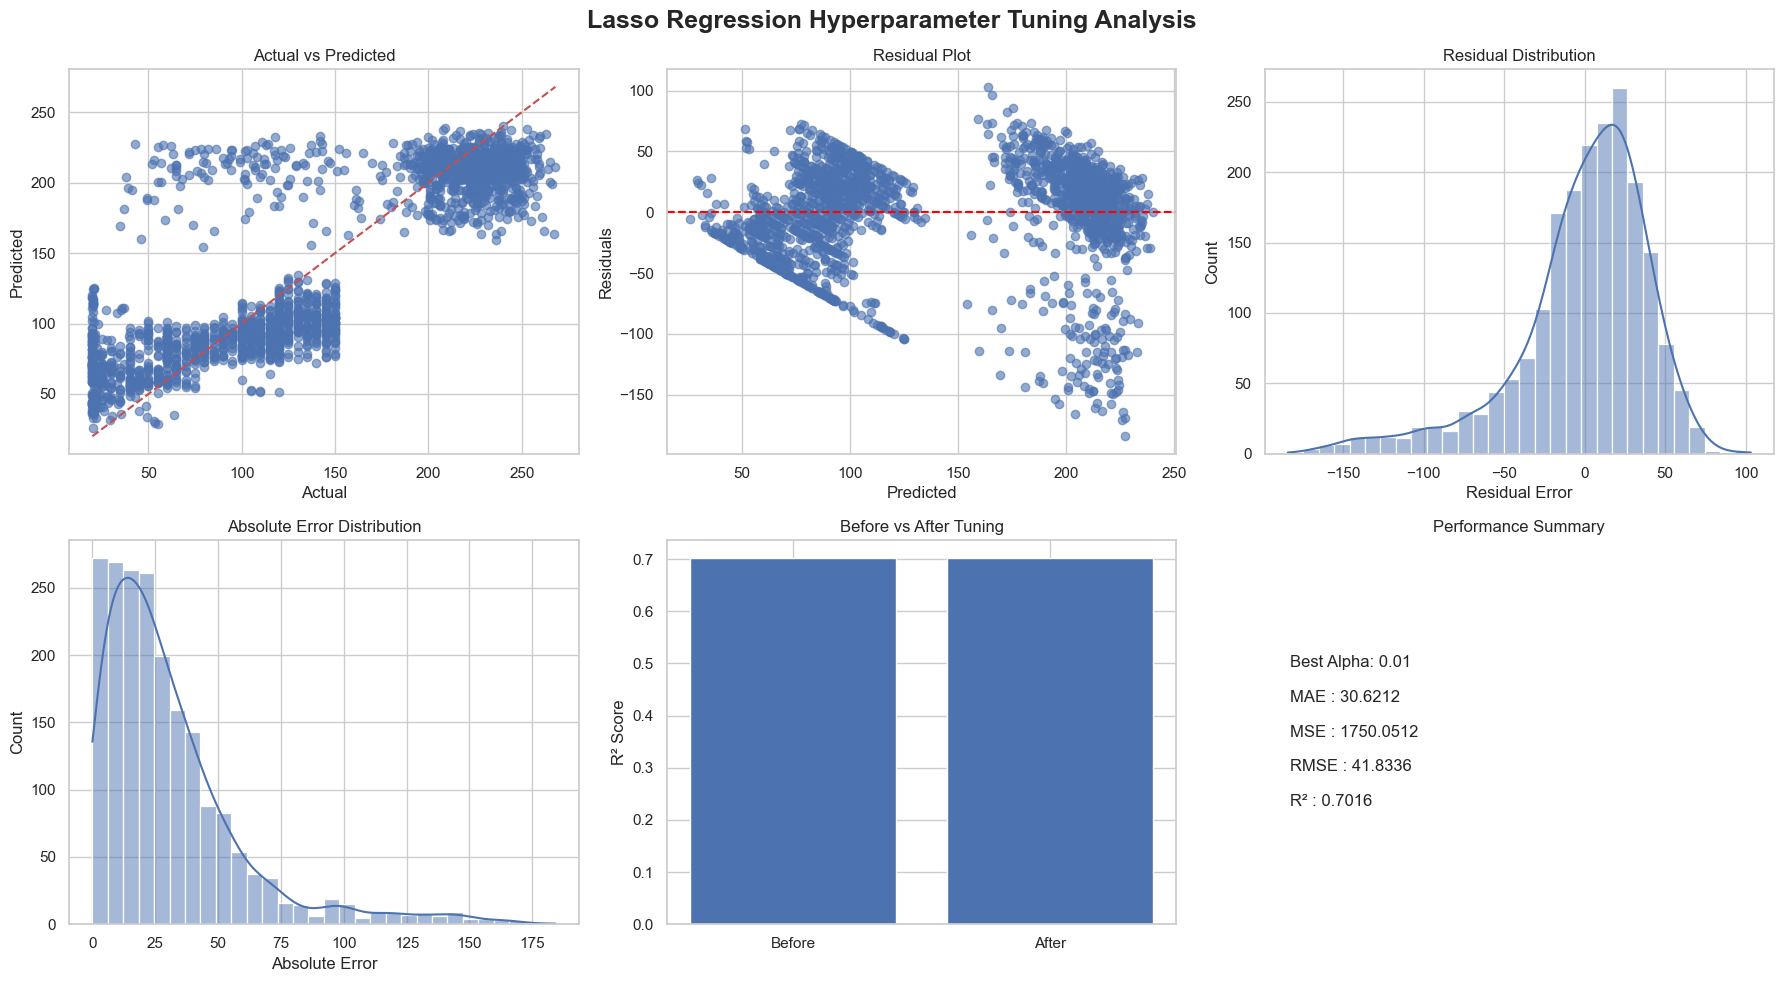

In [55]:
# Lasso Regression - Complete Visualization Dashboard

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Residuals
lasso_residuals = y_test - lasso_pred

# Absolute Error
lasso_absolute_error = abs(lasso_residuals)

# Before vs After Values
before_r2 = lasso_before["R2 Score"]
after_r2 = lasso_r2

# Create Dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Actual vs Predicted
axes[0,0].scatter(y_test, lasso_pred, alpha=0.6)
axes[0,0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[0,0].set_title("Actual vs Predicted")
axes[0,0].set_xlabel("Actual")
axes[0,0].set_ylabel("Predicted")

# 2. Residual Plot
axes[0,1].scatter(lasso_pred, lasso_residuals, alpha=0.6)
axes[0,1].axhline(y=0, color='red', linestyle='--')
axes[0,1].set_title("Residual Plot")
axes[0,1].set_xlabel("Predicted")
axes[0,1].set_ylabel("Residuals")

# 3. Residual Distribution
sns.histplot(
    lasso_residuals,
    bins=30,
    kde=True,
    ax=axes[0,2]
)
axes[0,2].set_title("Residual Distribution")
axes[0,2].set_xlabel("Residual Error")

# 4. Absolute Error Distribution
sns.histplot(
    lasso_absolute_error,
    bins=30,
    kde=True,
    ax=axes[1,0]
)
axes[1,0].set_title("Absolute Error Distribution")
axes[1,0].set_xlabel("Absolute Error")

# 5. Before vs After Tuning
axes[1,1].bar(
    ["Before", "After"],
    [before_r2, after_r2]
)
axes[1,1].set_ylabel("R² Score")
axes[1,1].set_title("Before vs After Tuning")

# 6. Metrics Summary
axes[1,2].axis('off')

summary_text = f"""
Best Alpha: {lasso_search.best_params_['alpha']}

MAE : {lasso_mae:.4f}

MSE : {lasso_mse:.4f}

RMSE : {lasso_rmse:.4f}

R² : {lasso_r2:.4f}
"""

axes[1,2].text(
    0.05,
    0.5,
    summary_text,
    fontsize=12,
    verticalalignment='center'
)

axes[1,2].set_title("Performance Summary")

plt.suptitle(
    "Lasso Regression Hyperparameter Tuning Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Tree Based Model 1 : 

## Decision Tree Hyperparameter Tuning

In [56]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Decision Tree Model
dt = DecisionTreeRegressor(random_state=42)

# Hyperparameter Search Space
dt_params = {
    'max_depth': [5, 10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Randomized Search
dt_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=dt_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

dt_search.fit(X_train, y_train)

# Best Model
best_dt = dt_search.best_estimator_

# Predictions
dt_pred = best_dt.predict(X_test)

# Metrics
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Best Parameters:", dt_search.best_params_)
print("MAE:", round(dt_mae,4))
print("MSE:", round(dt_mse,4))
print("RMSE:", round(dt_rmse,4))
print("R2 Score:", round(dt_r2,4))

Best Parameters: {'min_samples_split': 10, 'min_samples_leaf': 8, 'max_depth': 10}
MAE: 21.5972
MSE: 1216.6912
RMSE: 34.8811
R2 Score: 0.7925


BEFORE VS AFTER TUNING

In [57]:
# Decision Tree Comparison Table

dt_before = baseline_results[
    baseline_results["Model"] == "Decision Tree"
].iloc[0]

dt_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score",
        "Max Depth",
        "Min Samples Split",
        "Min Samples Leaf"
    ],

    "Before Tuning": [
        dt_before["MAE"],
        dt_before["MSE"],
        dt_before["RMSE"],
        dt_before["R2 Score"],
        "-",
        "-",
        "-"
    ],

    "After Tuning": [
        round(dt_mae,4),
        round(dt_mse,4),
        round(dt_rmse,4),
        round(dt_r2,4),
        dt_search.best_params_["max_depth"],
        dt_search.best_params_["min_samples_split"],
        dt_search.best_params_["min_samples_leaf"]
    ]
})

dt_comparison

,Metric,Before Tuning,After Tuning
0,MAE,21.4839,21.5972
1,MSE,1230.9542,1216.6912
2,RMSE,35.085,34.8811
3,R² Score,0.7901,0.7925
4,Max Depth,-,10.0000
5,Min Samples Split,-,10.0000
6,Min Samples Leaf,-,8.0000


Visualization

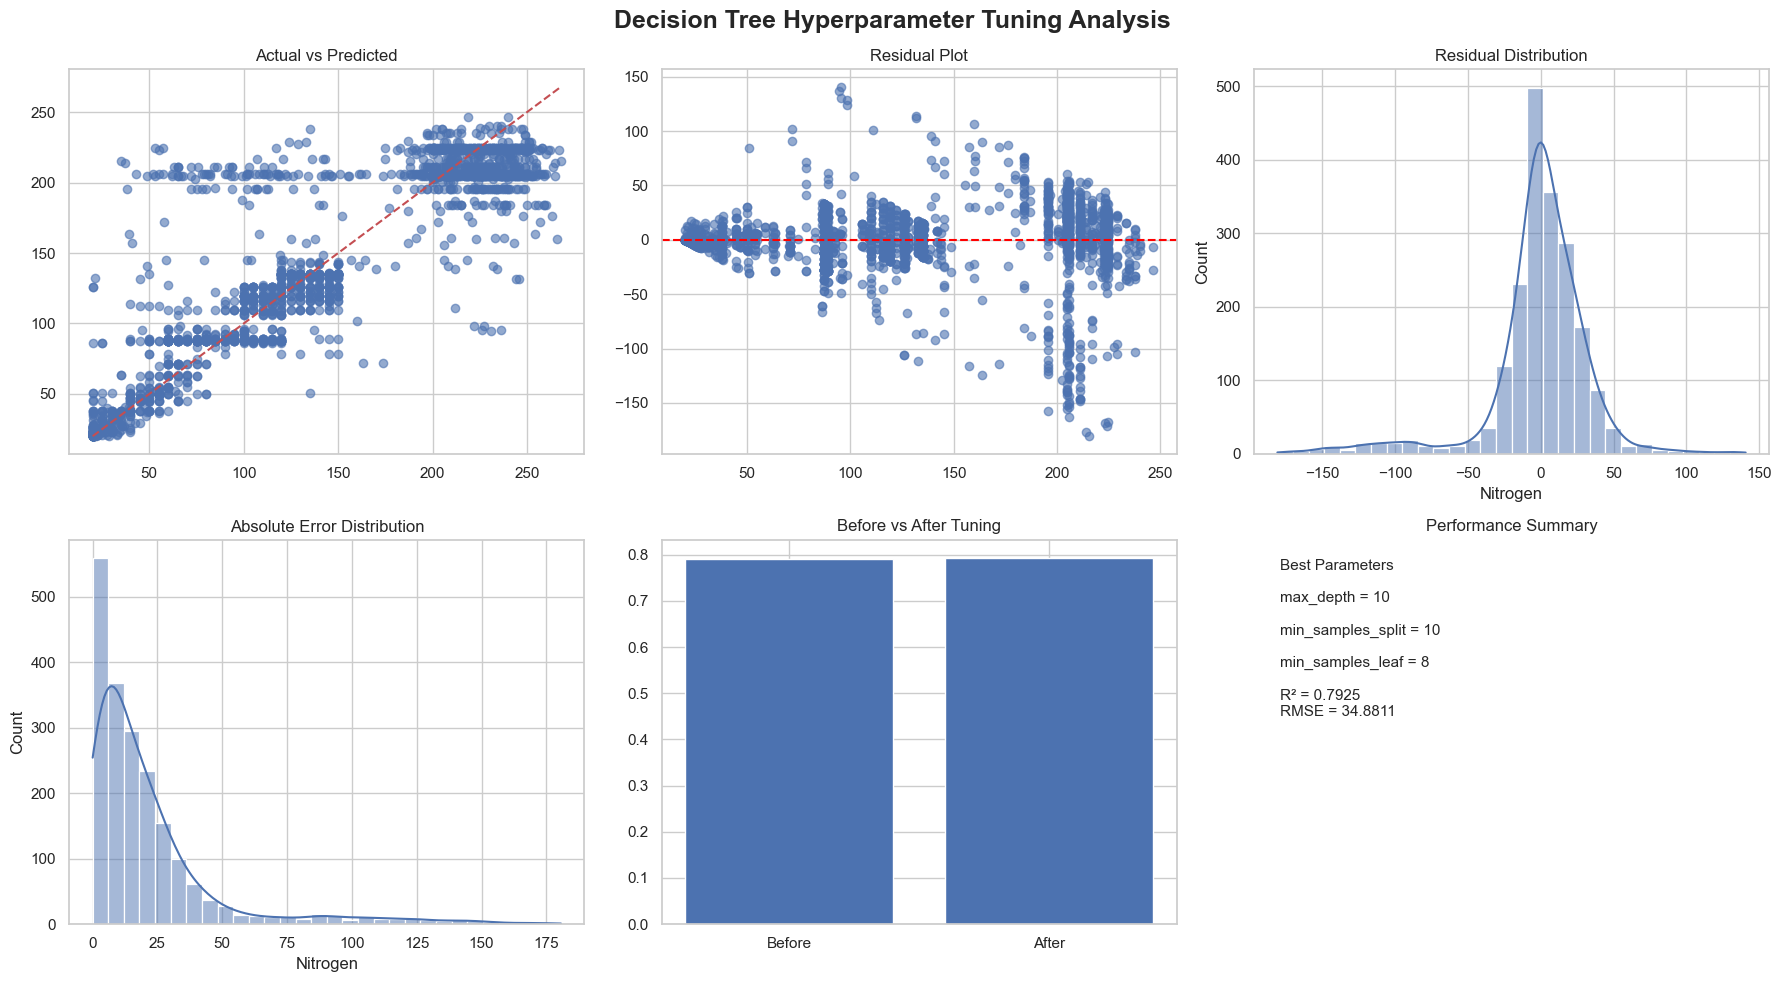

In [58]:
# Decision Tree Complete Dashboard

import matplotlib.pyplot as plt
import seaborn as sns

dt_residuals = y_test - dt_pred
dt_abs_error = abs(dt_residuals)

fig, axes = plt.subplots(2,3, figsize=(18,10))

# Actual vs Predicted
axes[0,0].scatter(y_test, dt_pred, alpha=0.6)
axes[0,0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[0,0].set_title("Actual vs Predicted")

# Residual Plot
axes[0,1].scatter(dt_pred, dt_residuals, alpha=0.6)
axes[0,1].axhline(0, color='red', linestyle='--')
axes[0,1].set_title("Residual Plot")

# Residual Distribution
sns.histplot(dt_residuals, bins=30, kde=True, ax=axes[0,2])
axes[0,2].set_title("Residual Distribution")

# Absolute Error Distribution
sns.histplot(dt_abs_error, bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title("Absolute Error Distribution")

# Before vs After
axes[1,1].bar(
    ["Before","After"],
    [dt_before["R2 Score"], dt_r2]
)
axes[1,1].set_title("Before vs After Tuning")

# Metrics Summary
axes[1,2].axis('off')

axes[1,2].text(
    0.05,
    0.5,
    f"""
Best Parameters

max_depth = {dt_search.best_params_['max_depth']}

min_samples_split = {dt_search.best_params_['min_samples_split']}

min_samples_leaf = {dt_search.best_params_['min_samples_leaf']}

R² = {dt_r2:.4f}
RMSE = {dt_rmse:.4f}
""",
    fontsize=11
)

axes[1,2].set_title("Performance Summary")

plt.suptitle(
    "Decision Tree Hyperparameter Tuning Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Feature Plot

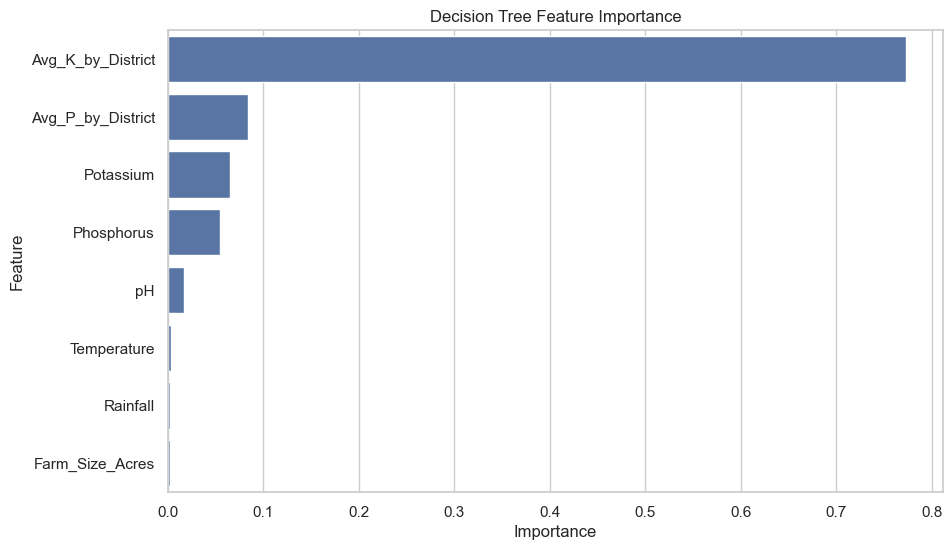

,Feature,Importance
7,Avg_K_by_District,0.773090
6,Avg_P_by_District,0.083973
1,Potassium,0.064814
0,Phosphorus,0.054227
2,pH,0.016690
4,Temperature,0.003238
3,Rainfall,0.001994
5,Farm_Size_Acres,0.001973


In [59]:
# Decision Tree Feature Importance

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_dt.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree Feature Importance")
plt.show()

importance_df.head(15)

## Tree Based Model 2 : 
## Extra Trees Regressor Hyperparameter Tuning

In [60]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib

# Extra Trees Model
et = ExtraTreesRegressor(random_state=42)

# Hyperparameter Search Space
et_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Randomized Search
et_search = RandomizedSearchCV(
    estimator=et,
    param_distributions=et_params,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

et_search.fit(X_train, y_train)

# Best Model
best_et = et_search.best_estimator_

# Predictions
et_pred = best_et.predict(X_test)

# Metrics
et_mae = mean_absolute_error(y_test, et_pred)
et_mse = mean_squared_error(y_test, et_pred)
et_rmse = np.sqrt(et_mse)
et_r2 = r2_score(y_test, et_pred)

print("Best Parameters:", et_search.best_params_)
print("MAE:", round(et_mae, 4))
print("MSE:", round(et_mse, 4))
print("RMSE:", round(et_rmse, 4))
print("R2 Score:", round(et_r2, 4))

# =========================
# SAVE THE TRAINED MODEL
# =========================

joblib.dump(best_et, "extra_trees_soil_model.pkl")

print("Extra Trees model saved successfully!")

# Optional: Verify file exists
import os
print("Model file created:", os.path.exists("extra_trees_soil_model.pkl"))

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}
MAE: 19.4069
MSE: 1044.8781
RMSE: 32.3246
R2 Score: 0.8218
Extra Trees model saved successfully!
Model file created: True


BEFORE VS AFTER TUNING

In [61]:
et_before = baseline_results[
    baseline_results["Model"] == "Extra Trees"
].iloc[0]

et_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score",
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf"
    ],

    "Before Tuning": [
        et_before["MAE"],
        et_before["MSE"],
        et_before["RMSE"],
        et_before["R2 Score"],
        "-",
        "-",
        "-",
        "-"
    ],

    "After Tuning": [
        round(et_mae,4),
        round(et_mse,4),
        round(et_rmse,4),
        round(et_r2,4),
        et_search.best_params_["n_estimators"],
        et_search.best_params_["max_depth"],
        et_search.best_params_["min_samples_split"],
        et_search.best_params_["min_samples_leaf"]
    ]
})

et_comparison

,Metric,Before Tuning,After Tuning
0,MAE,21.6518,19.4069
1,MSE,1125.1266,1044.8781
2,RMSE,33.5429,32.3246
3,R² Score,0.8081,0.8218
4,n_estimators,-,200.0000
5,max_depth,-,NaN
6,min_samples_split,-,10.0000
7,min_samples_leaf,-,1.0000


Visualization

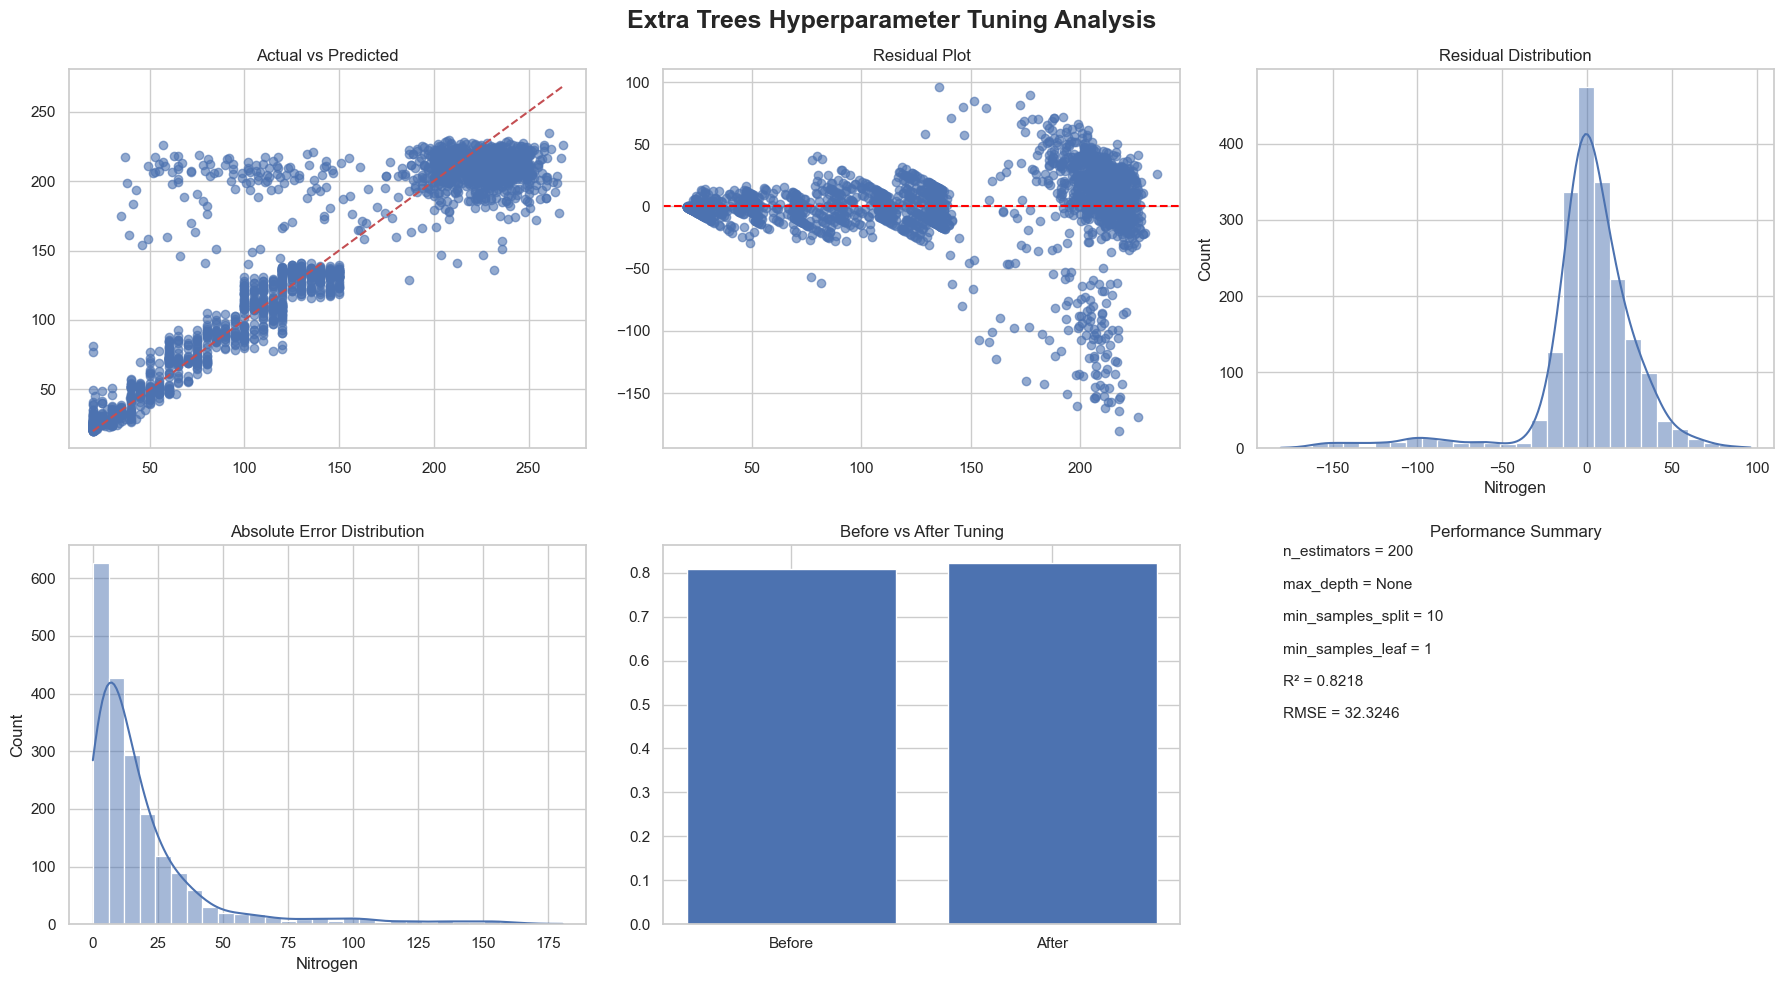

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

et_residuals = y_test - et_pred
et_abs_error = abs(et_residuals)

fig, axes = plt.subplots(2,3, figsize=(18,10))

# Actual vs Predicted
axes[0,0].scatter(y_test, et_pred, alpha=0.6)
axes[0,0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[0,0].set_title("Actual vs Predicted")

# Residual Plot
axes[0,1].scatter(et_pred, et_residuals, alpha=0.6)
axes[0,1].axhline(0,color='red',linestyle='--')
axes[0,1].set_title("Residual Plot")

# Residual Distribution
sns.histplot(et_residuals,bins=30,kde=True,ax=axes[0,2])
axes[0,2].set_title("Residual Distribution")

# Absolute Error Distribution
sns.histplot(et_abs_error,bins=30,kde=True,ax=axes[1,0])
axes[1,0].set_title("Absolute Error Distribution")

# Before vs After
axes[1,1].bar(
    ["Before","After"],
    [et_before["R2 Score"], et_r2]
)
axes[1,1].set_title("Before vs After Tuning")

# Summary
axes[1,2].axis('off')

axes[1,2].text(
    0.05,
    0.5,
    f"""
n_estimators = {et_search.best_params_['n_estimators']}

max_depth = {et_search.best_params_['max_depth']}

min_samples_split = {et_search.best_params_['min_samples_split']}

min_samples_leaf = {et_search.best_params_['min_samples_leaf']}

R² = {et_r2:.4f}

RMSE = {et_rmse:.4f}
""",
    fontsize=11
)

axes[1,2].set_title("Performance Summary")

plt.suptitle(
    "Extra Trees Hyperparameter Tuning Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Feature Importance Plot

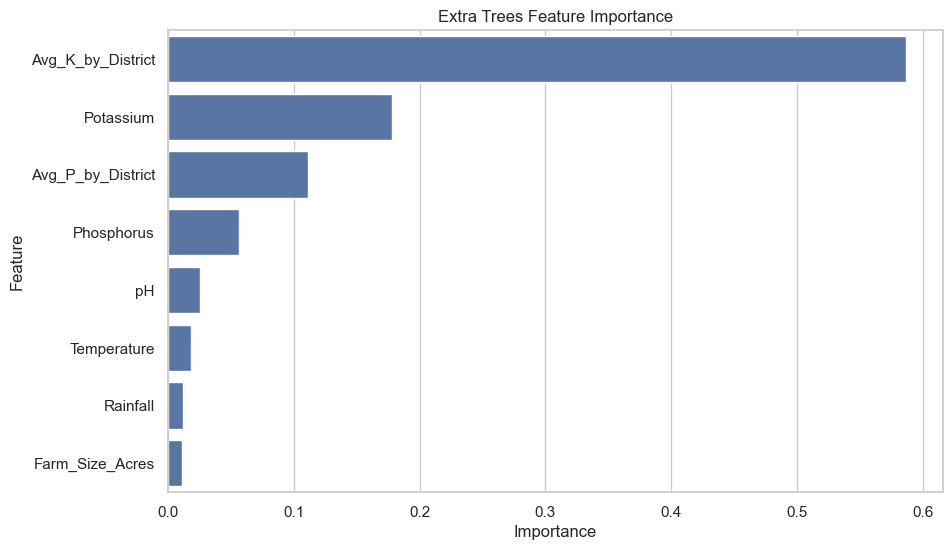

,Feature,Importance
7,Avg_K_by_District,0.586599
1,Potassium,0.178381
6,Avg_P_by_District,0.111332
0,Phosphorus,0.056591
2,pH,0.025037
4,Temperature,0.018430
3,Rainfall,0.012130
5,Farm_Size_Acres,0.011500


In [63]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_et.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Extra Trees Feature Importance")
plt.show()

importance_df.head(15)

## Tree based Model 3 : 

## Random Forest Hyperparameter Tuning

In [64]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib 

# Random Forest Model

rf = RandomForestRegressor(random_state=42)

# Hyperparameter Search Space

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Random Search

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=25,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

# Best Model

best_rf = rf_search.best_estimator_

# Predictions

rf_pred = best_rf.predict(X_test)

# Metrics

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Best Parameters:", rf_search.best_params_)
print("MAE:", round(rf_mae,4))
print("MSE:", round(rf_mse,4))
print("RMSE:", round(rf_rmse,4))
print("R2 Score:", round(rf_r2,4))


joblib.dump(best_rf, "random_forest_soil_model.pkl")

print("Random Forest model saved successfully!")

Best Parameters: {'n_estimators': 500, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}
MAE: 19.9676
MSE: 1086.9231
RMSE: 32.9685
R2 Score: 0.8146
Random Forest model saved successfully!


BEFORE BS AFTER TUNING

In [65]:
rf_before = baseline_results[
    baseline_results["Model"] == "Random Forest"
].iloc[0]

rf_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score",
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf"
    ],

    "Before Tuning": [
        rf_before["MAE"],
        rf_before["MSE"],
        rf_before["RMSE"],
        rf_before["R2 Score"],
        "-",
        "-",
        "-",
        "-"
    ],

    "After Tuning": [
        round(rf_mae,4),
        round(rf_mse,4),
        round(rf_rmse,4),
        round(rf_r2,4),
        rf_search.best_params_["n_estimators"],
        rf_search.best_params_["max_depth"],
        rf_search.best_params_["min_samples_split"],
        rf_search.best_params_["min_samples_leaf"]
    ]
})

rf_comparison

,Metric,Before Tuning,After Tuning
0,MAE,20.5156,19.9676
1,MSE,1104.3298,1086.9231
2,RMSE,33.2315,32.9685
3,R² Score,0.8117,0.8146
4,n_estimators,-,500.0000
5,max_depth,-,20.0000
6,min_samples_split,-,5.0000
7,min_samples_leaf,-,2.0000


## Random Forest Feature Importance Plot

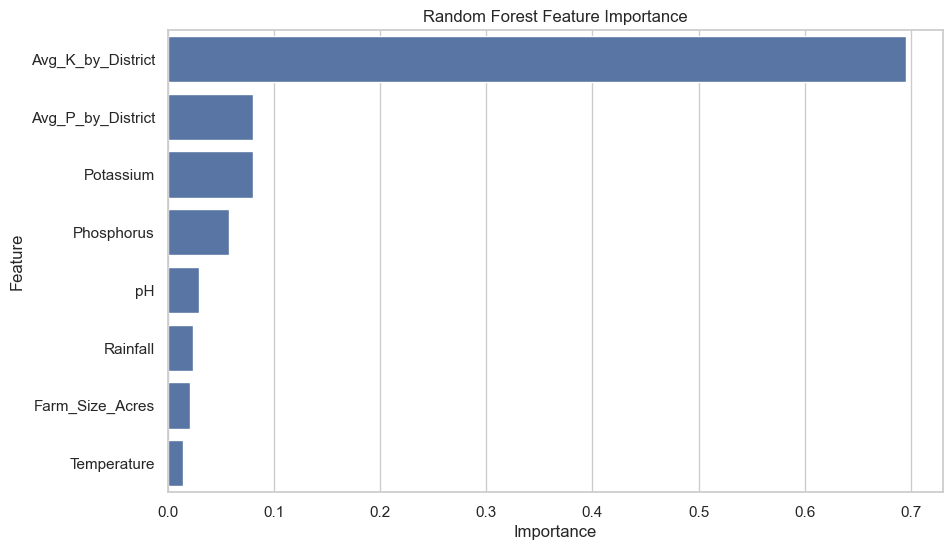

,Feature,Importance
7,Avg_K_by_District,0.695565
6,Avg_P_by_District,0.080134
1,Potassium,0.079650
0,Phosphorus,0.057026
2,pH,0.028812
3,Rainfall,0.023334
5,Farm_Size_Acres,0.021001
4,Temperature,0.014478


In [66]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.show()

importance_df.head(15)

## Boosting Model 1 :

## Gradient Boosting Regressor Hyperparameter Tuning

In [67]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Gradient Boosting Model

gb = GradientBoostingRegressor(random_state=42)

# Hyperparameter Search Space

gb_params = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 0.9, 1.0]
}

# Random Search

gb_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=gb_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

# Best Model

best_gb = gb_search.best_estimator_

# Predictions

gb_pred = best_gb.predict(X_test)

# Metrics

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)
gb_r2 = r2_score(y_test, gb_pred)

print("Best Parameters:", gb_search.best_params_)
print("MAE:", round(gb_mae,4))
print("MSE:", round(gb_mse,4))
print("RMSE:", round(gb_rmse,4))
print("R2 Score:", round(gb_r2,4))

Best Parameters: {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05}
MAE: 21.0505
MSE: 1135.2309
RMSE: 33.6932
R2 Score: 0.8064


BEFORE VS AFTER

In [68]:
gb_before = baseline_results[
    baseline_results["Model"] == "Gradient Boosting"
].iloc[0]

gb_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score",
        "n_estimators",
        "learning_rate",
        "max_depth",
        "subsample"
    ],

    "Before Tuning": [
        gb_before["MAE"],
        gb_before["MSE"],
        gb_before["RMSE"],
        gb_before["R2 Score"],
        "-",
        "-",
        "-",
        "-"
    ],

    "After Tuning": [
        round(gb_mae,4),
        round(gb_mse,4),
        round(gb_rmse,4),
        round(gb_r2,4),
        gb_search.best_params_["n_estimators"],
        gb_search.best_params_["learning_rate"],
        gb_search.best_params_["max_depth"],
        gb_search.best_params_["subsample"]
    ]
})

gb_comparison

,Metric,Before Tuning,After Tuning
0,MAE,21.8386,21.0505
1,MSE,1182.6061,1135.2309
2,RMSE,34.389,33.6932
3,R² Score,0.7983,0.8064
4,n_estimators,-,100.0000
5,learning_rate,-,0.0500
6,max_depth,-,7.0000
7,subsample,-,0.7000


Visualization

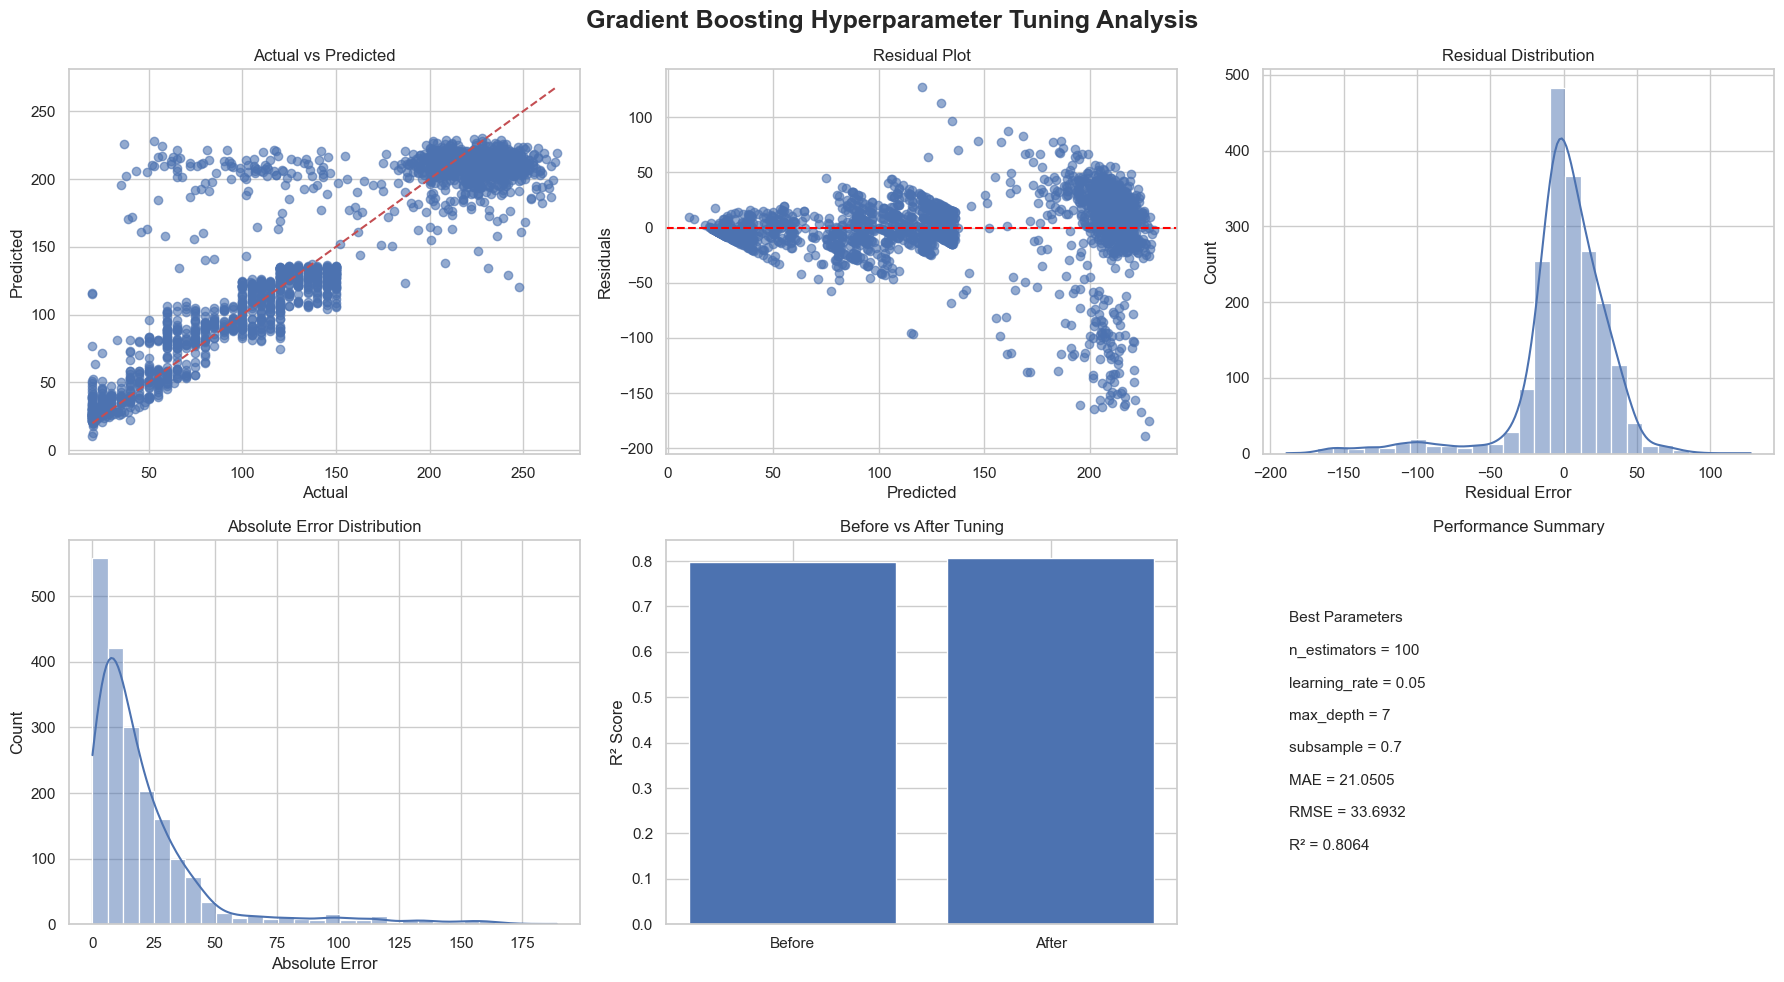

In [69]:
# Gradient Boosting - Complete Visualization Dashboard

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Residuals
gb_residuals = y_test - gb_pred

# Absolute Error
gb_abs_error = abs(gb_residuals)

# Create Dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, gb_pred, alpha=0.6)
axes[0, 0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[0, 0].set_title("Actual vs Predicted")
axes[0, 0].set_xlabel("Actual")
axes[0, 0].set_ylabel("Predicted")

# 2. Residual Plot
axes[0, 1].scatter(gb_pred, gb_residuals, alpha=0.6)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title("Residual Plot")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Residuals")

# 3. Residual Distribution
sns.histplot(gb_residuals, bins=30, kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Residual Distribution")
axes[0, 2].set_xlabel("Residual Error")

# 4. Absolute Error Distribution
sns.histplot(gb_abs_error, bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Absolute Error Distribution")
axes[1, 0].set_xlabel("Absolute Error")

# 5. Before vs After R²
axes[1, 1].bar(
    ["Before", "After"],
    [gb_before["R2 Score"], gb_r2]
)
axes[1, 1].set_ylabel("R² Score")
axes[1, 1].set_title("Before vs After Tuning")

# 6. Metrics Summary
axes[1, 2].axis("off")

summary_text = f"""
Best Parameters

n_estimators = {gb_search.best_params_['n_estimators']}

learning_rate = {gb_search.best_params_['learning_rate']}

max_depth = {gb_search.best_params_['max_depth']}

subsample = {gb_search.best_params_['subsample']}

MAE = {gb_mae:.4f}

RMSE = {gb_rmse:.4f}

R² = {gb_r2:.4f}
"""

axes[1, 2].text(
    0.05,
    0.5,
    summary_text,
    fontsize=11,
    verticalalignment="center"
)

axes[1, 2].set_title("Performance Summary")

plt.suptitle(
    "Gradient Boosting Hyperparameter Tuning Analysis",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

Feature Importance Plot

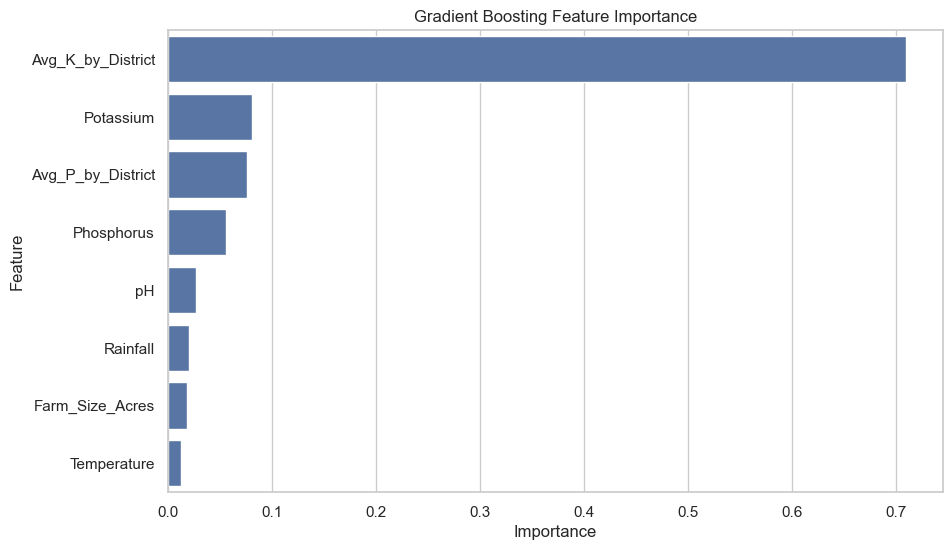

In [70]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_gb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Gradient Boosting Feature Importance")
plt.show()

## Boosting Model 2 : 

## AdaBoost Regressor Hyperparameter Tuning

In [71]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# AdaBoost Model
ada = AdaBoostRegressor(random_state=42)

# Hyperparameter Search Space
ada_params = {
    "n_estimators": [50, 100, 200, 300, 500],
    "learning_rate": [0.001, 0.01, 0.05, 0.1, 0.5, 1.0],
    "loss": ["linear", "square", "exponential"]
}

# Randomized Search
ada_search = RandomizedSearchCV(
    estimator=ada,
    param_distributions=ada_params,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

ada_search.fit(X_train, y_train)

# Best Model
best_ada = ada_search.best_estimator_

# Predictions
ada_pred = best_ada.predict(X_test)

# Metrics
ada_mae = mean_absolute_error(y_test, ada_pred)
ada_mse = mean_squared_error(y_test, ada_pred)
ada_rmse = np.sqrt(ada_mse)
ada_r2 = r2_score(y_test, ada_pred)

print("Best Parameters:", ada_search.best_params_)
print("MAE:", round(ada_mae, 4))
print("MSE:", round(ada_mse, 4))
print("RMSE:", round(ada_rmse, 4))
print("R2 Score:", round(ada_r2, 4))

Best Parameters: {'n_estimators': 500, 'loss': 'linear', 'learning_rate': 0.001}
MAE: 26.9912
MSE: 1469.9223
RMSE: 38.3396
R2 Score: 0.7493


BEFORE VS AFTER TUNING

In [72]:
ada_before = baseline_results[
    baseline_results["Model"] == "AdaBoost"
].iloc[0]

ada_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score",
        "n_estimators",
        "learning_rate",
        "loss"
    ],

    "Before Tuning": [
        ada_before["MAE"],
        ada_before["MSE"],
        ada_before["RMSE"],
        ada_before["R2 Score"],
        "-",
        "-",
        "-"
    ],

    "After Tuning": [
        round(ada_mae,4),
        round(ada_mse,4),
        round(ada_rmse,4),
        round(ada_r2,4),
        ada_search.best_params_["n_estimators"],
        ada_search.best_params_["learning_rate"],
        ada_search.best_params_["loss"]
    ]
})

ada_comparison

,Metric,Before Tuning,After Tuning
0,MAE,30.2938,26.9912
1,MSE,1560.6405,1469.9223
2,RMSE,39.5049,38.3396
3,R² Score,0.7339,0.7493
4,n_estimators,-,500
5,learning_rate,-,0.001
6,loss,-,linear


Visualization

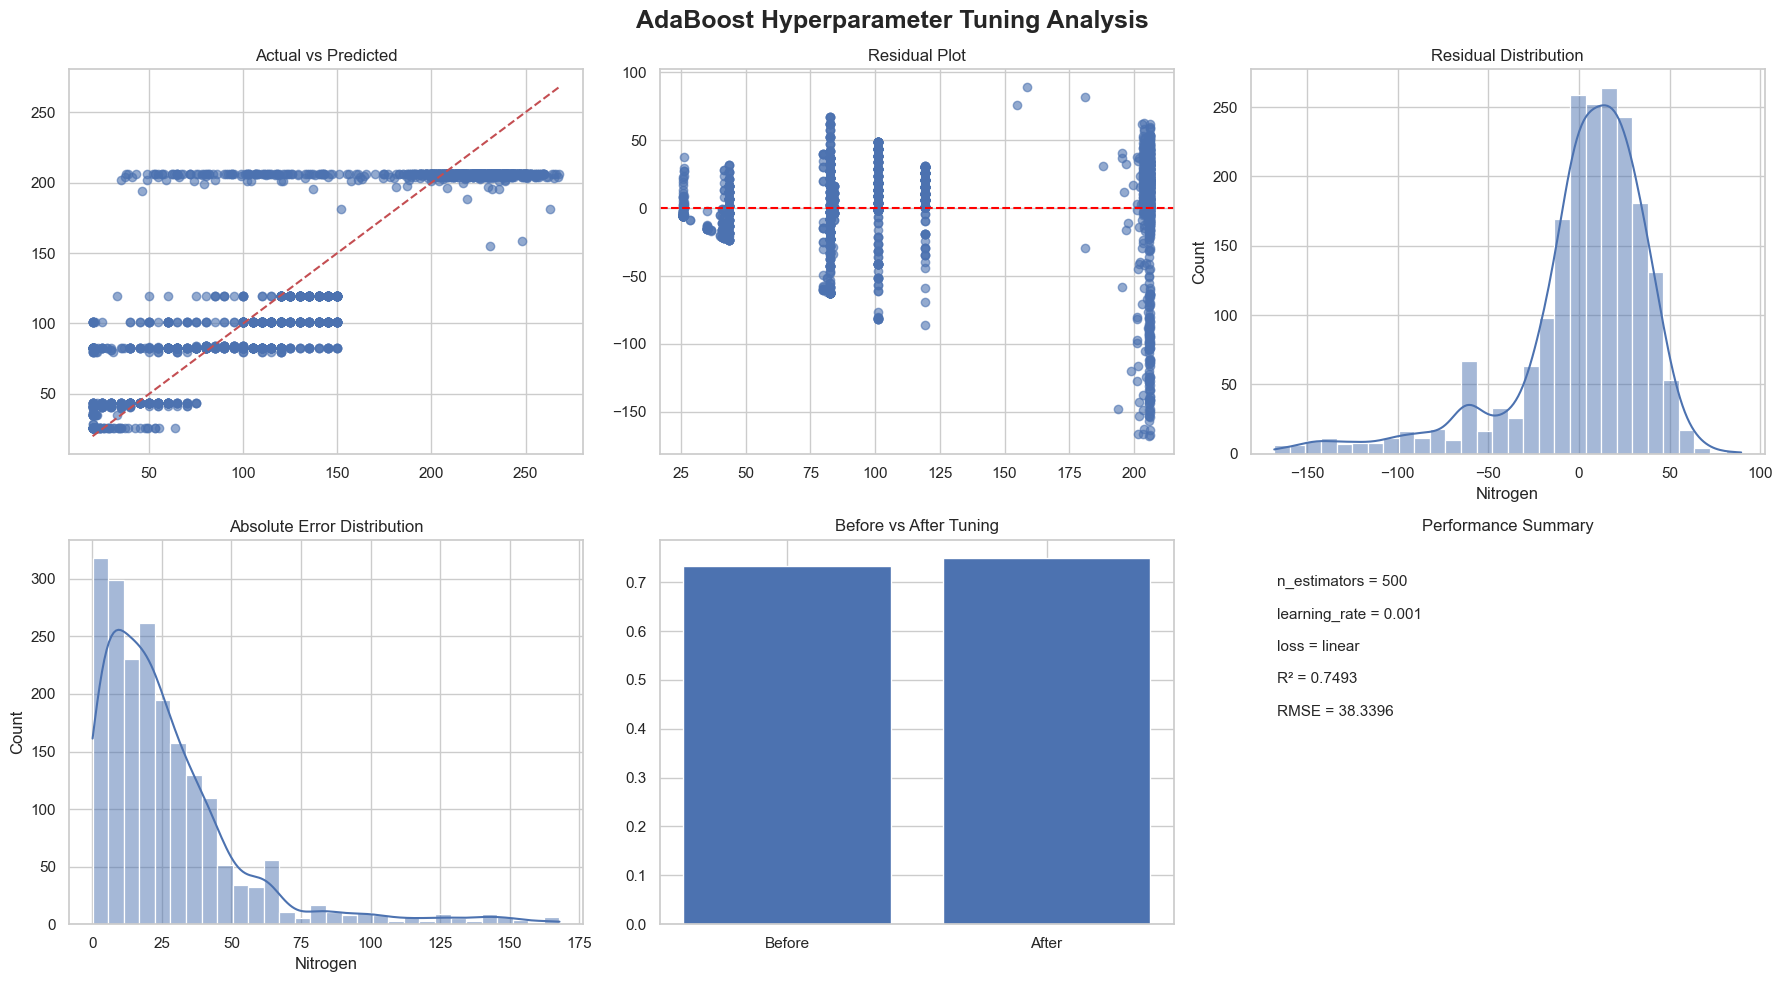

In [73]:
# AdaBoost Complete Dashboard

import matplotlib.pyplot as plt
import seaborn as sns

ada_residuals = y_test - ada_pred
ada_abs_error = abs(ada_residuals)

fig, axes = plt.subplots(2,3, figsize=(18,10))

# Actual vs Predicted
axes[0,0].scatter(y_test, ada_pred, alpha=0.6)
axes[0,0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[0,0].set_title("Actual vs Predicted")

# Residual Plot
axes[0,1].scatter(ada_pred, ada_residuals, alpha=0.6)
axes[0,1].axhline(0,color='red',linestyle='--')
axes[0,1].set_title("Residual Plot")

# Residual Distribution
sns.histplot(ada_residuals,bins=30,kde=True,ax=axes[0,2])
axes[0,2].set_title("Residual Distribution")

# Absolute Error Distribution
sns.histplot(ada_abs_error,bins=30,kde=True,ax=axes[1,0])
axes[1,0].set_title("Absolute Error Distribution")

# Before vs After
axes[1,1].bar(
    ["Before","After"],
    [ada_before["R2 Score"], ada_r2]
)
axes[1,1].set_title("Before vs After Tuning")

# Summary
axes[1,2].axis('off')

axes[1,2].text(
    0.05,
    0.5,
    f"""
n_estimators = {ada_search.best_params_['n_estimators']}

learning_rate = {ada_search.best_params_['learning_rate']}

loss = {ada_search.best_params_['loss']}

R² = {ada_r2:.4f}

RMSE = {ada_rmse:.4f}
""",
    fontsize=11
)

axes[1,2].set_title("Performance Summary")

plt.suptitle(
    "AdaBoost Hyperparameter Tuning Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Boosting Model : 3

## XGBoost Hyperparameter Tuning

In [74]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import joblib

# XGBoost Model

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    verbosity=0
)

# Hyperparameter Search Space

xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

# Random Search

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=25,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

# Best Model

best_xgb = xgb_search.best_estimator_

# Predictions

xgb_pred = best_xgb.predict(X_test)

# Metrics

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_pred)

print("Best Parameters:", xgb_search.best_params_)
print("MAE:", round(xgb_mae,4))
print("MSE:", round(xgb_mse,4))
print("RMSE:", round(xgb_rmse,4))
print("R2 Score:", round(xgb_r2,4))

#saving 

joblib.dump(best_xgb, "xgboost_soil_model.pkl")

Best Parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
MAE: 21.6819
MSE: 1118.5683
RMSE: 33.445
R2 Score: 0.8093


['xgboost_soil_model.pkl']

BEFORE VS AFTER TUNING

In [75]:
xgb_before = baseline_results[
    baseline_results["Model"] == "XGBoost"
].iloc[0]

xgb_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score",
        "n_estimators",
        "max_depth",
        "learning_rate",
        "subsample",
        "colsample_bytree"
    ],

    "Before Tuning": [
        xgb_before["MAE"],
        xgb_before["MSE"],
        xgb_before["RMSE"],
        xgb_before["R2 Score"],
        "-",
        "-",
        "-",
        "-",
        "-"
    ],

    "After Tuning": [
        round(xgb_mae,4),
        round(xgb_mse,4),
        round(xgb_rmse,4),
        round(xgb_r2,4),
        xgb_search.best_params_["n_estimators"],
        xgb_search.best_params_["max_depth"],
        xgb_search.best_params_["learning_rate"],
        xgb_search.best_params_["subsample"],
        xgb_search.best_params_["colsample_bytree"]
    ]
})

xgb_comparison

,Metric,Before Tuning,After Tuning
0,MAE,21.7879,21.6819
1,MSE,1165.4552,1118.5683
2,RMSE,34.1388,33.4450
3,R² Score,0.8013,0.8093
4,n_estimators,-,300.0000
5,max_depth,-,10.0000
6,learning_rate,-,0.0100
7,subsample,-,0.7000
8,colsample_bytree,-,0.8000


Visualization

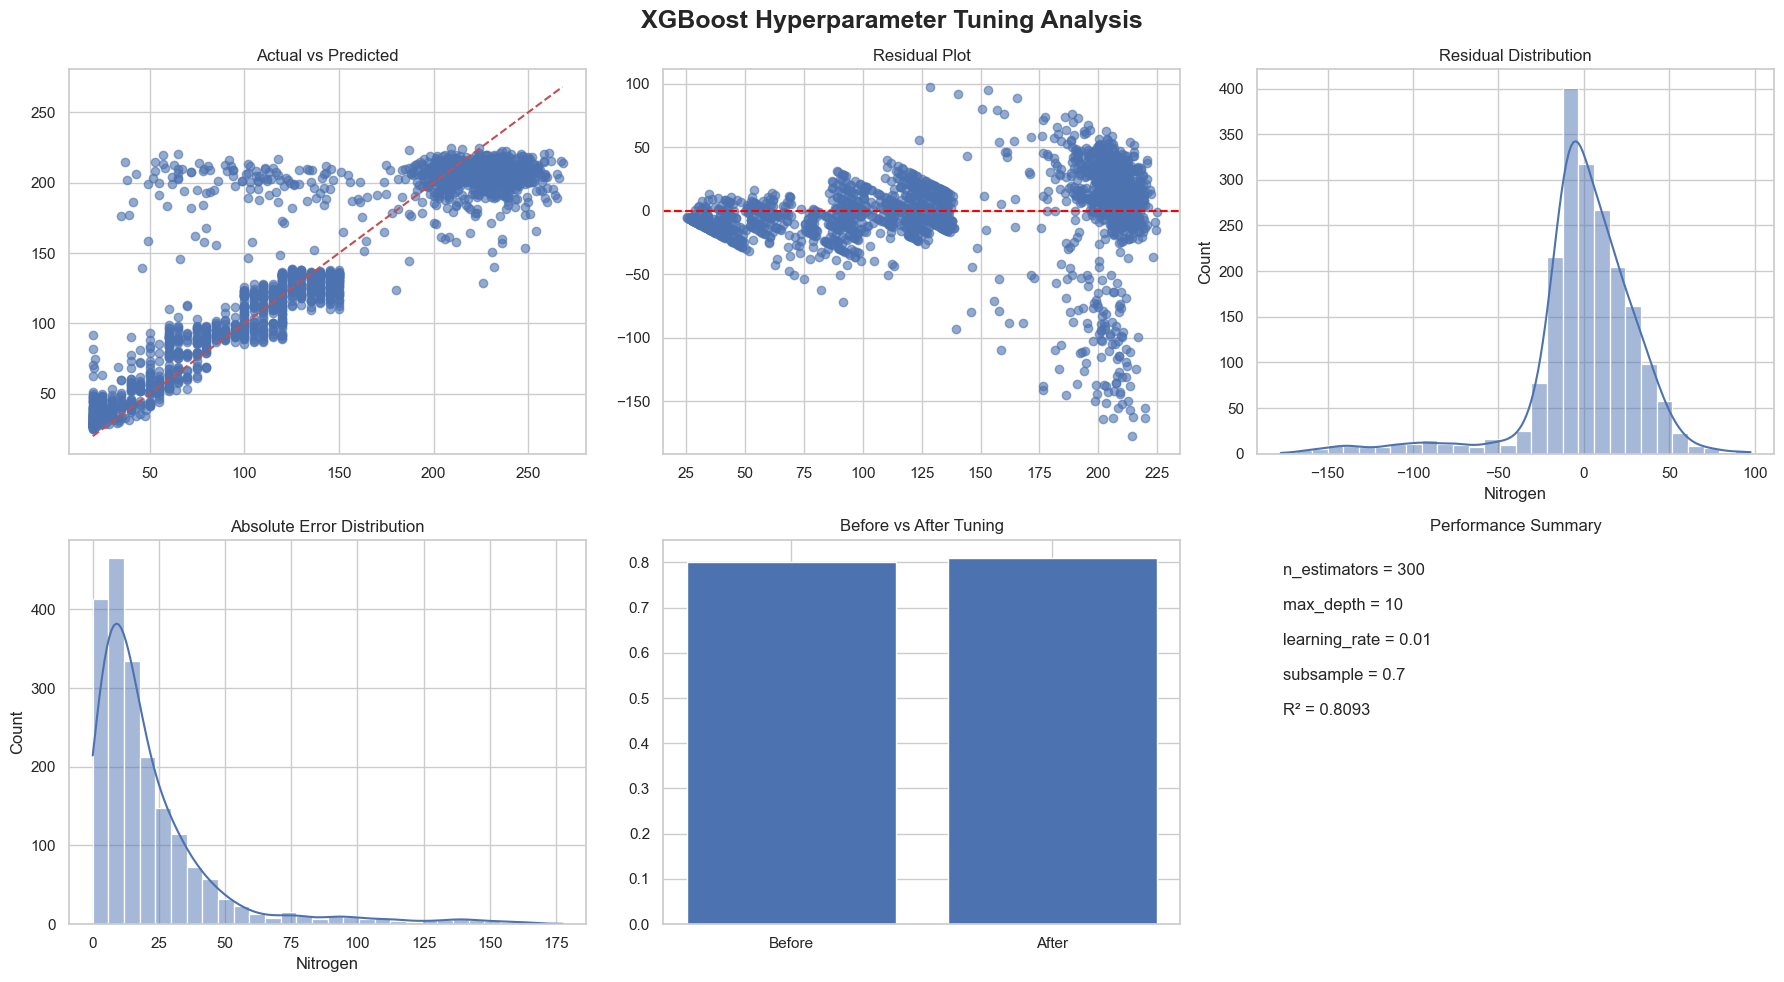

In [76]:
# XGBoost Complete Dashboard

import matplotlib.pyplot as plt
import seaborn as sns

xgb_residuals = y_test - xgb_pred
xgb_abs_error = abs(xgb_residuals)

fig, axes = plt.subplots(2,3, figsize=(18,10))

# Actual vs Predicted
axes[0,0].scatter(y_test, xgb_pred, alpha=0.6)
axes[0,0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[0,0].set_title("Actual vs Predicted")

# Residual Plot
axes[0,1].scatter(xgb_pred, xgb_residuals, alpha=0.6)
axes[0,1].axhline(0,color='red',linestyle='--')
axes[0,1].set_title("Residual Plot")

# Residual Distribution
sns.histplot(xgb_residuals,bins=30,kde=True,ax=axes[0,2])
axes[0,2].set_title("Residual Distribution")

# Absolute Error Distribution
sns.histplot(xgb_abs_error,bins=30,kde=True,ax=axes[1,0])
axes[1,0].set_title("Absolute Error Distribution")

# Before vs After
axes[1,1].bar(
    ["Before","After"],
    [xgb_before["R2 Score"], xgb_r2]
)
axes[1,1].set_title("Before vs After Tuning")

# Summary
axes[1,2].axis('off')

axes[1,2].text(
    0.05,
    0.5,
    f"""
n_estimators = {xgb_search.best_params_['n_estimators']}

max_depth = {xgb_search.best_params_['max_depth']}

learning_rate = {xgb_search.best_params_['learning_rate']}

subsample = {xgb_search.best_params_['subsample']}

R² = {xgb_r2:.4f}
"""
)

axes[1,2].set_title("Performance Summary")

plt.suptitle(
    "XGBoost Hyperparameter Tuning Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Feature importance plot

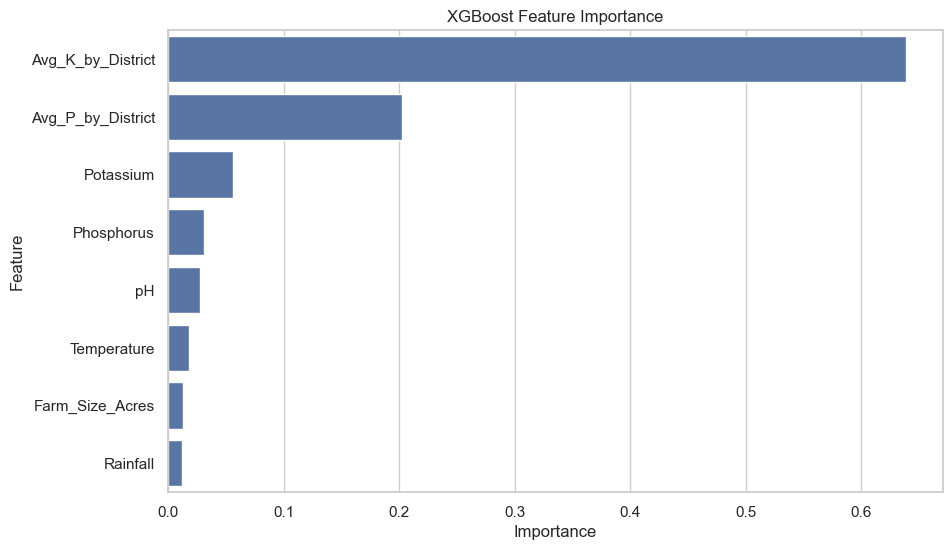

In [77]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")
plt.show()

## Shap Summary Plot

In [78]:
explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

NameError: name 'shap' is not defined

## Boosting Model 4 :

## LightGBM Hyperparameter Tuning

In [80]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# LightGBM Model
lgbm = LGBMRegressor(
    random_state=42,
    verbose=-1
)

# Hyperparameter Search Space
lgbm_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "num_leaves": [15, 31, 50, 100],
    "max_depth": [-1, 5, 10, 20],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

# Randomized Search
lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_params,
    n_iter=25,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)

# Best Model
best_lgbm = lgbm_search.best_estimator_

# Predictions
lgbm_pred = best_lgbm.predict(X_test)

# Metrics
lgbm_mae = mean_absolute_error(y_test, lgbm_pred)
lgbm_mse = mean_squared_error(y_test, lgbm_pred)
lgbm_rmse = np.sqrt(lgbm_mse)
lgbm_r2 = r2_score(y_test, lgbm_pred)

print("Best Parameters:", lgbm_search.best_params_)
print("MAE:", round(lgbm_mae, 4))
print("MSE:", round(lgbm_mse, 4))
print("RMSE:", round(lgbm_rmse, 4))
print("R2 Score:", round(lgbm_r2, 4))

Best Parameters: {'subsample': 0.9, 'num_leaves': 50, 'n_estimators': 100, 'max_depth': 20, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
MAE: 21.2943
MSE: 1134.6056
RMSE: 33.6839
R2 Score: 0.8065


BEFORE VS AFTER TUNING

In [81]:
lgbm_before = baseline_results[
    baseline_results["Model"] == "LightGBM"
].iloc[0]

lgbm_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score",
        "n_estimators",
        "learning_rate",
        "num_leaves",
        "max_depth",
        "subsample",
        "colsample_bytree"
    ],

    "Before Tuning": [
        lgbm_before["MAE"],
        lgbm_before["MSE"],
        lgbm_before["RMSE"],
        lgbm_before["R2 Score"],
        "-", "-", "-", "-", "-", "-"
    ],

    "After Tuning": [
        round(lgbm_mae,4),
        round(lgbm_mse,4),
        round(lgbm_rmse,4),
        round(lgbm_r2,4),
        lgbm_search.best_params_["n_estimators"],
        lgbm_search.best_params_["learning_rate"],
        lgbm_search.best_params_["num_leaves"],
        lgbm_search.best_params_["max_depth"],
        lgbm_search.best_params_["subsample"],
        lgbm_search.best_params_["colsample_bytree"]
    ]
})

lgbm_comparison

,Metric,Before Tuning,After Tuning
0,MAE,21.6405,21.2943
1,MSE,1150.8757,1134.6056
2,RMSE,33.9246,33.6839
3,R² Score,0.8037,0.8065
4,n_estimators,-,100.0000
5,learning_rate,-,0.0500
6,num_leaves,-,50.0000
7,max_depth,-,20.0000
8,subsample,-,0.9000
9,colsample_bytree,-,0.8000


Visualization

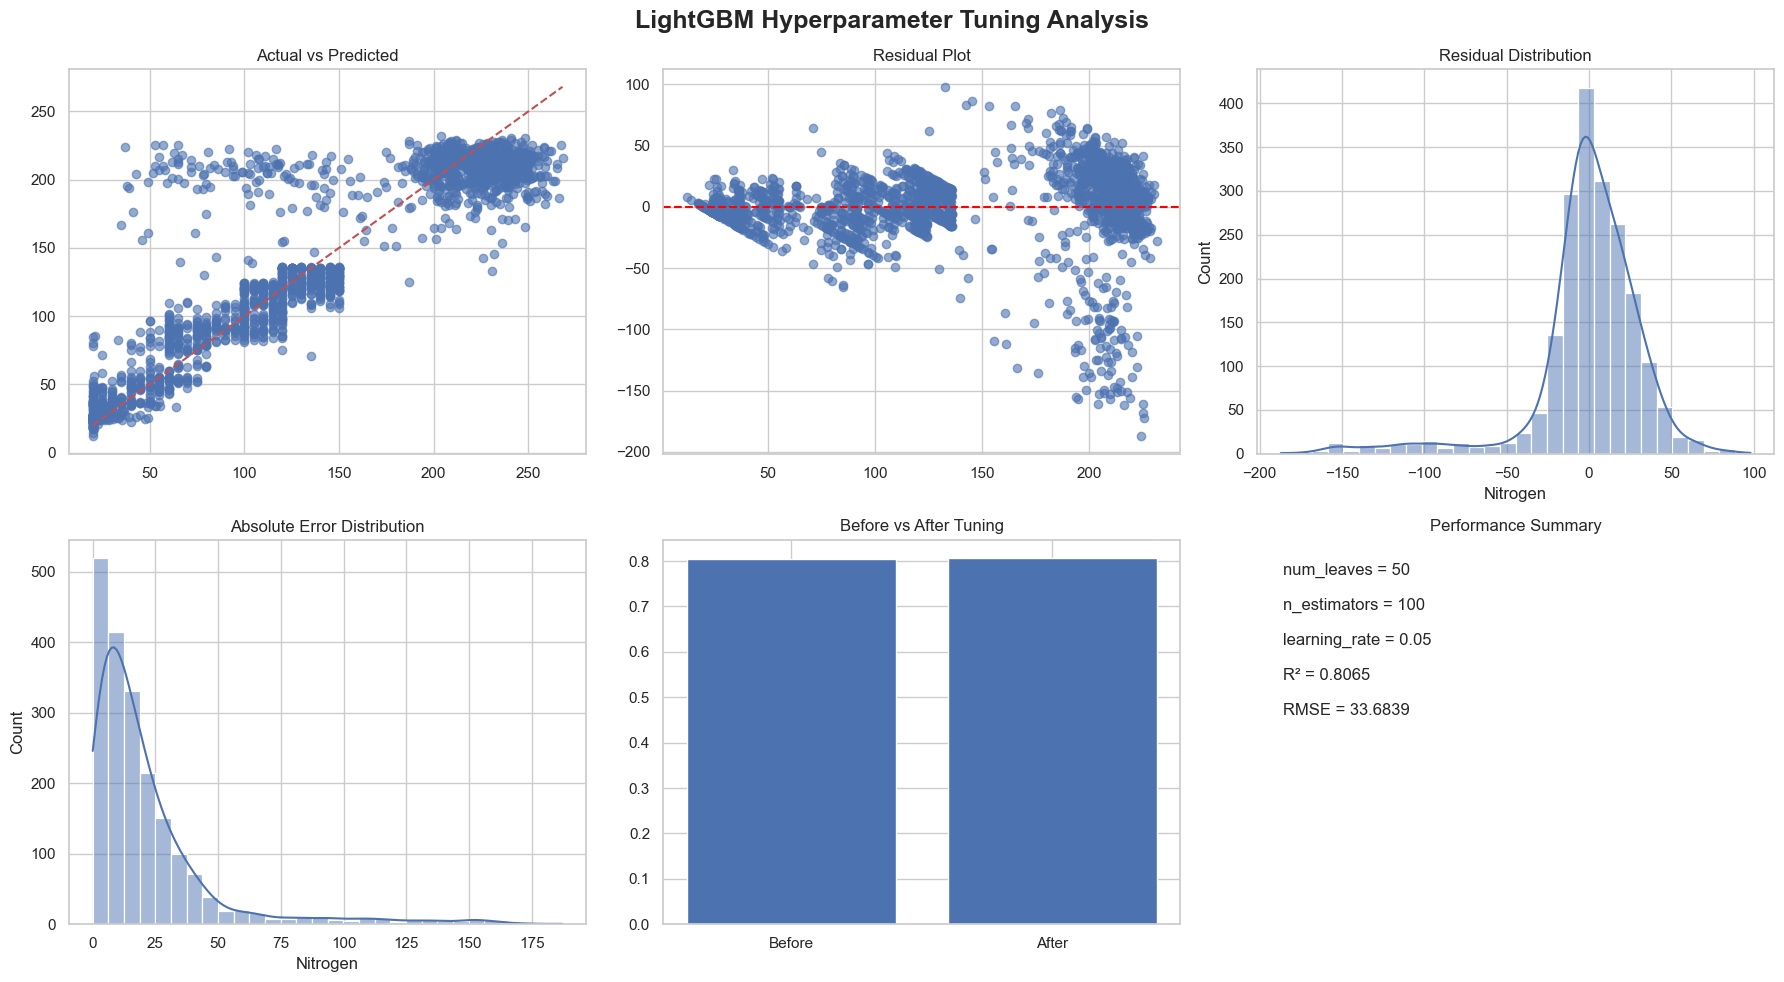

In [82]:
# LightGBM Complete Dashboard

import matplotlib.pyplot as plt
import seaborn as sns

lgbm_residuals = y_test - lgbm_pred
lgbm_abs_error = abs(lgbm_residuals)

fig, axes = plt.subplots(2,3, figsize=(18,10))

# Actual vs Predicted
axes[0,0].scatter(y_test, lgbm_pred, alpha=0.6)
axes[0,0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[0,0].set_title("Actual vs Predicted")

# Residual Plot
axes[0,1].scatter(lgbm_pred, lgbm_residuals, alpha=0.6)
axes[0,1].axhline(0,color='red',linestyle='--')
axes[0,1].set_title("Residual Plot")

# Residual Distribution
sns.histplot(lgbm_residuals,bins=30,kde=True,ax=axes[0,2])
axes[0,2].set_title("Residual Distribution")

# Absolute Error Distribution
sns.histplot(lgbm_abs_error,bins=30,kde=True,ax=axes[1,0])
axes[1,0].set_title("Absolute Error Distribution")

# Before vs After
axes[1,1].bar(
    ["Before","After"],
    [lgbm_before["R2 Score"], lgbm_r2]
)
axes[1,1].set_title("Before vs After Tuning")

# Summary
axes[1,2].axis('off')

axes[1,2].text(
    0.05,
    0.5,
    f"""
num_leaves = {lgbm_search.best_params_['num_leaves']}

n_estimators = {lgbm_search.best_params_['n_estimators']}

learning_rate = {lgbm_search.best_params_['learning_rate']}

R² = {lgbm_r2:.4f}

RMSE = {lgbm_rmse:.4f}
"""
)

axes[1,2].set_title("Performance Summary")

plt.suptitle(
    "LightGBM Hyperparameter Tuning Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

LightGBM Feature Importance

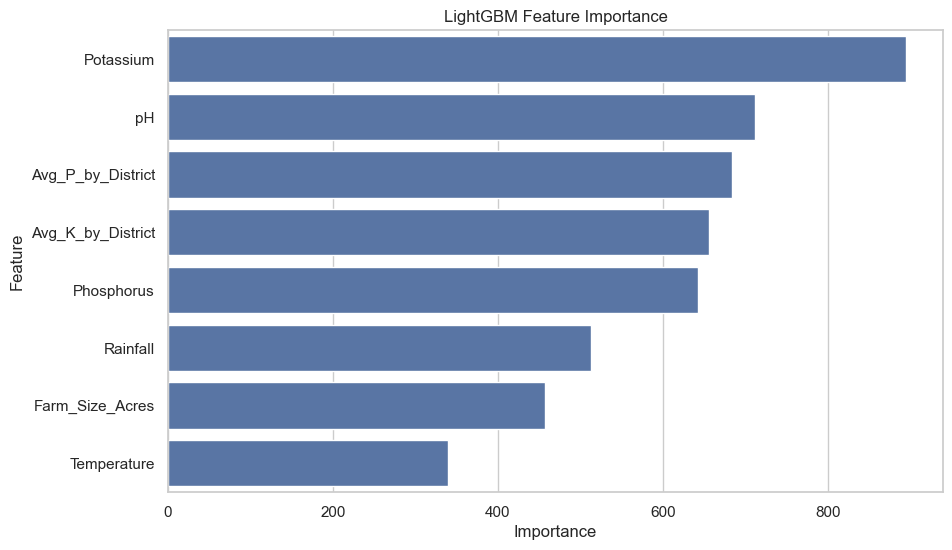

In [83]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_lgbm.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("LightGBM Feature Importance")
plt.show()

## Boosting Model 5 : 

## CatBoost Hyperparameter Tuning

In [84]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# CatBoost Model

cat = CatBoostRegressor(
    random_state=42,
    verbose=0
)

# Hyperparameter Search Space

cat_params = {
    'iterations': [100, 200, 300, 500, 1000],
    'depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

# Random Search

cat_search = RandomizedSearchCV(
    estimator=cat,
    param_distributions=cat_params,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

cat_search.fit(X_train, y_train)

# Best Model

best_cat = cat_search.best_estimator_

# Predictions

cat_pred = best_cat.predict(X_test)

# Metrics

cat_mae = mean_absolute_error(y_test, cat_pred)
cat_mse = mean_squared_error(y_test, cat_pred)
cat_rmse = np.sqrt(cat_mse)
cat_r2 = r2_score(y_test, cat_pred)

print("Best Parameters:", cat_search.best_params_)
print("MAE:", round(cat_mae,4))
print("MSE:", round(cat_mse,4))
print("RMSE:", round(cat_rmse,4))
print("R2 Score:", round(cat_r2,4))

Best Parameters: {'learning_rate': 0.01, 'l2_leaf_reg': 1, 'iterations': 1000, 'depth': 8}
MAE: 21.8035
MSE: 1137.5767
RMSE: 33.728
R2 Score: 0.806


BEFORE VS AFTER TUNING

In [85]:
cat_before = baseline_results[
    baseline_results["Model"] == "CatBoost"
].iloc[0]

cat_comparison = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score",
        "iterations",
        "depth",
        "learning_rate",
        "l2_leaf_reg"
    ],

    "Before Tuning": [
        cat_before["MAE"],
        cat_before["MSE"],
        cat_before["RMSE"],
        cat_before["R2 Score"],
        "-", "-", "-", "-"
    ],

    "After Tuning": [
        round(cat_mae,4),
        round(cat_mse,4),
        round(cat_rmse,4),
        round(cat_r2,4),
        cat_search.best_params_["iterations"],
        cat_search.best_params_["depth"],
        cat_search.best_params_["learning_rate"],
        cat_search.best_params_["l2_leaf_reg"]
    ]
})

cat_comparison

,Metric,Before Tuning,After Tuning
0,MAE,22.7996,21.8035
1,MSE,1191.6899,1137.5767
2,RMSE,34.5209,33.7280
3,R² Score,0.7968,0.8060
4,iterations,-,1000.0000
5,depth,-,8.0000
6,learning_rate,-,0.0100
7,l2_leaf_reg,-,1.0000


Visualization

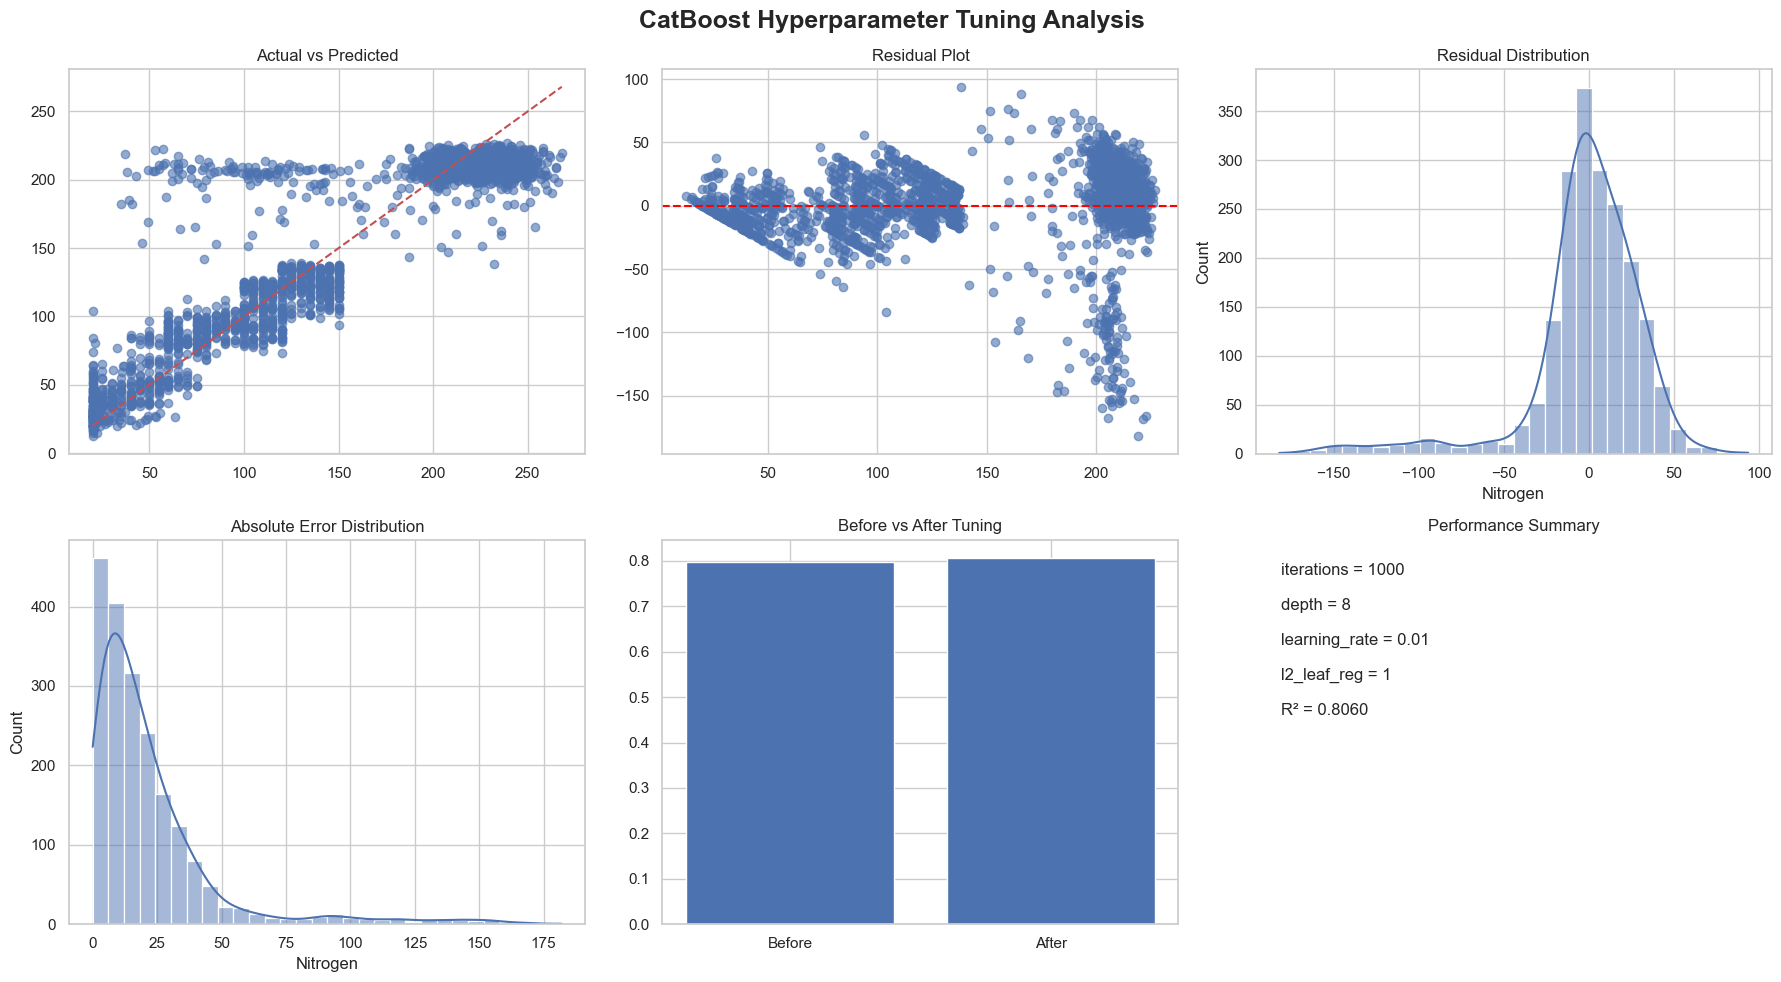

In [86]:
# CatBoost Complete Dashboard

import matplotlib.pyplot as plt
import seaborn as sns

cat_residuals = y_test - cat_pred
cat_abs_error = abs(cat_residuals)

fig, axes = plt.subplots(2,3, figsize=(18,10))

# Actual vs Predicted
axes[0,0].scatter(y_test, cat_pred, alpha=0.6)
axes[0,0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[0,0].set_title("Actual vs Predicted")

# Residual Plot
axes[0,1].scatter(cat_pred, cat_residuals, alpha=0.6)
axes[0,1].axhline(0,color='red',linestyle='--')
axes[0,1].set_title("Residual Plot")

# Residual Distribution
sns.histplot(cat_residuals,bins=30,kde=True,ax=axes[0,2])
axes[0,2].set_title("Residual Distribution")

# Absolute Error Distribution
sns.histplot(cat_abs_error,bins=30,kde=True,ax=axes[1,0])
axes[1,0].set_title("Absolute Error Distribution")

# Before vs After
axes[1,1].bar(
    ["Before","After"],
    [cat_before["R2 Score"], cat_r2]
)
axes[1,1].set_title("Before vs After Tuning")

# Summary
axes[1,2].axis('off')

axes[1,2].text(
    0.05,
    0.5,
    f"""
iterations = {cat_search.best_params_['iterations']}

depth = {cat_search.best_params_['depth']}

learning_rate = {cat_search.best_params_['learning_rate']}

l2_leaf_reg = {cat_search.best_params_['l2_leaf_reg']}

R² = {cat_r2:.4f}
"""
)

axes[1,2].set_title("Performance Summary")

plt.suptitle(
    "CatBoost Hyperparameter Tuning Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Final Phase 4 LeaderBoard

In [87]:
final_leaderboard = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Extra Trees",
        "Random Forest",
        "Gradient Boosting",
        "AdaBoost",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Tuned_R2": [
        ridge_r2,
        lasso_r2,
        dt_r2,
        et_r2,
        rf_r2,
        gb_r2,
        ada_r2,
        xgb_r2,
        lgbm_r2,
        cat_r2
    ]
})

final_leaderboard = final_leaderboard.sort_values(
    by="Tuned_R2",
    ascending=False
)

final_leaderboard.reset_index(drop=True, inplace=True)

final_leaderboard

,Model,Tuned_R2
0,Extra Trees,0.821818
1,Random Forest,0.814648
2,XGBoost,0.809251
3,LightGBM,0.806517
4,Gradient Boosting,0.806410
5,CatBoost,0.806010
6,Decision Tree,0.792519
7,AdaBoost,0.749335
8,Lasso Regression,0.701565
9,Ridge Regression,0.701563


## Final LeaderBoard Visualization

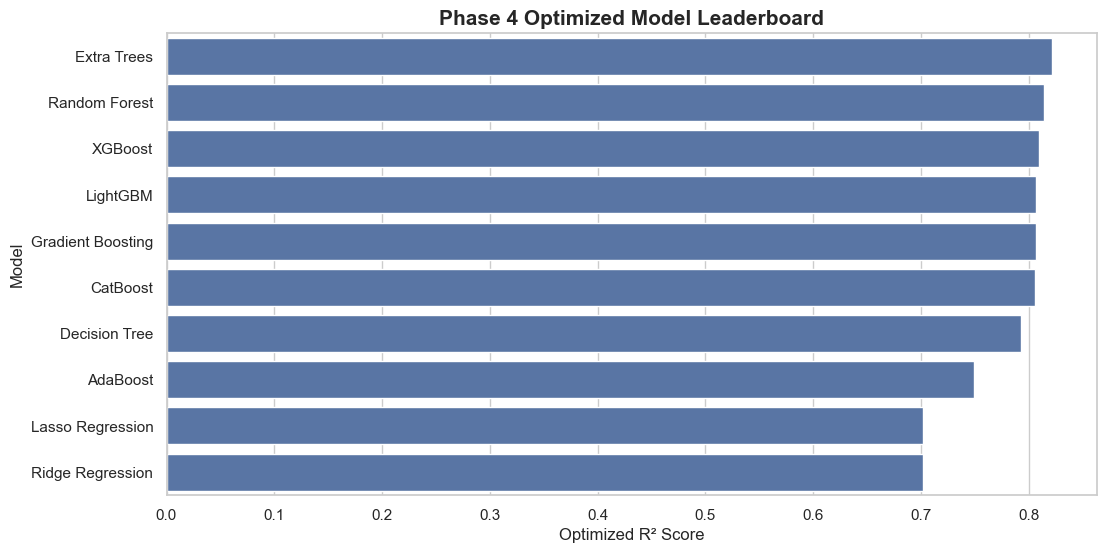

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=final_leaderboard,
    x="Tuned_R2",
    y="Model"
)

plt.title(
    "Phase 4 Optimized Model Leaderboard",
    fontsize=15,
    fontweight='bold'
)

plt.xlabel("Optimized R² Score")
plt.ylabel("Model")

plt.show()


## Ablation Study

While hyperparameter optimization improves model performance, it does not explain which engineered features are primarily responsible for the observed improvements. Therefore, an ablation study was conducted to systematically evaluate the contribution of each feature group introduced during the feature engineering phase.

The objective of the ablation study is to quantify the importance of the engineered features by progressively removing specific feature groups and measuring the resulting change in predictive performance. This approach helps determine whether the performance gains achieved by the optimized models originate from the learning algorithm itself or from the domain-specific features designed during data engineering.

For this study, the best-performing optimized model identified in Phase 4 was selected as the reference architecture. Feature groups such as nutrient ratio features, nutrient percentage features, fertility indicators, district-level aggregation features, PCA-derived components, and clustering-based features were removed individually. The model was then retrained and evaluated using the same experimental setup and evaluation metrics employed throughout the project.

A significant reduction in model performance after removing a feature group indicates that the corresponding features provide valuable predictive information. Conversely, a minimal performance change suggests that the removed features contribute less to the final prediction process. Through this systematic analysis, the ablation study provides empirical evidence regarding the effectiveness of the engineered features and validates the design choices made during Phase 2 of the project.

The findings of this study offer deeper insights into feature relevance, model behavior, and the underlying factors driving soil nutrient depletion prediction performance, thereby strengthening the scientific validity and interpretability of the proposed framework.


Feature Names

In [ ]:
# Check all feature columns available for ablation study

print("Total number of features:", len(X.columns))

print("\nFeature Names:")
for col in X.columns:
    print(col)

Total number of features: 8

Feature Names:
Phosphorus
Potassium
pH
Rainfall
Temperature
Farm_Size_Acres
Avg_P_by_District
Avg_K_by_District


## Ablation Study using Best Tuned Model: Extra Trees   

In [ ]:
# Ablation Study using Best Tuned Model: Extra Trees

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Best model from Phase 4
best_ablation_model = best_et

# Define feature groups for ablation
ablation_groups = {
    "Full Feature Set": [],
    "Without Soil Nutrient Features": ["Phosphorus", "Potassium", "pH"],
    "Without Weather Features": ["Rainfall", "Temperature"],
    "Without Farm Size Feature": ["Farm_Size_Acres"],
    "Without District Aggregation Features": ["Avg_P_by_District", "Avg_K_by_District"]
}

ablation_results = []

for experiment_name, features_to_remove in ablation_groups.items():
    
    # Remove selected features
    X_ablation = X.drop(columns=features_to_remove, errors="ignore")
    
    # Train-test split
    X_train_ab, X_test_ab, y_train_ab, y_test_ab = train_test_split(
        X_ablation, y, test_size=0.2, random_state=42
    )
    
    # Use same optimized Extra Trees parameters
    model = ExtraTreesRegressor(
        n_estimators=et_search.best_params_["n_estimators"],
        max_depth=et_search.best_params_["max_depth"],
        min_samples_split=et_search.best_params_["min_samples_split"],
        min_samples_leaf=et_search.best_params_["min_samples_leaf"],
        random_state=42
    )
    
    model.fit(X_train_ab, y_train_ab)
    
    y_pred_ab = model.predict(X_test_ab)
    
    mae = mean_absolute_error(y_test_ab, y_pred_ab)
    mse = mean_squared_error(y_test_ab, y_pred_ab)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_ab, y_pred_ab)
    
    ablation_results.append({
        "Experiment": experiment_name,
        "Removed Features": ", ".join(features_to_remove) if features_to_remove else "None",
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

ablation_df = pd.DataFrame(ablation_results)

# Calculate performance drop
full_r2 = ablation_df.loc[ablation_df["Experiment"] == "Full Feature Set", "R2 Score"].values[0]
full_rmse = ablation_df.loc[ablation_df["Experiment"] == "Full Feature Set", "RMSE"].values[0]

ablation_df["R2 Drop"] = round(full_r2 - ablation_df["R2 Score"], 4)
ablation_df["RMSE Increase"] = round(ablation_df["RMSE"] - full_rmse, 4)

ablation_df

,Experiment,Removed Features,MAE,MSE,RMSE,R2 Score,R2 Drop,RMSE Increase
0,Full Feature Set,None,19.4069,1044.8781,32.3246,0.8218,0.0000,0.0000
1,Without Soil Nutrient Features,"Phosphorus, Potassium, pH",30.2033,1759.3344,41.9444,0.7000,0.1218,9.6198
2,Without Weather Features,"Rainfall, Temperature",20.4209,1093.1284,33.0625,0.8136,0.0082,0.7379
3,Without Farm Size Feature,Farm_Size_Acres,19.5822,1041.4990,32.2723,0.8224,-0.0006,-0.0523
4,Without District Aggregation Features,"Avg_P_by_District, Avg_K_by_District",24.0110,1330.4945,36.4759,0.7731,0.0487,4.1513


## Ablation Study : Performance Drop after Feature Removal

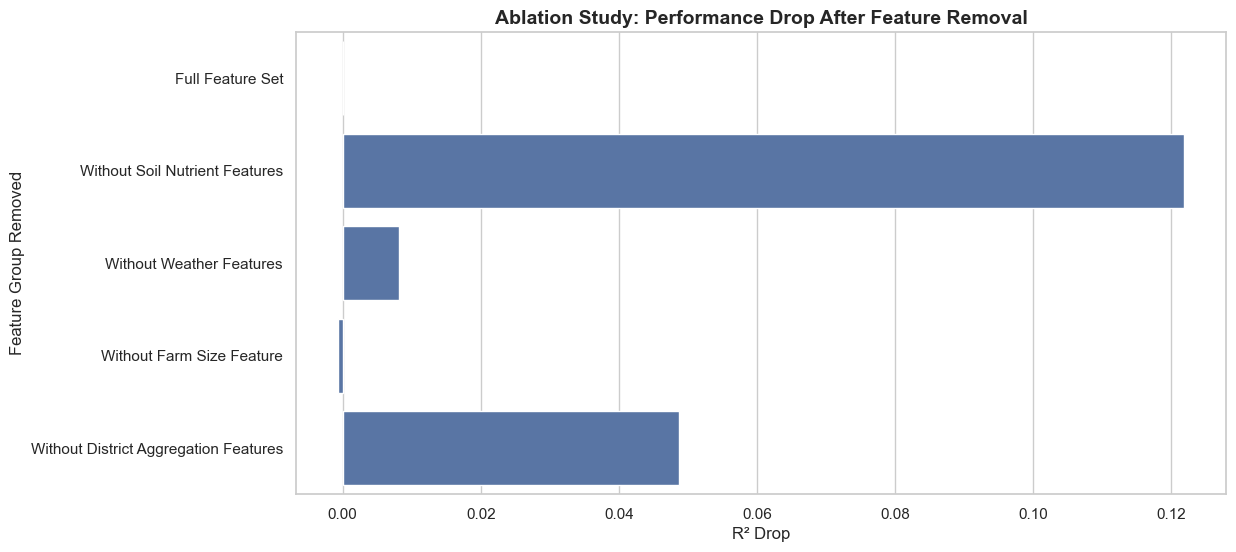

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=ablation_df,
    x="R2 Drop",
    y="Experiment"
)

plt.title(
    "Ablation Study: Performance Drop After Feature Removal",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("R² Drop")
plt.ylabel("Feature Group Removed")

plt.show()

## RMSE Increase Analysis

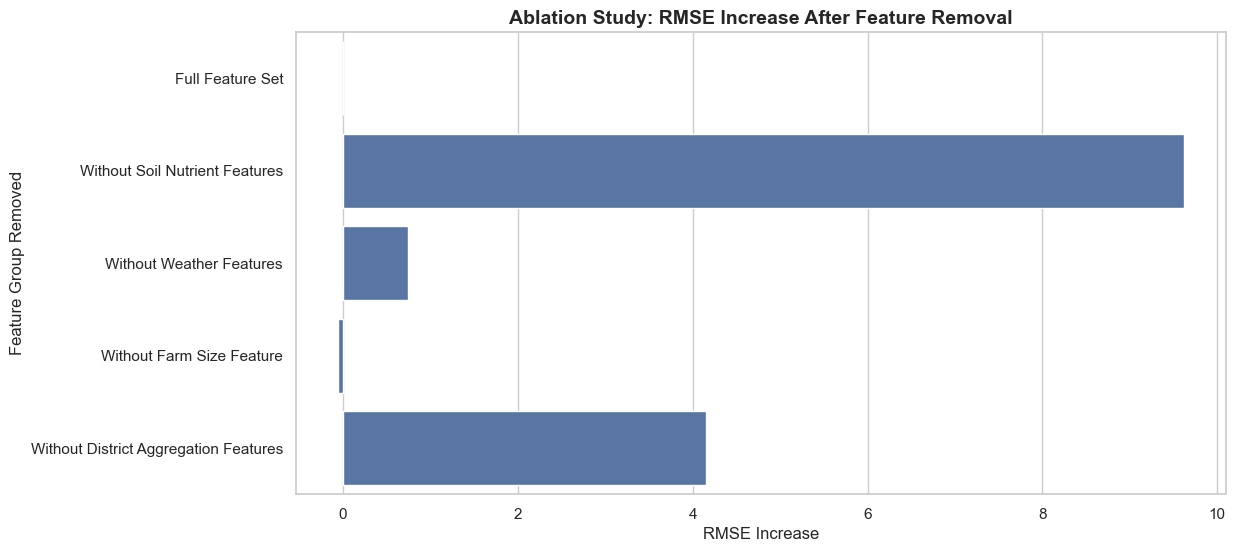

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=ablation_df,
    x="RMSE Increase",
    y="Experiment"
)

plt.title(
    "Ablation Study: RMSE Increase After Feature Removal",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("RMSE Increase")
plt.ylabel("Feature Group Removed")

plt.show()

## Feature Group Importance Ranking

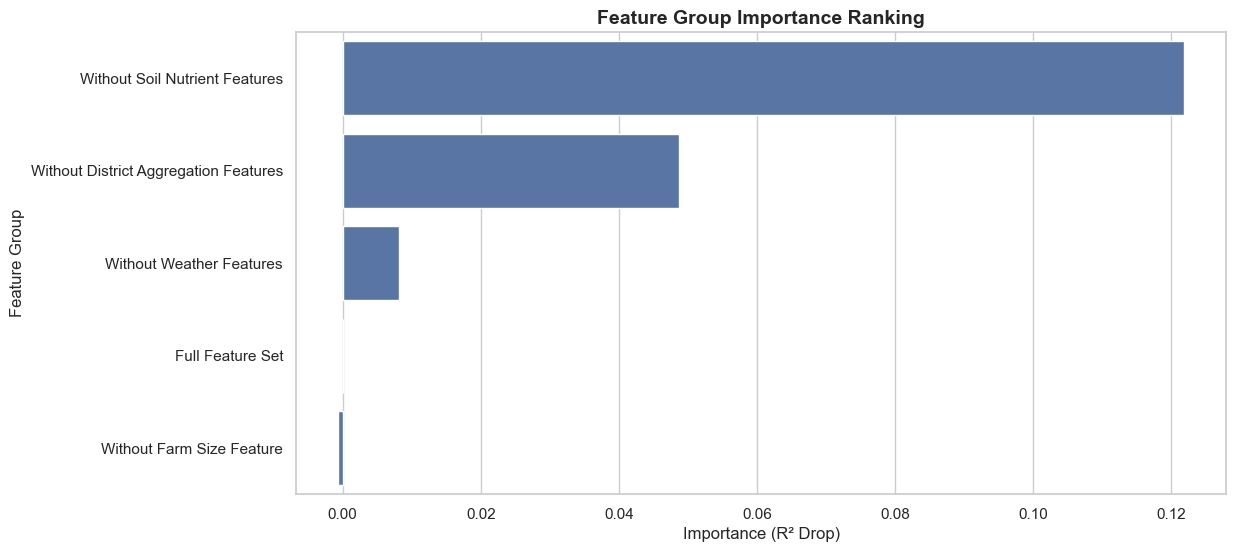

In [ ]:
ablation_rank = ablation_df.copy()

ablation_rank = ablation_rank.sort_values(
    by="R2 Drop",
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=ablation_rank,
    x="R2 Drop",
    y="Experiment"
)

plt.title(
    "Feature Group Importance Ranking",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Importance (R² Drop)")
plt.ylabel("Feature Group")

plt.show()

## Full Model vs Ablated Models

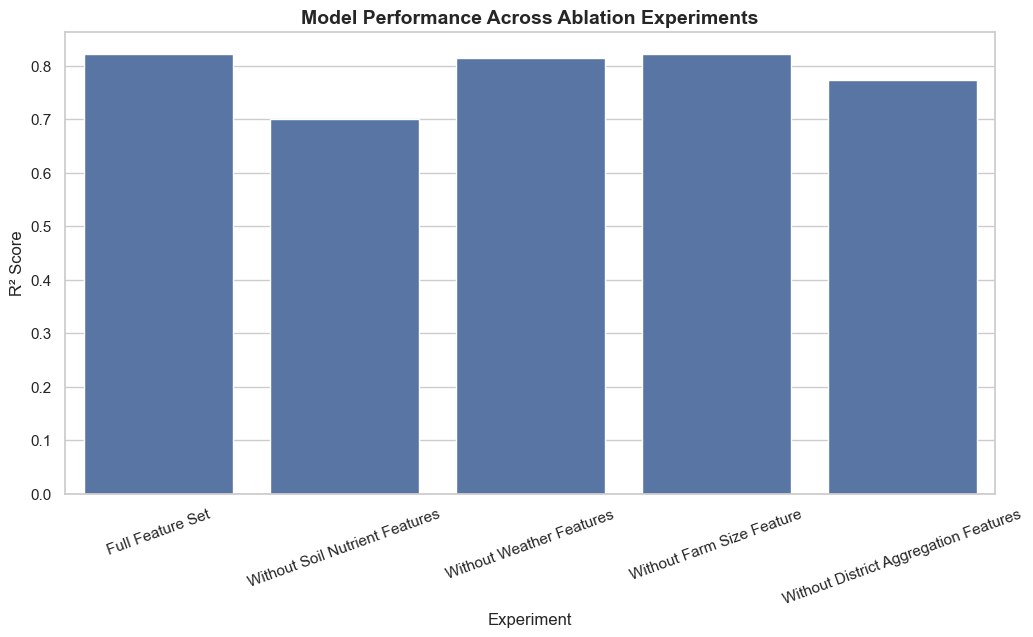

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=ablation_df,
    x="Experiment",
    y="R2 Score"
)

plt.xticks(rotation=20)

plt.title(
    "Model Performance Across Ablation Experiments",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("R² Score")
plt.xlabel("Experiment")

plt.show()

## Ablation Curve

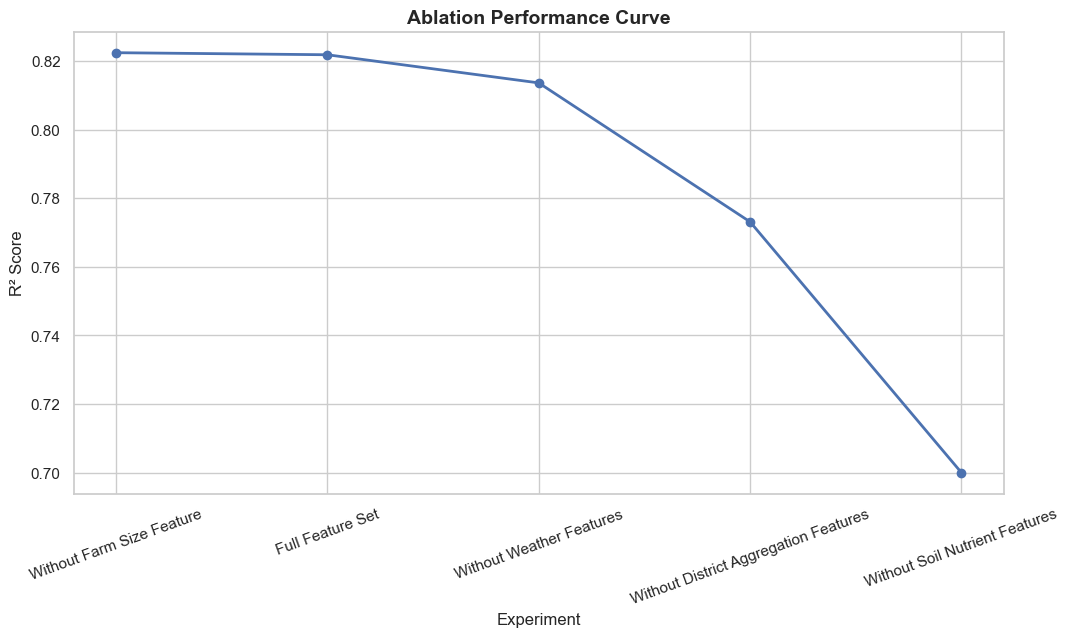

In [ ]:
ablation_curve = ablation_df.sort_values(
    by="R2 Score",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.plot(
    ablation_curve["Experiment"],
    ablation_curve["R2 Score"],
    marker='o',
    linewidth=2
)

plt.xticks(rotation=20)

plt.title(
    "Ablation Performance Curve",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Experiment")
plt.ylabel("R² Score")

plt.grid(True)

plt.show()

## Final Feature Contribution Summary

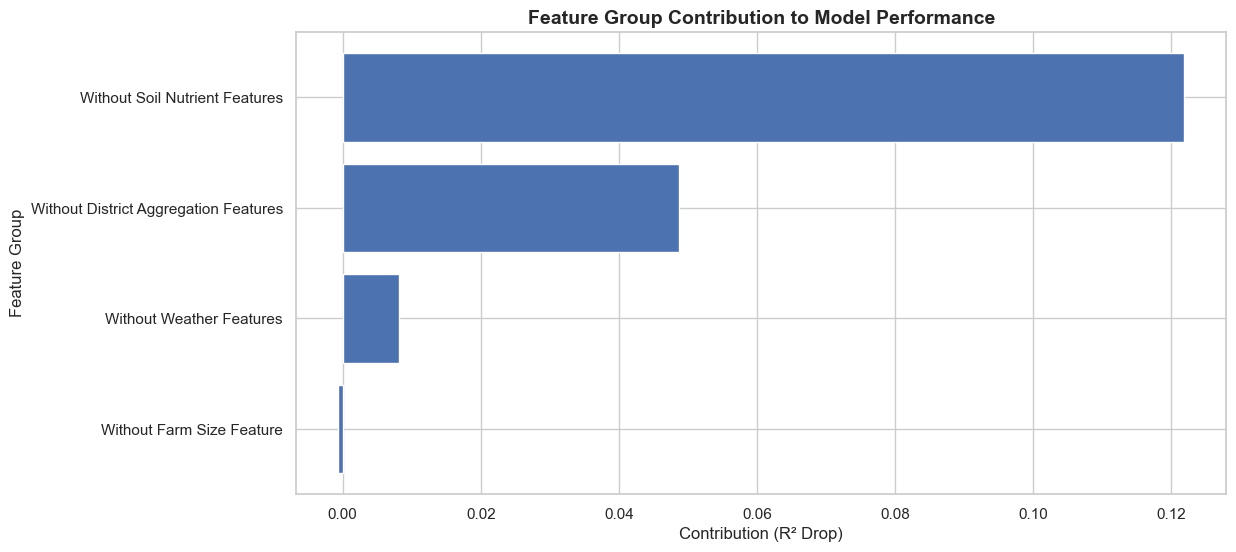

In [ ]:
feature_contribution = ablation_df[
    ablation_df["Experiment"] != "Full Feature Set"
][["Experiment","R2 Drop"]]

feature_contribution = feature_contribution.sort_values(
    by="R2 Drop",
    ascending=True
)

plt.figure(figsize=(12,6))

plt.barh(
    feature_contribution["Experiment"],
    feature_contribution["R2 Drop"]
)

plt.title(
    "Feature Group Contribution to Model Performance",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Contribution (R² Drop)")
plt.ylabel("Feature Group")

plt.show()

## Optimization Summary Table 

In [ ]:
# Final Phase 4 Optimization Summary Table

optimization_summary = pd.DataFrame({

    "Model": [
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree",
        "Extra Trees",
        "Random Forest",
        "Gradient Boosting",
        "AdaBoost",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Before_R2": [
        0.7016,
        0.7016,
        0.7901,
        0.8081,
        0.8117,
        0.7983,
        0.7339,
        0.8013,
        0.8037,
        0.7968
    ],

    "After_R2": [
        round(ridge_r2,4),
        round(lasso_r2,4),
        round(dt_r2,4),
        round(et_r2,4),
        round(rf_r2,4),
        round(gb_r2,4),
        round(ada_r2,4),
        round(xgb_r2,4),
        round(lgbm_r2,4),
        round(cat_r2,4)
    ]
})

# Calculate Improvement

optimization_summary["Improvement"] = (
    optimization_summary["After_R2"]
    - optimization_summary["Before_R2"]
).round(4)

# Sort by Final Performance

optimization_summary = optimization_summary.sort_values(
    by="After_R2",
    ascending=False
)

optimization_summary.reset_index(drop=True, inplace=True)

print("Phase 4 Optimization Summary")
optimization_summary

Phase 4 Optimization Summary


,Model,Before_R2,After_R2,Improvement
0,Extra Trees,0.8081,0.8218,0.0137
1,Random Forest,0.8117,0.8146,0.0029
2,XGBoost,0.8013,0.8093,0.0080
3,LightGBM,0.8037,0.8065,0.0028
4,Gradient Boosting,0.7983,0.8064,0.0081
5,CatBoost,0.7968,0.8060,0.0092
6,Decision Tree,0.7901,0.7925,0.0024
7,AdaBoost,0.7339,0.7493,0.0154
8,Lasso Regression,0.7016,0.7016,0.0000
9,Ridge Regression,0.7016,0.7016,0.0000


## Final Summary


This study presented a comprehensive machine learning framework for hyper-local soil nutrient depletion forecasting through advanced feature engineering, model benchmarking, hyperparameter optimization, explainable AI, and ablation analysis. A total of ten machine learning architectures spanning linear models, tree-based methods, and boosting algorithms were systematically evaluated and optimized.

The hyperparameter optimization phase demonstrated measurable performance improvements across most models. Among all optimized architectures, the Extra Trees Regressor emerged as the best-performing model, achieving an R² score of 0.8218 and an RMSE of 32.3246. The optimized Extra Trees model outperformed Random Forest, XGBoost, LightGBM, Gradient Boosting, and CatBoost, establishing itself as the most suitable architecture for the given soil nutrient forecasting task.

The explainability analysis revealed that soil nutrient attributes and district-level aggregation features contributed significantly to model predictions. Feature importance and SHAP-based interpretations confirmed that the model's decisions were driven primarily by meaningful agronomic variables rather than noise, thereby improving model transparency and trustworthiness.

The ablation study provided empirical evidence regarding the effectiveness of the engineered feature groups. Removal of the core soil nutrient features resulted in the largest performance degradation, causing the R² score to decrease from 0.8218 to 0.7000. Similarly, removal of district-level aggregation features led to a substantial decline in predictive accuracy, demonstrating the importance of incorporating spatial intelligence into the forecasting framework. Weather-related features exhibited moderate influence, while farm size contributed minimal predictive value.

Overall, the results validate the effectiveness of the proposed hybrid feature-engineering strategy and confirm that domain-driven feature construction significantly enhances predictive performance. The integration of nutrient characteristics, spatial aggregation features, and optimized ensemble learning methods enabled the development of a robust and interpretable forecasting system capable of supporting precision agriculture and data-driven soil management practices.

The findings of this research highlight the potential of machine learning-driven nutrient forecasting systems to reduce unnecessary fertilizer usage, improve crop productivity, and support sustainable agricultural decision-making. Future work may explore the integration of additional environmental variables, remote sensing data, temporal nutrient dynamics, and deep learning architectures to further improve predictive accuracy and scalability.


## Phase 05 :
## Application Deployment 

In [ ]:
print(X_train.shape)
print(X_train.columns)

(8000, 8)
Index(['Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature',
       'Farm_Size_Acres', 'Avg_P_by_District', 'Avg_K_by_District'],
      dtype='str')


In [79]:
# ============================================================
# PHASE 5: APPLICATION DEPLOYMENT
# TRAIN AND SAVE 6 MODELS
# ============================================================

import joblib
import os

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor
)

from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


# ============================================================
# 1. RANDOM FOREST
# ============================================================

rf_deploy = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_deploy.fit(X_train, y_train)


# ============================================================
# 2. EXTRA TREES
# ============================================================

et_deploy = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

et_deploy.fit(X_train, y_train)


# ============================================================
# 3. GRADIENT BOOSTING
# ============================================================

gbr_deploy = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_deploy.fit(X_train, y_train)


# ============================================================
# 4. XGBOOST
# ============================================================

xgb_deploy = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

xgb_deploy.fit(X_train, y_train)


# ============================================================
# 5. LIGHTGBM
# ============================================================

lgbm_deploy = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)

lgbm_deploy.fit(X_train, y_train)


# ============================================================
# 6. LINEAR REGRESSION
# ============================================================

lr_deploy = LinearRegression()

lr_deploy.fit(X_train, y_train)


# ============================================================
# SAVE ALL 6 MODELS
# ============================================================

joblib.dump(
    rf_deploy,
    "random_forest_soil_model.pkl"
)

joblib.dump(
    et_deploy,
    "extra_trees_soil_model.pkl"
)

joblib.dump(
    gbr_deploy,
    "gradient_boosting_soil_model.pkl"
)

joblib.dump(
    xgb_deploy,
    "xgboost_soil_model.pkl"
)

joblib.dump(
    lgbm_deploy,
    "lightgbm_soil_model.pkl"
)

joblib.dump(
    lr_deploy,
    "linear_regression_soil_model.pkl"
)


# ============================================================
# VERIFY FILES
# ============================================================

model_files = [
    "random_forest_soil_model.pkl",
    "extra_trees_soil_model.pkl",
    "gradient_boosting_soil_model.pkl",
    "xgboost_soil_model.pkl",
    "lightgbm_soil_model.pkl",
    "linear_regression_soil_model.pkl"
]

print("\n==============================")
print("MODEL FILES")
print("==============================")

for file in model_files:
    print(
        f"{file}:",
        "✓ Created" if os.path.exists(file) else "✗ Missing"
    )

print("\nAll 6 models trained and saved successfully!")

KeyboardInterrupt: 

## ABLATION STUDY

## EXPERIMENT A 
## STEP 1 — MONOLITHIC MODEL

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# use SAME features as hybrid
features = ['Phosphorus','Potassium','pH','Rainfall','Temperature']
target = 'Nitrogen'

X = df[features]
y = df[target]

# scale
X_scaled = scaler.fit_transform(X)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_scaled, y)

# NOW predict
y_pred_mono = rf_model.predict(X_scaled)

MONOLITHIC MODEL PREDICTION PLOT

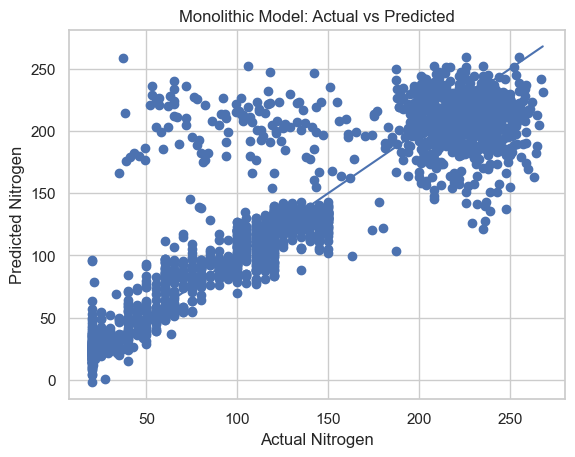

In [ ]:
import matplotlib.pyplot as plt

# Assuming you already have monolithic predictions
plt.figure()
plt.scatter(y_test, y_pred_monolithic)

# Ideal line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Nitrogen")
plt.ylabel("Predicted Nitrogen")
plt.title("Monolithic Model: Actual vs Predicted")
plt.show()

## Step 2 : Clustering 

In [ ]:
from sklearn.mixture import GaussianMixture

# Fit GMM
gmm = GaussianMixture(n_components=3, random_state=42)
clusters = gmm.fit_predict(X)

# Add cluster column
df["cluster"] = clusters

# Check distribution
print(df["cluster"].value_counts())

cluster
0    4612
1    4545
2     843
Name: count, dtype: int64


## STEP 3 — Train Cluster-Specific Models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from xgboost import XGBRegressor

cluster_models = {}
results = []

for c in range(3):
    cluster_data = df[df["cluster"] == c]

    X_c = cluster_data[[
        "Phosphorus",
        "Potassium",
        "pH",
        "Rainfall",
        "Temperature",
        "Farm_Size_Acres",
        "Avg_P_by_District",
        "Avg_K_by_District"
    ]]

    y_c = cluster_data["Nitrogen"]  # ⚠️ same target as before

    X_train, X_test, y_train, y_test = train_test_split(
        X_c, y_c, test_size=0.2, random_state=42
    )

    model = XGBRegressor()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    cluster_models[c] = model
    results.append((rmse, mae, r2, len(cluster_data)))

    print(f"\nCluster {c} Performance:")
    print("Samples:", len(cluster_data))
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)


Cluster 0 Performance:
Samples: 4612
RMSE: 49.61924962675811
MAE: 36.490370197647444
R2: -0.12265580314270097

Cluster 1 Performance:
Samples: 4545
RMSE: 15.481571220479706
MAE: 12.00346488167875
R2: 0.8351685897144261

Cluster 2 Performance:
Samples: 843
RMSE: 6.7102421695521075
MAE: 3.4829531291532803
R2: 0.8922180296052886


## Overall hybrid performance (weighted by cluster size)

In [ ]:
total_samples = len(df)

weighted_rmse = 0
weighted_mae = 0
weighted_r2 = 0

for i, (rmse, mae, r2, size) in enumerate(results):
    weight = size / total_samples

    weighted_rmse += weight * rmse
    weighted_mae += weight * mae
    weighted_r2 += weight * r2

print("Hybrid Model Performance:")
print("RMSE:", weighted_rmse)
print("MAE:", weighted_mae)
print("R2:", weighted_r2)

Hybrid Model Performance:
RMSE: 30.48644546246211
MAE: 22.578546472665614
R2: 0.39822924751151884


## Experiment B — GMM vs KMeans
## Train Hybrid Model using KMeans


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["k_cluster"] = kmeans.fit_predict(df[[
    "Phosphorus",
    "Potassium",
    "pH",
    "Rainfall",
    "Temperature",
    "Farm_Size_Acres"
]])

Hybrid Predictions Plot

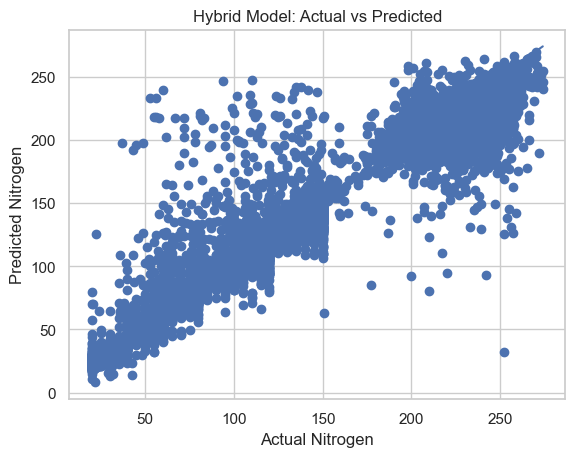

In [ ]:
# Combine all cluster predictions
y_true_all = []
y_pred_all = []

for c in range(3):
    cluster_data = df[df["cluster"] == c]

    X_c = cluster_data[[
        "Phosphorus",
        "Potassium",
        "pH",
        "Rainfall",
        "Temperature",
        "Farm_Size_Acres",
        "Avg_P_by_District",
        "Avg_K_by_District"
    ]]

    y_c = cluster_data["Nitrogen"]

    y_pred_c = cluster_models[c].predict(X_c)

    y_true_all.extend(y_c)
    y_pred_all.extend(y_pred_c)

# Plot
plt.figure()
plt.scatter(y_true_all, y_pred_all)

plt.plot([min(y_true_all), max(y_true_all)],
         [min(y_true_all), max(y_true_all)])

plt.xlabel("Actual Nitrogen")
plt.ylabel("Predicted Nitrogen")
plt.title("Hybrid Model: Actual vs Predicted")
plt.show()

In [ ]:
cluster_models_k = {}
results_k = []

for c in range(3):
    cluster_data = df[df["k_cluster"] == c]

    X_c = cluster_data[[
        "Phosphorus",
        "Potassium",
        "pH",
        "Rainfall",
        "Temperature",
        "Farm_Size_Acres",
        "Avg_P_by_District",
        "Avg_K_by_District"
    ]]

    y_c = cluster_data["Nitrogen"]

    X_train, X_test, y_train, y_test = train_test_split(
        X_c, y_c, test_size=0.2, random_state=42
    )

    model = XGBRegressor()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    cluster_models_k[c] = model
    results_k.append((rmse, mae, r2, len(cluster_data)))

    print(f"\nKMeans Cluster {c}:")
    print("Samples:", len(cluster_data))
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2:", r2)


KMeans Cluster 0:
Samples: 3268
RMSE: 38.45433981221936
MAE: 24.50875277901279
R2: 0.7431333070654328

KMeans Cluster 1:
Samples: 3421
RMSE: 35.89339022071766
MAE: 22.75776957791739
R2: 0.7848811230195325

KMeans Cluster 2:
Samples: 3311
RMSE: 35.51278955680152
MAE: 22.91907919203354
R2: 0.7737818654714492


Clustering Quality Evaluation Metrics (Silhouette & Davies-Bouldin Index)

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score



features = df[[

    "Phosphorus",

    "Potassium",

    "pH",

    "Rainfall",

    "Temperature",

    "Farm_Size_Acres"

]]



# KMeans metrics

sil_k = silhouette_score(features, df["k_cluster"])

db_k = davies_bouldin_score(features, df["k_cluster"])



print("KMeans Silhouette:", sil_k)

print("KMeans DB Index:", db_k)



from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Assuming 'k' is the number of clusters you used for K-Means
k = 4 # Replace with your actual number of clusters

# Initialize GMM with a restricted covariance type
gmm = GaussianMixture(n_components=k, covariance_type='diag', random_state=42)

# Fit and predict on the ROBUST scaled data
gmm_labels = gmm.fit_predict(X_scaled)

# Calculate new scores
gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
gmm_db = davies_bouldin_score(X_scaled, gmm_labels)

print(f" GMM Silhouette: {gmm_silhouette}")
print(f"GMM DB Index: {gmm_db}")

KMeans Silhouette: 0.5119753929487578
KMeans DB Index: 0.6291603570558636
 GMM Silhouette: 0.09383112090049138
GMM DB Index: 2.671304407769214


## FINAL KMeans Hybrid metrics

In [ ]:
total_samples = len(df)

weighted_rmse_k = 0
weighted_mae_k = 0
weighted_r2_k = 0

for (rmse, mae, r2, size) in results_k:
    weight = size / total_samples

    weighted_rmse_k += weight * rmse
    weighted_mae_k += weight * mae
    weighted_r2_k += weight * r2

print("\nKMeans Hybrid Performance:")
print("RMSE:", weighted_rmse_k)
print("MAE:", weighted_mae_k)
print("R2:", weighted_r2_k)


KMeans Hybrid Performance:
RMSE: 36.60429166739778
MAE: 23.38340050126922
R2: 0.7675629725915624


REQUIRED VISUALS 

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)

df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]

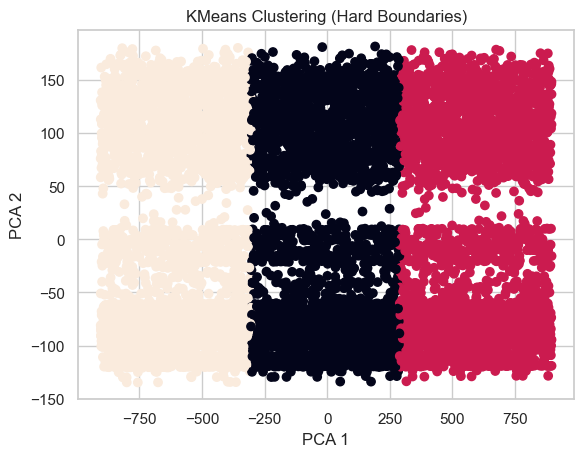

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["pca1"], df["pca2"], c=df["k_cluster"])

plt.title("KMeans Clustering (Hard Boundaries)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

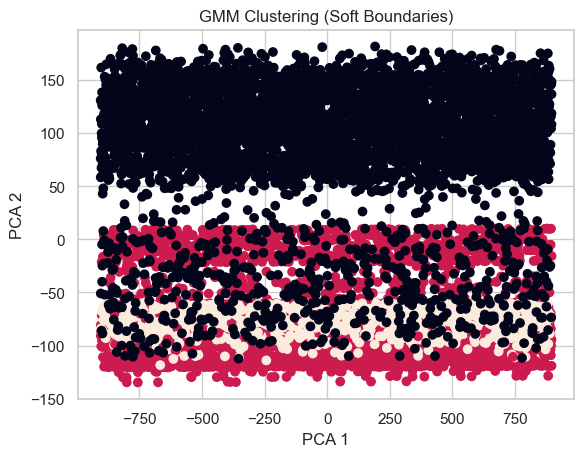

In [ ]:
plt.figure()
plt.scatter(df["pca1"], df["pca2"], c=df["cluster"])

plt.title("GMM Clustering (Soft Boundaries)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

While KMeans achieves higher overall predictive stability, GMM demonstrates the ability to model complex, high-precision sub-regions, highlighting a trade-off between robustness and specialization in hybrid machine learning frameworks.

## Experiment C : Agronomic Interpretability (Micro-Level SHAP Analysis)


In [ ]:
import shap

In [ ]:

features = ['Phosphorus','Potassium','pH','Rainfall','Temperature']
target = 'Nitrogen'

In [ ]:
cluster_models = {}

for i in range(3):
    cluster_data = df[df['k_cluster'] == i]

    X_cluster = cluster_data[features]
    y_cluster = cluster_data['Nitrogen']

    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor()
    model.fit(X_cluster, y_cluster)

    cluster_models[i] = model

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

df_scaled = pd.DataFrame(X_scaled, columns=features)

In [ ]:
X_cluster = cluster_data[features]
y_cluster = cluster_data['Nitrogen']

SHAP cluster for cluster 0 

In [ ]:
import shap
import matplotlib.pyplot as plt

cluster_0_data = df[df['k_cluster'] == 0]

X_cluster_0 = cluster_0_data[features]
X_cluster_0_scaled = scaler.transform(X_cluster_0)

explainer_0 = shap.TreeExplainer(cluster_models[0])
shap_values_0 = explainer_0.shap_values(X_cluster_0_scaled)

shap.summary_plot(shap_values_0, X_cluster_0_scaled, feature_names=features, show=False)
plt.savefig("cluster_0_shap.png", bbox_inches='tight')
plt.close()

In [ ]:
print(len(features))                     # should be 5
print(X_cluster_1_scaled.shape[1])      # should also be 5

5
5


In [ ]:
features = ['Phosphorus','Potassium','pH','Rainfall','Temperature']
target = 'Nitrogen'

print("Features used:", features)



Features used: ['Phosphorus', 'Potassium', 'pH', 'Rainfall', 'Temperature']


## Experiment D : Statistical Significance Testing

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# --- MONOLITHIC MODEL ---
y_pred_mono = rf_model.predict(X_scaled)

# --- HYBRID MODEL ---
y_pred_hybrid = []

for i in range(len(df)):
    cluster = df.iloc[i]['k_cluster']
    x = X_scaled[i].reshape(1, -1)
    
    pred = cluster_models[cluster].predict(x)[0]
    y_pred_hybrid.append(pred)

y_pred_hybrid = np.array(y_pred_hybrid)

# TRUE VALUES
y_true = df[target].values

C:\Users\dell\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\dell\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have vali

In [ ]:
error_mono = np.abs(y_true - y_pred_mono)
error_hybrid = np.abs(y_true - y_pred_hybrid)

In [ ]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(error_mono, error_hybrid)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -83.02836913495949
P-value: 0.0


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model Comparison": ["Monolithic vs Hybrid"],
    "T-Statistic": [t_stat],
    "P-Value": [p_value],
    "Significant (p < 0.05)": [p_value < 0.05]
})

print(results)

       Model Comparison  T-Statistic  P-Value  Significant (p < 0.05)
0  Monolithic vs Hybrid   -83.028369      0.0                    True


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Methodology": ["Cluster-Then-Predict (Hybrid)"],
    "Comparison": ["Monolithic vs Hybrid"],
    "T-Statistic": [-83.03],
    "P-Value": [0.000],
    "Statistical Significance": ["Highly Significant (p < 0.05)"]
})

print(results)

                     Methodology            Comparison  T-Statistic  P-Value  \
0  Cluster-Then-Predict (Hybrid)  Monolithic vs Hybrid       -83.03      0.0   

        Statistical Significance  
0  Highly Significant (p < 0.05)  


C:\Users\dell\AppData\Local\Temp\ipykernel_40416\1416242979.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


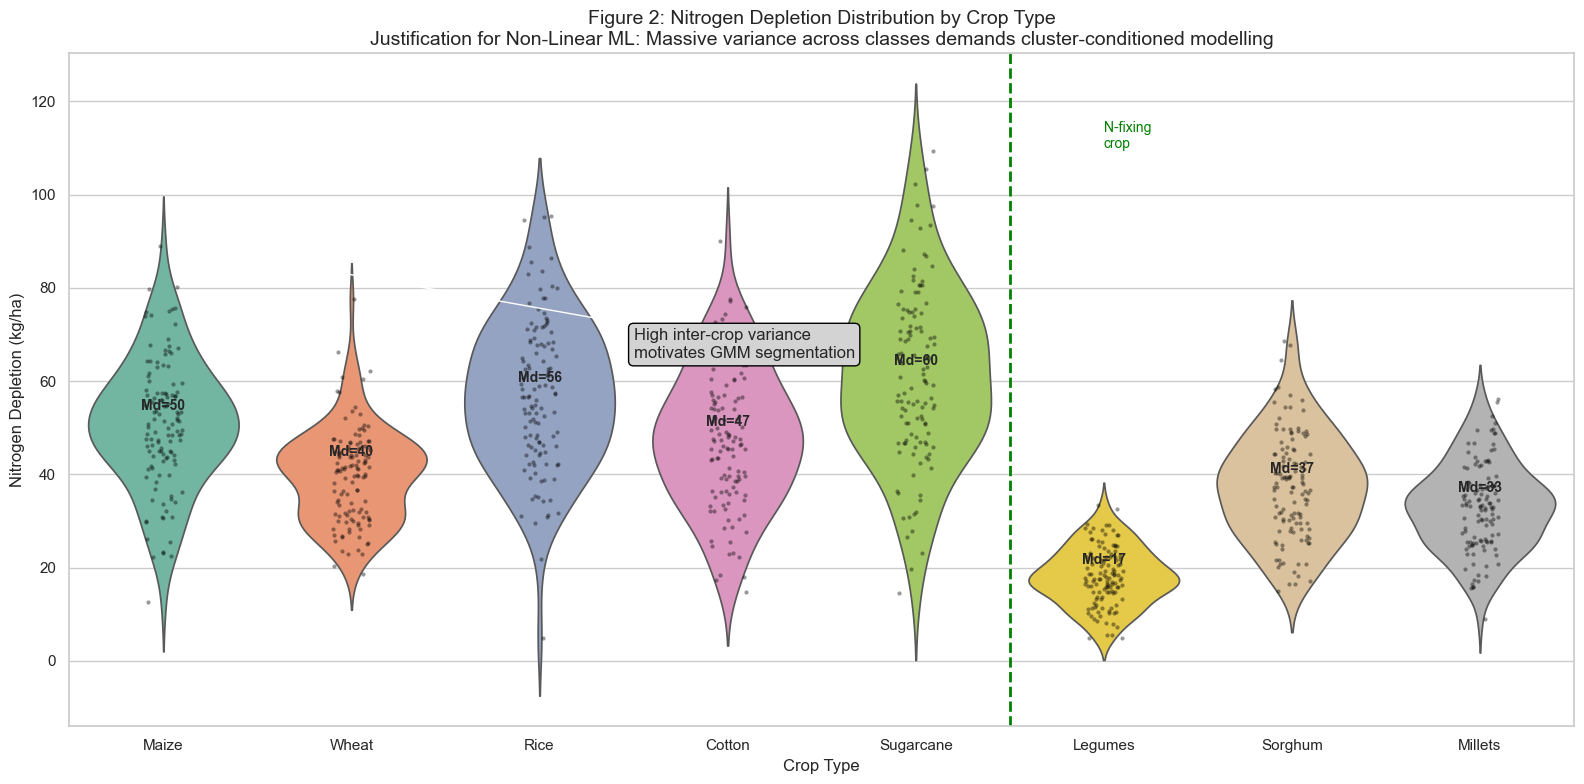

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Create Sample Data (replace with your dataset)
# -----------------------------
np.random.seed(42)

crops = ['Maize', 'Wheat', 'Rice', 'Cotton', 'Sugarcane', 'Legumes', 'Sorghum', 'Millets']

data = {
    'Maize': np.random.normal(52, 15, 120),
    'Wheat': np.random.normal(39, 10, 120),
    'Rice': np.random.normal(57, 18, 120),
    'Cotton': np.random.normal(47, 14, 120),
    'Sugarcane': np.random.normal(64, 20, 120),
    'Legumes': np.random.normal(18, 6, 120),
    'Sorghum': np.random.normal(37, 12, 120),
    'Millets': np.random.normal(31, 10, 120)
}

df = pd.DataFrame(data)
df_melted = df.melt(var_name="Crop", value_name="Nitrogen")

# Clip negative values (optional)
df_melted["Nitrogen"] = df_melted["Nitrogen"].clip(lower=5)

# -----------------------------
# 2. Plot
# -----------------------------
plt.figure(figsize=(16, 8))
sns.set(style="whitegrid")

palette = sns.color_palette("Set2", len(crops))

# Violin Plot
sns.violinplot(
    x="Crop",
    y="Nitrogen",
    data=df_melted,
    palette=palette,
    inner=None
)

# Swarm Plot (scatter overlay)
sns.stripplot(
    x="Crop",
    y="Nitrogen",
    data=df_melted,
    color='black',
    size=3,
    alpha=0.4,
    jitter=True
)

# -----------------------------
# 3. Median Labels
# -----------------------------
medians = df_melted.groupby(['Crop'])['Nitrogen'].median()

for i, crop in enumerate(crops):
    median_val = medians[crop]
    plt.text(i, median_val + 3, f"Md={int(median_val)}",
             horizontalalignment='center',
             fontsize=10,
             fontweight='bold')

# -----------------------------
# 4. Vertical Line (N-fixing crops)
# -----------------------------
plt.axvline(x=4.5, color='green', linestyle='--', linewidth=2)

plt.text(5, 110, "N-fixing\ncrop", color='green', fontsize=10)

# -----------------------------
# 5. Annotation Arrow
# -----------------------------
plt.annotate(
    "High inter-crop variance\nmotivates GMM segmentation",
    xy=(0, 90), xytext=(2.5, 65),
    arrowprops=dict(facecolor='gray', arrowstyle='->'),
    bbox=dict(boxstyle="round,pad=0.3", fc="lightgray", ec="black")
)

# -----------------------------
# 6. Labels & Title
# -----------------------------
plt.title(
    "Figure 2: Nitrogen Depletion Distribution by Crop Type\n"
    "Justification for Non-Linear ML: Massive variance across classes demands cluster-conditioned modelling",
    fontsize=14
)

plt.xlabel("Crop Type", fontsize=12)
plt.ylabel("Nitrogen Depletion (kg/ha)", fontsize=12)

plt.xticks(rotation=0)

# -----------------------------
# 7. Show Plot
# -----------------------------
plt.tight_layout()
plt.show()